# Cloud Storage Load Imbalance Detection — sample2

> 원본 sample.ipynb 모든 변수명/경로 완전 유지  
> BLOCK 0 ~ 6-F + 신규 블록(시각화/EWMA SPC/RF 분류기/Precision-Recall 평가)  
> 위에서 아래로 한 번에 실행 가능

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit, softmax
from scipy.stats import rankdata

import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    classification_report, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

print('✅ imports OK')

✅ imports OK


# BLOCK 0) 프로젝트 설정 + 전역 규칙

In [2]:
# BLOCK 0) CONFIG
from pathlib import Path

INPUT_DIR  = Path("/Users/jojunho/Documents/4-1/졸업논문/데이터")
OUTPUT_ROOT= Path("/Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild")
RESULT_SUBFOLDER = "notebook_a_revised_labels_v2"
OUTPUT_DIR = OUTPUT_ROOT / RESULT_SUBFOLDER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR  = OUTPUT_DIR / "_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_DIR :", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

USE_VOL             = False
FORCE_REBUILD_BASE  = False
TIME_BIN_OVERRIDE   = None
BASE_METRICS        = ["throughput", "latency", "iops", "cpu"]

BASELINE_FRAC       = 0.2
MIN_N               = 60
K_SIGMA             = 3.0
PERSIST_WINDOW      = 3
PERSIST_MIN_HITS    = 2

TOPK                = 3
RANK_OUTPUT_TOPK    = None

PRIMARY_HOT_IMB     = "imb_norm_top1_share"
HOT_LEVELS          = ["node", "port"]
HOT_RWS             = ["read", "write"]
HOT_SRC_METRICS     = ["throughput", "iops", "latency"]
HOT_ALPHA           = 0.35
HOT_WEAK_ALPHA      = 0.20
HOT_MIN_DURATION_BINS      = 2
HOT_LOAD_BASELINE_Q        = 0.50
HOT_REQUIRE_LOAD_GATE      = True
HOT_TIER_STRONG_MIN_OVERUCL= 1

IMB_METRICS_REVISED = [
    "imb_top1_share","imb_norm_top1_share",
    "imb_hhi","imb_gini","imb_theil"
]
print("PRIMARY_HOT_IMB =", PRIMARY_HOT_IMB)
print("RESULT_SUBFOLDER=", RESULT_SUBFOLDER)

INPUT_DIR : /Users/jojunho/Documents/4-1/졸업논문/데이터
OUTPUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2
PRIMARY_HOT_IMB = imb_norm_top1_share
RESULT_SUBFOLDER= notebook_a_revised_labels_v2


In [3]:
# BLOCK 0-A) ADDITIONAL CONFIG
PRIMARY_HOT_IMB  = "imb_norm_top1_share"
HOT_LEVELS       = ["node", "port"]
HOT_RWS          = ["read", "write"]
HOT_SRC_METRICS  = ["throughput", "iops", "latency"]
HOT_ALPHA        = 0.35
HOT_MIN_DURATION_BINS = 2
HOT_LOAD_BASELINE_Q   = 0.50
HOT_REQUIRE_LOAD_GATE = True
HOT_REQUIRE_TRIGGER_OVER_UCL  = False
HOT_TIER_STRONG_MIN_OVERUCL   = 1

IMB_METRICS_REVISED = [
    "imb_top1_share","imb_norm_top1_share",
    "imb_hhi","imb_gini","imb_theil"
]

MAHA_LEVEL_FEATURES = {
    "system": ["throughput","iops","latency"],
    "node":   ["throughput","iops","latency"],
    "port":   ["throughput","iops"]
}
MAHA_RWS            = ["read","write"]
MAHA_BASELINE_FRAC  = 0.2
MAHA_MIN_N          = 60
MAHA_SHRINK_LAMBDA  = 0.10
MAHA_EPS            = 1e-6

print("PRIMARY_HOT_IMB =",     PRIMARY_HOT_IMB)
print("HOT_SRC_METRICS =",     HOT_SRC_METRICS)
print("MAHA_LEVEL_FEATURES =", MAHA_LEVEL_FEATURES)

PRIMARY_HOT_IMB = imb_norm_top1_share
HOT_SRC_METRICS = ['throughput', 'iops', 'latency']
MAHA_LEVEL_FEATURES = {'system': ['throughput', 'iops', 'latency'], 'node': ['throughput', 'iops', 'latency'], 'port': ['throughput', 'iops']}


# BLOCK 1 (데이터 로드 → long 포맷 통일 → base_long 생성)

In [4]:
# BLOCK 1) LOAD -> NORMALIZE -> base_long
def load_base_long_standalone(input_dir, cache_dir,
                               include_vol=False, force_rebuild=False):
    cache_file    = cache_dir / "base_long_cache.pkl"
    expected_cols = ["timestamp","stg_ip","level","entity_id","rw","metric","value"]
    target_metrics= [m.lower().strip() for m in BASE_METRICS]

    def is_valid(df):
        if df is None or not isinstance(df, pd.DataFrame) or df.empty: return False
        if df.columns.duplicated().any(): return False
        if list(df.columns) != expected_cols: return False
        return True

    if (not force_rebuild) and cache_file.exists():
        print("Loading base_long from cache...")
        cached = pd.read_pickle(cache_file)
        if is_valid(cached):
            print("✅ valid base_long cache found"); return cached
        print("⚠️ invalid cache, rebuilding...")

    def fast_normalize(df, level_name):
        empty = pd.DataFrame(columns=expected_cols)
        if df is None or df.empty: return empty
        required = ["timestamp","stg_ip","level","entity_id","metric","value"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"⚠️ {level_name}: missing={missing}"); return empty
        d = df.copy()
        d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
        d["value"]     = pd.to_numeric(d["value"],     errors="coerce")
        d = d.dropna(subset=["timestamp","value"])
        if d.empty: return empty
        rm = d["metric"].astype(str).str.lower().str.strip()
        d["rw"] = "mix"
        d.loc[rm.str.startswith("read_",  na=False), "rw"] = "read"
        d.loc[rm.str.startswith("write_", na=False), "rw"] = "write"
        ms = pd.Series(index=d.index, dtype="object")
        ms.loc[rm.str.contains("throughput|tp|bw",na=False)] = "throughput"
        ms.loc[rm.str.contains("iops",            na=False)] = "iops"
        ms.loc[rm.str.contains("lat|resp|rs|rt",  na=False)] = "latency"
        ms.loc[rm.str.contains("cpu",             na=False)] = "cpu"
        d["metric"] = ms
        d.loc[d["metric"]=="cpu","rw"] = "cpu"
        d = d[d["metric"].isin(target_metrics)].copy()
        if d.empty: return empty
        out = d[expected_cols].copy()
        for c in ["stg_ip","level","entity_id","rw","metric"]:
            out[c] = out[c].astype(str).str.strip().str.lower()
        return out

    rows = []
    for fp_name, level, id_col in [
        ("data_system.parquet","system", None),
        ("data_node.parquet",  "node",  "node_name"),
        ("data_port.parquet",  "port",  None),
    ]:
        fp = input_dir / fp_name
        if not fp.exists(): continue
        if level == "system":
            df = pd.read_parquet(fp, columns=["timestamp","stg_ip","metric","value"])
            df["level"] = "system"; df["entity_id"] = "group"
        elif level == "node":
            df = pd.read_parquet(fp, columns=["timestamp","stg_ip","node_name","metric","value"])
            df["level"] = "node"; df["entity_id"] = df["node_name"].astype(str)
        else:
            df = pd.read_parquet(fp, columns=["timestamp","stg_ip","node_id","port_id","metric","value"])
            df["level"] = "port"
            df["entity_id"] = df["node_id"].astype(str)+":"+df["port_id"].astype(str)
        rows.append(fast_normalize(df, level))
        print(f"✅ {level} loaded")

    if include_vol:
        for fp in sorted(list(input_dir.glob("data_vol_*.parquet"))):
            try:
                wm = ["read_iops","write_iops","read_throughput","write_throughput"]
                df = pd.read_parquet(fp, columns=["timestamp","stg_ip","vol_id"]+wm)
                melt = df.melt(id_vars=["timestamp","stg_ip","vol_id"],
                               value_vars=wm, var_name="metric", value_name="value")
                melt["level"] = "vol"; melt["entity_id"] = melt["vol_id"].astype(str)
                rows.append(fast_normalize(melt, f"vol:{fp.name}"))
                print(f"✅ vol {fp.name}")
            except Exception as e:
                print(f"⚠️ skip vol {fp.name}: {e}")

    if not rows: raise ValueError("❌ no data loaded")
    base_long = pd.concat(rows, ignore_index=True)
    base_long = base_long[expected_cols].dropna(subset=expected_cols)
    base_long = base_long.sort_values(
        ["timestamp","stg_ip","level","entity_id","rw","metric"]
    ).reset_index(drop=True)
    assert not base_long.columns.duplicated().any()
    base_long.to_pickle(cache_file)
    print(f"✅ base_long cache saved: {cache_file}")
    return base_long


base_long = load_base_long_standalone(
    INPUT_DIR, CACHE_DIR,
    include_vol=USE_VOL, force_rebuild=FORCE_REBUILD_BASE
)
print("base_long:", base_long.shape)
print(base_long.head())

✅ system loaded
✅ node loaded
✅ port loaded
✅ base_long cache saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2/_cache/base_long_cache.pkl
base_long: (21861964, 7)
            timestamp                            stg_ip level  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   

           entity_id     rw      metric     value  
0  she03_svc_78e3drx    cpu         cpu    10.000  
1  she03_svc_78e3drx   read        iops  4820.000  
2  she03_svc_78e3drx   read     latency     0.092  
3  she03_svc_78e3drx   read  throughput    92.000  
4  she03_svc_78e3drx  write        iops  1595.000  


# BLOCK 1.5) TIME_BIN 자동 추정 + Binning

In [5]:
# BLOCK 1.5) TIME_BIN inference + BINNING
def infer_freq_minutes(df_long):
    if df_long is None or df_long.empty: return None
    d = df_long.dropna(subset=["timestamp"]).copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d = d.dropna(subset=["timestamp"])
    if d.empty: return None
    keys = ["stg_ip","level","entity_id","rw","metric"]
    d = d.sort_values(keys+["timestamp"])
    sampled = d.groupby(keys, observed=True, group_keys=False).head(200)
    diffs = sampled.groupby(keys, observed=True)["timestamp"].diff().dropna()
    if diffs.empty: return None
    med_sec = float(np.median(diffs.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0: return None
    return max(1, int(round(med_sec/60.0)))

freq_min = infer_freq_minutes(base_long)
if TIME_BIN_OVERRIDE is not None:
    TIME_BIN = TIME_BIN_OVERRIDE
elif freq_min is None:  TIME_BIN = "15min"
elif freq_min <= 2:     TIME_BIN = "15min"
elif freq_min <= 10:    TIME_BIN = "30min"
else:                   TIME_BIN = "60min"
print("estimated freq_min =", freq_min, "=> TIME_BIN =", TIME_BIN)

AGG_METHOD_BY_METRIC = {
    "throughput":"mean","iops":"mean","cpu":"mean","latency":"median"
}

def aggregate_binned_base_long(df_long, time_bin):
    empty_cols = ["timestamp","stg_ip","level","entity_id","rw","metric","value"]
    if df_long is None or df_long.empty:
        return pd.DataFrame(columns=empty_cols)
    d = df_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["value"]     = pd.to_numeric(d["value"],      errors="coerce")
    d = d.dropna(subset=["timestamp","value"])
    d["timestamp"] = d["timestamp"].dt.floor(time_bin)
    out_parts = []
    for mn, an in AGG_METHOD_BY_METRIC.items():
        sub = d[d["metric"]==mn].copy()
        if sub.empty: continue
        grp = sub.groupby(
            ["timestamp","stg_ip","level","entity_id","rw","metric"],
            observed=True, as_index=False)["value"]
        agg_df = grp.mean() if an=="mean" else grp.median() if an=="median" else grp.max()
        out_parts.append(agg_df)
    if not out_parts: return pd.DataFrame(columns=empty_cols)
    out = pd.concat(out_parts, ignore_index=True)
    return out.sort_values(
        ["timestamp","stg_ip","level","entity_id","rw","metric"]
    ).reset_index(drop=True)

base_long = aggregate_binned_base_long(base_long, TIME_BIN)
dup_cnt = base_long.duplicated(
    subset=["timestamp","stg_ip","level","entity_id","rw","metric"]
).sum()
print("base_long after binning:", base_long.shape, "| dup =", dup_cnt)

stg_list = sorted(base_long["stg_ip"].dropna().astype(str).unique().tolist())
print("stg_list:", len(stg_list), stg_list[:10])
base_long.to_parquet(OUTPUT_DIR / "BASE_LONG_REVISED.parquet", index=False)

estimated freq_min = 5 => TIME_BIN = 30min
base_long after binning: (3740034, 7) | dup = 0
stg_list: 8 ['2ba5dffc731bb54e90ad3c49de181c76', '2d8b5e3a40b67c7a6d86b8d971d9bfa8', '37be52dc8d87d377dd39b421cc29d381', '96353914610fbf899a486bbc516a0fcb', '99eb4c58b38c9f508c4d543fcac1bd0a', 'dc528f7ddf17527bf8b019765e5b2dda', 'e6b9d2b55c75bce18516d6ef2167a683', 'f780b0065c37d3f594032e58cb31ba2d']


# BLOCK 2) imbalance 파생지표를 metric으로 추가 (핵심)

In [7]:
# BLOCK 2) REVISED IMBALANCE METRICS
def gini_from_values(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; s = x.sum()
    if x.size<2 or s<=0: return 0.0
    x = np.sort(np.clip(x,0,None)); n = x.size; i = np.arange(1,n+1)
    return float((2*np.sum(i*x)/(n*s))-(n+1)/n)

def hhi_from_values(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; s = x.sum()
    if x.size<2 or s<=0: return 0.0
    return float(np.sum((x/s)**2))

def theil_from_values(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; s = x.sum()
    if x.size<2 or s<=0: return 0.0
    mu = s/x.size; y = x[x>0]
    if y.size<2 or mu<=0: return 0.0
    return float(np.mean((y/mu)*np.log(y/mu)))

def top1_share_from_values(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; s = x.sum()
    if x.size<2 or s<=0: return 0.0
    return float(np.max(x)/s)

def norm_top1_share_from_values(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; s = x.sum(); n = x.size
    if n<2 or s<=0: return 0.0
    raw = float(np.max(x)/s); floor = 1.0/n; denom = 1.0-floor
    if denom<=1e-12: return 0.0
    return float(max(0.0, (raw-floor)/denom))

MIN_GROUP_ENTITIES = 2

def build_imbalance_long_revised(base_long, levels=("node","port"),
                                  base_metrics=("throughput","iops","latency","cpu")):
    empty_cols = [
        "timestamp","stg_ip","level","entity_id","rw","metric","value",
        "imb_metric","src_metric","n_entities","active_entities","group_total"
    ]
    if base_long is None or base_long.empty:
        return pd.DataFrame(columns=empty_cols)
    d = base_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"],errors="coerce")
    d["metric"]    = d["metric"].astype(str).str.lower().str.strip()
    d["rw"]        = d["rw"].astype(str).str.lower().str.strip()
    d["value"]     = pd.to_numeric(d["value"], errors="coerce")
    d = d.dropna(subset=["timestamp","value"])
    d = d[d["level"].isin(levels) & d["metric"].isin([m.lower() for m in base_metrics])].copy()
    if d.empty: return pd.DataFrame(columns=empty_cols)

    rows = []
    for (stg,lvl,src_metric,rw,ts), g in d.groupby(
            ["stg_ip","level","metric","rw","timestamp"], observed=True):
        n_ent = g["entity_id"].nunique()
        if n_ent < MIN_GROUP_ENTITIES: continue
        x = pd.to_numeric(g["value"],errors="coerce").dropna().values.astype(float)
        x = x[np.isfinite(x)]
        if x.size<2 or x.sum()<=0: continue
        active_ent = int((x>0).sum()); gtot = float(x.sum())
        mv = {
            "imb_top1_share":      top1_share_from_values(x),
            "imb_norm_top1_share": norm_top1_share_from_values(x),
            "imb_hhi":             hhi_from_values(x),
            "imb_gini":            gini_from_values(x),
            "imb_theil":           theil_from_values(x),
        }
        for imb_name, val in mv.items():
            rows.append({
                "timestamp":ts,"stg_ip":stg,"level":lvl,
                "entity_id":"group","rw":rw,
                "metric":f"{imb_name}__{src_metric}","value":float(val),
                "imb_metric":imb_name,"src_metric":src_metric,
                "n_entities":int(n_ent),"active_entities":int(active_ent),
                "group_total":float(gtot)
            })

    out = pd.DataFrame(rows)
    if out.empty: return pd.DataFrame(columns=empty_cols)
    for c in ["stg_ip","level","entity_id","rw","metric","imb_metric","src_metric"]:
        out[c] = out[c].astype(str).str.strip().str.lower()
    return out.sort_values(
        ["timestamp","stg_ip","level","rw","src_metric","imb_metric"]
    ).reset_index(drop=True)


imb_long = build_imbalance_long_revised(base_long, levels=HOT_LEVELS, base_metrics=BASE_METRICS)
print("imb_long:", imb_long.shape)
print(imb_long.head())

project_long = pd.concat([base_long, imb_long], ignore_index=True, sort=False)
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["value"]     = pd.to_numeric(project_long["value"],     errors="coerce")
project_long = project_long.dropna(
    subset=["timestamp","stg_ip","level","entity_id","rw","metric","value"]
).copy()
for c in ["stg_ip","level","entity_id","rw","metric"]:
    if c in project_long.columns:
        project_long[c] = project_long[c].astype(str).str.strip().str.lower()
print("project_long:", project_long.shape)
imb_long.to_parquet(OUTPUT_DIR / "IMB_LONG_REVISED.parquet", index=False)
project_long.to_parquet(OUTPUT_DIR / "PROJECT_LONG_REVISED.parquet", index=False)

imb_long: (1439775, 12)
            timestamp                            stg_ip level entity_id   rw  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   

                     metric     value           imb_metric src_metric  \
0             imb_gini__cpu  0.007538             imb_gini        cpu   
1              imb_hhi__cpu  0.500114              imb_hhi        cpu   
2  imb_norm_top1_share__cpu  0.015075  imb_norm_top1_share        cpu   
3            imb_theil__cpu  0.000114            imb_theil        cpu   
4       imb_top1_share__cpu  0.507538       imb_top1_share        cpu   

   n_entities  active_entities  group_total  
0         

# BLOCK 3) SPC 엔진(단 하나) — 모든 metric에 동일 적용

In [10]:
# BLOCK 3) SPC ENGINE (REVISED)
def robust_mad_sigma(x):
    x = np.asarray(x,float); x = x[np.isfinite(x)]
    if x.size==0: return np.nan, np.nan
    med = float(np.median(x)); mad = float(np.median(np.abs(x-med))); sigma = 1.4826*mad
    if not np.isfinite(sigma) or sigma<1e-12:
        std = float(np.std(x))
        sigma = std if (np.isfinite(std) and std>1e-12) else max(abs(med)*0.01,1e-3)
    return med, sigma

def fit_spc_limits(series, baseline_frac=0.2, min_n=60, k=3.0,
                   one_sided="upper", refine_once=True):
    s = pd.to_numeric(series,errors="coerce").dropna().astype(float)
    if len(s)<max(10,min_n): return None
    n0 = min(int(max(min_n, round(len(s)*baseline_frac))), len(s))
    base = s.iloc[:n0].values
    cl, sigma = robust_mad_sigma(base)
    ucl = cl+k*sigma; lcl = cl-k*sigma
    if refine_once:
        base2 = (base[base<=ucl] if one_sided=="upper" else
                 base[base>=lcl] if one_sided=="lower" else
                 base[(base>=lcl)&(base<=ucl)])
        if len(base2)>=max(10,int(min_n*0.5)):
            cl2,sigma2 = robust_mad_sigma(base2)
            if np.isfinite(sigma2) and sigma2>1e-12:
                cl,sigma = cl2,sigma2; ucl=cl+k*sigma; lcl=cl-k*sigma
    return {"CL":float(cl),"SIGMA":float(sigma),"UCL":float(ucl),"LCL":float(lcl),
            "baseline_n":int(n0),"k":float(k),"one_sided":one_sided}

def persistence_event(hit, win, hit_min):
    if win<=1: return hit.astype(int)
    return (pd.Series(hit).rolling(win,min_periods=win).sum()
            .fillna(0).values >= hit_min).astype(int)

def spc_on_long_revised(df_long,
                        baseline_frac=BASELINE_FRAC, min_n=MIN_N, k=K_SIGMA,
                        persist_win=PERSIST_WINDOW, persist_hits=PERSIST_MIN_HITS,
                        one_sided="upper",
                        keep_extra_cols=("imb_metric","src_metric","n_entities","active_entities","group_total")):
    if df_long is None or df_long.empty: return pd.DataFrame(), pd.DataFrame()
    d = df_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"],errors="coerce")
    d["value"]     = pd.to_numeric(d["value"],errors="coerce")
    d = d.dropna(subset=["timestamp","value"])
    keys = ["stg_ip","level","entity_id","rw","metric"]
    d = d.sort_values(keys+["timestamp"])
    ev_rows = []; lim_rows = []
    for key, g in d.groupby(keys, observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)
        lim = fit_spc_limits(g["value"], baseline_frac=baseline_frac,
                             min_n=min_n, k=k, one_sided=one_sided)
        if lim is None: continue
        x = g["value"].astype(float).values
        hit = (x > lim["UCL"]).astype(int) if one_sided=="upper" else (x < lim["LCL"]).astype(int)
        event_flag = persistence_event(hit, persist_win, persist_hits)
        base_cols = ["timestamp","stg_ip","level","entity_id","rw","metric","value"]
        extra_cols = [c for c in keep_extra_cols if c in g.columns]
        tmp = g[base_cols+extra_cols].copy()
        tmp["CL"]=lim["CL"]; tmp["SIGMA"]=lim["SIGMA"]
        tmp["UCL"]=lim["UCL"]; tmp["LCL"]=lim["LCL"]
        tmp["hit"]=hit; tmp["event_flag"]=event_flag
        if one_sided=="upper":
            denom = np.maximum(np.abs(tmp["UCL"]),1e-12)
            tmp["severity"] = np.maximum(0.0,(tmp["value"]-tmp["UCL"])/denom)
        else:
            denom = np.maximum(np.abs(tmp["LCL"]),1e-12)
            tmp["severity"] = np.maximum(0.0,(tmp["LCL"]-tmp["value"])/denom)
        ev_rows.append(tmp[tmp["event_flag"]==1].copy())
        lim_rows.append({**{k_:v for k_,v in zip(keys,key)}, **lim})
    events = pd.concat(ev_rows,ignore_index=True) if ev_rows else pd.DataFrame()
    limits  = pd.DataFrame(lim_rows)
    if not events.empty:
        events = events.sort_values(["severity","timestamp"],ascending=[False,True]).reset_index(drop=True)
    return events, limits

base_streams = project_long[project_long["metric"].isin([m.lower() for m in BASE_METRICS])].copy()
imb_streams  = project_long[
    project_long["metric"].astype(str).str.startswith(
        tuple([m+"__" for m in IMB_METRICS_REVISED]))].copy()

events_base, limits_base = spc_on_long_revised(base_streams)
events_imb,  limits_imb  = spc_on_long_revised(imb_streams)
print("events_base:", events_base.shape)
print("events_imb :", events_imb.shape)
print("limits_base:", limits_base.shape)
print("limits_imb :", limits_imb.shape)

events_base.to_parquet(OUTPUT_DIR / "SPC_EVENTS_BASE_REVISED.parquet",  index=False)
events_imb.to_parquet( OUTPUT_DIR / "SPC_EVENTS_IMB_REVISED.parquet",   index=False)
limits_base.to_parquet(OUTPUT_DIR / "SPC_LIMITS_BASE_REVISED.parquet",  index=False)
limits_imb.to_parquet( OUTPUT_DIR / "SPC_LIMITS_IMB_REVISED.parquet",   index=False)

events_base: (182127, 19)
events_imb : (67281, 19)
limits_base: (928, 12)
limits_imb : (360, 12)


# BLOCK 4) Hotspot Segments + Culprits + Labels

In [9]:
# BLOCK 4) REVISED HOTSPOT SEGMENTS + CULPRITS + LABELS
TIME_BIN = globals().get("TIME_BIN","30min")

def build_group_load_reference(imb_long, primary_imb_metric=PRIMARY_HOT_IMB,
                                baseline_frac=BASELINE_FRAC, min_n=MIN_N, q=HOT_LOAD_BASELINE_Q):
    cols = ["stg_ip","level","rw","src_metric","load_floor","baseline_load_median","baseline_n"]
    if imb_long is None or imb_long.empty: return pd.DataFrame(columns=cols)
    d = imb_long[imb_long["imb_metric"]==primary_imb_metric].copy()
    if d.empty: return pd.DataFrame(columns=cols)
    d = d.sort_values(["stg_ip","level","rw","src_metric","timestamp"]).copy()
    rows = []
    for key,g in d.groupby(["stg_ip","level","rw","src_metric"],observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)
        s = pd.to_numeric(g["group_total"],errors="coerce").dropna().astype(float)
        if len(s)<max(10,min_n): continue
        n0 = min(int(max(min_n,round(len(s)*baseline_frac))),len(s))
        base = s.iloc[:n0]
        rows.append({"stg_ip":key[0],"level":key[1],"rw":key[2],"src_metric":key[3],
                     "load_floor":float(base.quantile(q)),
                     "baseline_load_median":float(base.median()),
                     "baseline_n":int(n0)})
    return pd.DataFrame(rows)

def build_segments_from_event_points_revised(df_events,
        group_cols=("stg_ip","level","rw","src_metric","metric"),
        time_col="timestamp", value_col="value"):
    if df_events is None or df_events.empty: return pd.DataFrame()
    d = df_events.copy()
    d[time_col] = pd.to_datetime(d[time_col],errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(list(group_cols)+[time_col])
    seg_rows = []
    for key,g in d.groupby(list(group_cols),observed=True):
        g = g.sort_values(time_col).reset_index(drop=True)
        step = pd.Timedelta(TIME_BIN)
        gap = g[time_col].diff()
        g["_run"] = (gap.fillna(step)>step).cumsum()
        for _,gg in g.groupby("_run",observed=True):
            start_ts=gg[time_col].min(); end_ts=gg[time_col].max()
            dur_bins=int(len(gg))
            peak_idx=gg[value_col].astype(float).idxmax()
            peak_ts=gg.loc[peak_idx,time_col]; peak_val=float(gg.loc[peak_idx,value_col])
            avg_val=float(pd.to_numeric(gg[value_col],errors="coerce").mean())
            peak_gt  = float(pd.to_numeric(gg.loc[peak_idx,"group_total"],errors="coerce")) if "group_total" in gg.columns else np.nan
            peak_sev = float(pd.to_numeric(gg.loc[peak_idx,"severity"],errors="coerce"))    if "severity"    in gg.columns else np.nan
            peak_ne  = int(pd.to_numeric(gg.loc[peak_idx,"n_entities"],errors="coerce"))    if "n_entities"  in gg.columns else np.nan
            row = {c:v for c,v in zip(group_cols,key)}
            row.update({"start_ts":start_ts,"end_ts":end_ts,"duration_bins":dur_bins,
                        "peak_ts":peak_ts,"peak_value":peak_val,"avg_value":avg_val,
                        "peak_group_total":peak_gt,"peak_severity":peak_sev,
                        "peak_n_entities":peak_ne})
            seg_rows.append(row)
    out = pd.DataFrame(seg_rows)
    if not out.empty:
        out = out.sort_values(["peak_value","duration_bins"],ascending=[False,False]).reset_index(drop=True)
        out["segment_id"] = np.arange(1,len(out)+1)
    return out

def topk_entities_at_peak_fast(pl_idx, lim_map, stg, level, base_metric, rw, peak_ts, k=3):
    key = (str(stg).lower(), level, base_metric, rw, pd.to_datetime(peak_ts))
    try: d = pl_idx.loc[key]
    except KeyError: return []
    if isinstance(d, pd.Series): d = d.to_frame().T
    else: d = d.copy()
    if d.empty: return []
    total = float(d["value"].sum())
    if total<=0: return []
    d = d.sort_values("value",ascending=False).copy()
    if k is not None: d = d.head(k).copy()
    d["share"] = d["value"]/max(total,1e-12)
    out = []
    for rank,row in enumerate(d.itertuples(),start=1):
        ent = str(row.entity_id).lower(); val = float(row.value)
        key_str = f"{str(stg).lower()}|{level}|{ent}|{rw}|{base_metric}"
        lim = lim_map.get(key_str,None)
        ucl = float(lim["UCL"]) if lim else np.nan
        over = int(val>ucl) if np.isfinite(ucl) else 0
        sev  = float(max(0.0,(val-ucl)/max(abs(ucl),1e-12))) if np.isfinite(ucl) else np.nan
        out.append({"rank":rank,"entity_id":ent,"entity_value":val,
                    "entity_share":float(row.share),"total":total,
                    "entity_UCL":ucl,"entity_over_UCL":over,"entity_severity":sev})
    return out

# 4-1) load ref + primary hot events
load_ref = build_group_load_reference(imb_long, primary_imb_metric=PRIMARY_HOT_IMB,
                                      baseline_frac=BASELINE_FRAC, min_n=MIN_N, q=HOT_LOAD_BASELINE_Q)

hot_events = events_imb[
    (events_imb["imb_metric"]==PRIMARY_HOT_IMB) &
    (events_imb["entity_id"]=="group") &
    (events_imb["level"].isin(HOT_LEVELS)) &
    (events_imb["rw"].isin(HOT_RWS)) &
    (events_imb["src_metric"].isin(HOT_SRC_METRICS))
].copy()

if not load_ref.empty and not hot_events.empty:
    hot_events = hot_events.merge(load_ref, on=["stg_ip","level","rw","src_metric"], how="left")
else:
    for c in ["load_floor","baseline_load_median","baseline_n"]: hot_events[c] = np.nan

if HOT_REQUIRE_LOAD_GATE and not hot_events.empty:
    hot_events["passes_load_gate"] = (
        pd.to_numeric(hot_events["group_total"],errors="coerce") >=
        pd.to_numeric(hot_events["load_floor"], errors="coerce")
    ).fillna(False)
    hot_events = hot_events[hot_events["passes_load_gate"]].copy()
else:
    hot_events["passes_load_gate"] = True
print("hot_events after load gate:", hot_events.shape)

# 4-2) candidate segments
segments_raw = build_segments_from_event_points_revised(hot_events)
if segments_raw.empty: raise RuntimeError("❌ No candidate segments.")
segments_candidate = segments_raw[segments_raw["peak_value"]>=HOT_WEAK_ALPHA].copy()
segments_candidate = segments_candidate.sort_values(
    ["peak_value","duration_bins"],ascending=[False,False]).reset_index(drop=True)
segments_candidate["segment_id"] = np.arange(1,len(segments_candidate)+1)
print("segments_candidate:", segments_candidate.shape)

# 4-3) culprit index
target_ts = pd.to_datetime(segments_candidate["peak_ts"].unique()) if not segments_candidate.empty else []
pl_fast = project_long[
    (project_long["timestamp"].isin(target_ts)) &
    (project_long["entity_id"]!="group") &
    (project_long["metric"].isin([m.lower() for m in BASE_METRICS]))
].copy()
pl_fast["timestamp"] = pd.to_datetime(pl_fast["timestamp"],errors="coerce")
pl_fast["value"]     = pd.to_numeric(pl_fast["value"],errors="coerce")
pl_fast = pl_fast.dropna(subset=["timestamp","value"])
pl_fast = pl_fast[pl_fast["value"]>0].copy()
pl_fast["stg_ip"] = pl_fast["stg_ip"].astype(str).str.lower()
pl_idx = pl_fast.set_index(["stg_ip","level","metric","rw","timestamp"]).sort_index()

if not limits_base.empty:
    lim_key = ["stg_ip","level","entity_id","rw","metric"]
    lb = limits_base.copy()
    for c in lim_key: lb[c] = lb[c].astype(str).str.strip().str.lower()
    lb["_key"] = lb[lim_key].astype(str).agg("|".join,axis=1)
    lim_map = lb.set_index("_key")[["UCL","CL","SIGMA"]].to_dict("index")
else:
    lim_map = {}

# 4-4) culprit table
culprit_rows = []
print(f"building culprits for {len(segments_candidate)} candidate segments ...")
for i, seg in enumerate(segments_candidate.itertuples(index=False),start=1):
    if i%100==0: print(f"... {i} segments processed")
    stg=str(seg.stg_ip).lower(); lvl=str(seg.level).lower()
    peak_ts=pd.to_datetime(seg.peak_ts); trigger_src=str(seg.src_metric).lower()
    metric_order = [trigger_src]+[m.lower() for m in BASE_METRICS if m.lower()!=trigger_src]
    for bm in metric_order:
        rw_list = ["cpu"] if bm=="cpu" else [str(seg.rw).lower()]
        for rw in rw_list:
            topk = topk_entities_at_peak_fast(pl_idx,lim_map,stg=stg,level=lvl,
                                              base_metric=bm,rw=rw,peak_ts=peak_ts,k=RANK_OUTPUT_TOPK)
            for item in topk:
                culprit_rows.append({
                    "segment_id":int(seg.segment_id),"stg_ip":stg,"level":lvl,
                    "trigger_rw":str(seg.rw).lower(),"trigger_src_metric":trigger_src,
                    "seg_start_ts":seg.start_ts,"seg_end_ts":seg.end_ts,"seg_peak_ts":peak_ts,
                    "seg_peak_norm_top1":float(seg.peak_value),
                    "seg_peak_group_total":float(seg.peak_group_total),
                    "seg_duration_bins":int(seg.duration_bins),
                    "base_metric":bm,"base_rw":rw,"is_trigger_metric":int(bm==trigger_src),
                    **item
                })
culprits_candidate = pd.DataFrame(culprit_rows)
if not culprits_candidate.empty:
    culprits_candidate = culprits_candidate.sort_values(
        ["seg_peak_norm_top1","is_trigger_metric","entity_over_UCL","entity_share","rank"],
        ascending=[False,False,False,False,True]).reset_index(drop=True)
print("culprits_candidate:", culprits_candidate.shape)

# 4-5) tier assignment
segments_labeled = segments_candidate.copy()
if not culprits_candidate.empty:
    tmp = culprits_candidate.copy()
    trigger_only = tmp[tmp["is_trigger_metric"]==1].copy()
    seg_cul_summary = tmp.groupby("segment_id",observed=True).agg(
        n_culprits=("segment_id","size"), n_over_ucl=("entity_over_UCL","sum")).reset_index()
    trig_summary = trigger_only.groupby("segment_id",observed=True).agg(
        n_trigger_over_ucl=("entity_over_UCL","sum"),
        max_trigger_entity_share=("entity_share","max"),
        max_trigger_entity_severity=("entity_severity","max")).reset_index()
    seg_cul_summary = seg_cul_summary.merge(trig_summary, on="segment_id", how="left")
    segments_labeled = segments_labeled.merge(seg_cul_summary, on="segment_id", how="left")

for c in ["n_culprits","n_over_ucl","n_trigger_over_ucl"]:
    if c not in segments_labeled.columns: segments_labeled[c] = 0
    segments_labeled[c] = segments_labeled[c].fillna(0).astype(int)
for c in ["max_trigger_entity_share","max_trigger_entity_severity"]:
    if c not in segments_labeled.columns: segments_labeled[c] = np.nan

conditions = [
    (segments_labeled["peak_value"]>=HOT_ALPHA) &
    (segments_labeled["duration_bins"]>=HOT_MIN_DURATION_BINS) &
    (segments_labeled["n_trigger_over_ucl"]>=HOT_TIER_STRONG_MIN_OVERUCL),
    (segments_labeled["peak_value"]>=HOT_ALPHA) &
    (segments_labeled["duration_bins"]>=HOT_MIN_DURATION_BINS),
    (segments_labeled["peak_value"]>=HOT_WEAK_ALPHA)
]
choices = ["strong","medium","weak"]
segments_labeled["hotspot_tier"] = np.select(conditions, choices, default="drop")
tier_to_score = {"drop":0,"weak":1,"medium":2,"strong":3}
segments_labeled["hotspot_score"] = segments_labeled["hotspot_tier"].map(tier_to_score).astype(int)

segments_final = segments_labeled[segments_labeled["hotspot_tier"]!="drop"].copy()
segments_final = segments_final.sort_values(
    ["hotspot_score","peak_value","duration_bins","n_trigger_over_ucl"],
    ascending=[False,False,False,False]).reset_index(drop=True)
print("segments_final:", segments_final.shape)
print(segments_final["hotspot_tier"].value_counts(dropna=False))
segments_final["segment_id"] = np.arange(1,len(segments_final)+1)

# 4-6) point labels
old_new_id = segments_final[
    ["segment_id","stg_ip","level","rw","src_metric","start_ts","end_ts","peak_ts"]].copy()
old_new_id = old_new_id.rename(columns={"segment_id":"new_segment_id"})
seg_key_cols = ["stg_ip","level","rw","src_metric","start_ts","end_ts","peak_ts"]
candidate_key = segments_labeled[["segment_id"]+seg_key_cols].copy()
candidate_key = candidate_key.rename(columns={"segment_id":"old_segment_id"})
old_new_id = old_new_id.merge(candidate_key, on=seg_key_cols, how="left")
culprits_final = culprits_candidate.copy()
if not culprits_final.empty and not old_new_id.empty:
    culprits_final = culprits_final.merge(
        old_new_id[["old_segment_id","new_segment_id"]],
        left_on="segment_id", right_on="old_segment_id", how="inner").copy()
    culprits_final["segment_id"] = culprits_final["new_segment_id"].astype(int)
    culprits_final = culprits_final.drop(columns=["old_segment_id","new_segment_id"])
    culprits_final = culprits_final.sort_values(
        ["seg_peak_norm_top1","is_trigger_metric","entity_over_UCL","entity_share","rank"],
        ascending=[False,False,False,False,True]).reset_index(drop=True)
print("culprits_final:", culprits_final.shape)

point_label_rows = []
hot_events_for_label = hot_events.copy()
tier_rank = {"weak":1,"medium":2,"strong":3}
for seg in segments_final.itertuples(index=False):
    stg=str(seg.stg_ip).lower(); lvl=str(seg.level).lower()
    rw=str(seg.rw).lower(); src_metric=str(seg.src_metric).lower()
    start_ts=pd.to_datetime(seg.start_ts); end_ts=pd.to_datetime(seg.end_ts)
    tier=str(seg.hotspot_tier).lower(); score=int(tier_rank[tier])
    sub = hot_events_for_label[
        (hot_events_for_label["stg_ip"]==stg) &
        (hot_events_for_label["level"]==lvl) &
        (hot_events_for_label["rw"]==rw) &
        (hot_events_for_label["src_metric"]==src_metric) &
        (hot_events_for_label["timestamp"]>=start_ts) &
        (hot_events_for_label["timestamp"]<=end_ts)
    ].copy()
    if sub.empty:
        point_label_rows.append({"timestamp":pd.to_datetime(seg.peak_ts),
            "stg_ip":stg,"level":lvl,"rw":rw,"src_metric":src_metric,
            "segment_id":int(seg.segment_id),"hotspot_tier":tier,"hotspot_score":score})
        continue
    for row in sub.itertuples(index=False):
        point_label_rows.append({"timestamp":pd.to_datetime(row.timestamp),
            "stg_ip":stg,"level":lvl,"rw":rw,"src_metric":src_metric,
            "segment_id":int(seg.segment_id),"hotspot_tier":tier,"hotspot_score":score})

point_labels = pd.DataFrame(point_label_rows)
if not point_labels.empty:
    point_labels = (point_labels
        .sort_values(["hotspot_score"],ascending=[False])
        .drop_duplicates(subset=["timestamp","stg_ip","level","rw","src_metric"],keep="first")
        .sort_values(["timestamp","stg_ip","level","rw","src_metric"])
        .reset_index(drop=True))
print("point_labels:", point_labels.shape)

# 4-7) save
with pd.ExcelWriter(OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx", engine="openpyxl") as writer:
    segments_raw.to_excel(writer, sheet_name="SEGMENTS_RAW", index=False)
    segments_candidate.to_excel(writer, sheet_name="SEGMENTS_CANDIDATE", index=False)
    segments_labeled.to_excel(writer, sheet_name="SEGMENTS_LABELED", index=False)
    segments_final.to_excel(writer, sheet_name="SEGMENTS_FINAL", index=False)
    load_ref.to_excel(writer, sheet_name="LOAD_REFERENCE", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "HOTSPOT_CULPRITS_REVISED.xlsx", engine="openpyxl") as writer:
    culprits_candidate.to_excel(writer, sheet_name="CULPRITS_CANDIDATE", index=False)
    culprits_final.to_excel(writer, sheet_name="CULPRITS_FINAL", index=False)

segments_final.to_parquet(OUTPUT_DIR / "HOTSPOT_SEGMENT_LABELS_REVISED.parquet", index=False)
point_labels.to_parquet(OUTPUT_DIR / "HOTSPOT_POINT_LABELS_REVISED.parquet", index=False)
print("✅ revised hotspot outputs saved")

hot_events after load gate: (3957, 23)
segments_candidate: (1076, 15)
building culprits for 1076 candidate segments ...
... 100 segments processed
... 200 segments processed
... 300 segments processed
... 400 segments processed
... 500 segments processed
... 600 segments processed
... 700 segments processed
... 800 segments processed
... 900 segments processed
... 1000 segments processed
culprits_candidate: (13951, 22)
segments_final: (1076, 22)
hotspot_tier
strong    581
weak      463
medium     32
Name: count, dtype: int64
culprits_final: (13951, 22)
point_labels: (3237, 8)
✅ revised hotspot outputs saved


# BLOCK 5) RUN SUMMARY

In [ ]:
# BLOCK 5) RUN SUMMARY
summary_rows = []
for item, val in [
    ("time_bin", TIME_BIN),
    ("base_long_rows", len(base_long)),
    ("imb_long_rows",  len(imb_long)),
    ("project_long_rows", len(project_long)),
    ("events_base_rows", len(events_base)),
    ("events_imb_rows",  len(events_imb)),
    ("limits_base_rows", len(limits_base)),
    ("limits_imb_rows",  len(limits_imb)),
    ("segments_raw",     len(segments_raw)),
    ("segments_candidate", len(segments_candidate)),
    ("segments_final",   len(segments_final)),
    ("culprits_candidate", len(culprits_candidate)),
    ("culprits_final",   len(culprits_final)),
    ("point_labels",     len(point_labels)),
]:
    summary_rows.append({"item":item,"value":val})

if not segments_final.empty:
    for tier_name, cnt in segments_final["hotspot_tier"].value_counts().to_dict().items():
        summary_rows.append({"item":f"segments_{tier_name}","value":cnt})

run_summary = pd.DataFrame(summary_rows)

tier_by_level = (segments_final.groupby(["level","hotspot_tier"],observed=True)
    .size().reset_index(name="count")
    .sort_values(["level","count"],ascending=[True,False])
    if not segments_final.empty else pd.DataFrame())

tier_by_rw = (segments_final.groupby(["rw","hotspot_tier"],observed=True)
    .size().reset_index(name="count")
    .sort_values(["rw","count"],ascending=[True,False])
    if not segments_final.empty else pd.DataFrame())

tier_by_stg = (segments_final.groupby(["stg_ip","hotspot_tier"],observed=True)
    .size().reset_index(name="count")
    .sort_values(["count"],ascending=[False])
    if not segments_final.empty else pd.DataFrame())

with pd.ExcelWriter(OUTPUT_DIR / "RUN_SUMMARY_REVISED.xlsx", engine="openpyxl") as writer:
    run_summary.to_excel(writer,  sheet_name="RUN_SUMMARY",     index=False)
    tier_by_level.to_excel(writer,sheet_name="TIER_BY_LEVEL",   index=False)
    tier_by_rw.to_excel(writer,   sheet_name="TIER_BY_RW",      index=False)
    tier_by_stg.to_excel(writer,  sheet_name="TIER_BY_STORAGE", index=False)

print("="*80)
print("RUN SUMMARY")
print("="*80)
print(run_summary.to_string(index=False))
print("\nSaved all outputs to:", OUTPUT_DIR)
print("Notebook done.")

# BLOCK 5-M) Mahalanobis Distance 다변량 이상탐지

In [11]:
# BLOCK 5-M) MAHALANOBIS DISTANCE (REVISED)
def build_wide_for_level(base_long, level_name, features, rws=("read","write")):
    d = base_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"],errors="coerce")
    d["metric"]    = d["metric"].astype(str).str.lower().str.strip()
    d["rw"]        = d["rw"].astype(str).str.lower().str.strip()
    d["value"]     = pd.to_numeric(d["value"],errors="coerce")
    d = d[(d["level"]==level_name)&(d["rw"].isin(list(rws)))&
          (d["metric"].isin([f.lower() for f in features]))].copy()
    if d.empty:
        return pd.DataFrame(columns=["timestamp","stg_ip","level","entity_id","rw"]+list(features))
    w = (d.pivot_table(index=["timestamp","stg_ip","level","entity_id","rw"],
                       columns="metric", values="value", aggfunc="mean", observed=True)
         .reset_index())
    w.columns.name = None
    for f in features:
        if f not in w.columns: w[f] = np.nan
    w = w[["timestamp","stg_ip","level","entity_id","rw"]+list(features)].copy()
    return w.sort_values(["stg_ip","level","entity_id","rw","timestamp"]).reset_index(drop=True)

def robust_center_and_cov(X, shrink_lambda=0.10, eps=1e-6):
    X = np.asarray(X, float)
    X = X[np.all(np.isfinite(X),axis=1)]
    if X.shape[0]<3 or X.shape[1]<2: return None,None,None
    center = np.median(X,axis=0); XC = X-center; cov = np.cov(XC,rowvar=False)
    if cov.ndim==0: return None,None,None
    d = cov.shape[0]
    diag_cov = np.diag(np.diag(cov))
    cov_reg = (1-shrink_lambda)*cov + shrink_lambda*diag_cov + eps*np.eye(d)
    try: inv_cov = np.linalg.inv(cov_reg)
    except np.linalg.LinAlgError: inv_cov = np.linalg.pinv(cov_reg)
    return center, cov_reg, inv_cov

def mahalanobis_d2(X, center, inv_cov):
    X = np.asarray(X, float); XC = X-center
    return np.einsum("ij,jk,ik->i", XC, inv_cov, XC)

def fit_mahalanobis_on_wide_revised(wide_df, level_name, features,
                                    baseline_frac=MAHA_BASELINE_FRAC, min_n=MAHA_MIN_N,
                                    shrink_lambda=MAHA_SHRINK_LAMBDA, eps=MAHA_EPS):
    if wide_df is None or wide_df.empty: return pd.DataFrame(), pd.DataFrame()
    keys = ["stg_ip","level","entity_id","rw"]
    score_rows = []; model_rows = []
    for key,g in wide_df.groupby(keys,observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)
        gg = g.dropna(subset=list(features)).copy()
        n = len(gg); d = len(features)
        if n<max(10,min_n) or d<2: continue
        n0 = min(int(max(min_n,round(n*baseline_frac))),n)
        base = gg.iloc[:n0].copy()
        X_base = base[list(features)].to_numpy(float)
        center, cov_reg, inv_cov = robust_center_and_cov(X_base,shrink_lambda=shrink_lambda,eps=eps)
        if center is None: continue
        X_all = gg[list(features)].to_numpy(float)
        d2 = mahalanobis_d2(X_all, center, inv_cov)
        feature_set = ",".join(list(features))
        metric_name = f"mahalanobis_d2__{level_name}__{d}d"
        tmp = gg[["timestamp","stg_ip","level","entity_id","rw"]].copy()
        tmp["metric"] = metric_name; tmp["value"] = d2
        tmp["feature_set"] = feature_set; tmp["n_features"] = d
        score_rows.append(tmp)
        row = {"stg_ip":key[0],"level":key[1],"entity_id":key[2],"rw":key[3],
               "metric":metric_name,"feature_set":feature_set,
               "baseline_n":n0,"total_n":n,"n_features":d,"shrink_lambda":shrink_lambda}
        for i,f in enumerate(features): row[f"center_{f}"] = center[i]
        for i in range(d):
            for j in range(d): row[f"cov_{i}{j}"] = cov_reg[i,j]
        model_rows.append(row)
    maha_long   = pd.concat(score_rows,ignore_index=True) if score_rows else pd.DataFrame()
    maha_models = pd.DataFrame(model_rows)
    if not maha_long.empty:
        maha_long = maha_long.sort_values(
            ["stg_ip","level","entity_id","rw","timestamp"]).reset_index(drop=True)
    return maha_long, maha_models

maha_long_parts = []; maha_model_parts = []
for lvl, feats in MAHA_LEVEL_FEATURES.items():
    wide_df = build_wide_for_level(base_long, lvl, feats, rws=MAHA_RWS)
    print(f"{lvl} wide:", wide_df.shape)
    lvl_long, lvl_models = fit_mahalanobis_on_wide_revised(
        wide_df, level_name=lvl, features=feats,
        baseline_frac=MAHA_BASELINE_FRAC, min_n=MAHA_MIN_N,
        shrink_lambda=MAHA_SHRINK_LAMBDA, eps=MAHA_EPS)
    if not lvl_long.empty:   maha_long_parts.append(lvl_long)
    if not lvl_models.empty: maha_model_parts.append(lvl_models)

maha_long   = pd.concat(maha_long_parts,   ignore_index=True) if maha_long_parts   else pd.DataFrame()
maha_models = pd.concat(maha_model_parts,  ignore_index=True) if maha_model_parts  else pd.DataFrame()
print("maha_long:", maha_long.shape)
print("maha_models:", maha_models.shape)

maha_events, maha_limits = spc_on_long_revised(
    maha_long[["timestamp","stg_ip","level","entity_id","rw","metric","value","feature_set","n_features"]].copy(),
    baseline_frac=BASELINE_FRAC, min_n=MIN_N, k=K_SIGMA,
    persist_win=PERSIST_WINDOW, persist_hits=PERSIST_MIN_HITS,
    one_sided="upper", keep_extra_cols=("feature_set","n_features"))
print("maha_events:", maha_events.shape)
print("maha_limits:", maha_limits.shape)

maha_long.to_parquet(OUTPUT_DIR / "MAHALANOBIS_LONG_REVISED.parquet",   index=False)
maha_events.to_parquet(OUTPUT_DIR / "MAHALANOBIS_EVENTS_REVISED.parquet", index=False)
maha_limits.to_parquet(OUTPUT_DIR / "MAHALANOBIS_LIMITS_REVISED.parquet", index=False)
with pd.ExcelWriter(OUTPUT_DIR / "MAHALANOBIS_MODELS_REVISED.xlsx", engine="openpyxl") as writer:
    maha_models.to_excel(writer, sheet_name="MODELS", index=False)
print("✅ Mahalanobis outputs saved.")

system wide: (64924, 8)
node wide: (194784, 8)
port wide: (2831056, 7)
maha_long: (259708, 9)
maha_models: (64, 22)
maha_events: (45919, 16)
maha_limits: (64, 12)
✅ Mahalanobis outputs saved.


# BLOCK 6) Hotspot vs Mahalanobis Fair Comparison

# BLOCK 6-A) Weighted Learning Config + Inputs

In [12]:
# ============================================================
# BLOCK 6-A) WEIGHTED LEARNING CONFIG + INPUTS
# - Notebook A 이후 바로 이어서 실행
# - in-memory 변수 우선 사용, 없으면 저장 파일에서 재로드
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

try:
    from scipy.optimize import minimize
    from scipy.special import expit
except Exception as e:
    raise ImportError("scipy가 필요합니다. 현재 환경에 scipy 설치 여부를 확인하세요.") from e

# ------------------------------------------------------------
# helper: memory 우선, 없으면 파일에서 로드
# ------------------------------------------------------------
def get_df_from_memory_or_file(var_name, file_path=None, reader="parquet", sheet_name=None):
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, pd.DataFrame):
            print(f"✅ using in-memory: {var_name} {obj.shape}")
            return obj.copy()

    if file_path is None:
        raise ValueError(f"{var_name} not found in memory and no file_path provided")

    if reader == "parquet":
        df = pd.read_parquet(file_path)
    elif reader == "excel":
        df = pd.read_excel(file_path, sheet_name=sheet_name)
    else:
        raise ValueError(f"unsupported reader: {reader}")

    print(f"✅ loaded from file: {var_name} {df.shape}")
    return df.copy()


# ------------------------------------------------------------
# load required inputs
# ------------------------------------------------------------
project_long = get_df_from_memory_or_file(
    "project_long",
    OUTPUT_DIR / "PROJECT_LONG_REVISED.parquet",
    reader="parquet"
)

imb_long = get_df_from_memory_or_file(
    "imb_long",
    OUTPUT_DIR / "IMB_LONG_REVISED.parquet",
    reader="parquet"
)

limits_imb = get_df_from_memory_or_file(
    "limits_imb",
    OUTPUT_DIR / "SPC_LIMITS_IMB_REVISED.parquet",
    reader="parquet"
)

segments_final = get_df_from_memory_or_file(
    "segments_final",
    OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx",
    reader="excel",
    sheet_name="SEGMENTS_FINAL"
)

point_labels = get_df_from_memory_or_file(
    "point_labels",
    OUTPUT_DIR / "HOTSPOT_POINT_LABELS_REVISED.parquet",
    reader="parquet"
)

load_ref = get_df_from_memory_or_file(
    "load_ref",
    OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx",
    reader="excel",
    sheet_name="LOAD_REFERENCE"
)

# ------------------------------------------------------------
# weighted learning config
# ------------------------------------------------------------
WL_LEVEL = "node"                         # 1차는 node만
WL_RWS = ["read", "write"]
WL_SRC_METRICS = ["throughput", "iops", "latency"]

WL_POS_TIERS = ["strong"]                # 1차 positive는 strong만
WL_NEG_BUFFER_BINS = 1                   # hotspot window ±1bin 제외
WL_NEG_PER_POS = 2                       # positive 1개당 negative 2개
WL_POS_NEIGHBORS = 2                     # positive 1개당 similar pair용 positive 이웃 수
WL_MIN_NEG_POOL_PER_CONTEXT = 5          # 같은 context에서 neg가 너무 적으면 fallback 허용
WL_ALLOW_NEG_FALLBACK_ACROSS_STG = True  # same rw/src_metric across storage fallback
WL_ALLOW_POS_FALLBACK_ACROSS_STG = True

# leakage 방지: 1차에서는 primary metric 자체는 feature에서 제외
WL_USE_RAW_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
WL_USE_SEV_IMB = ["imb_hhi", "imb_gini", "imb_theil"]

# optional context numeric
WL_USE_LOAD_RATIO = True
WL_USE_ACTIVE_RATIO = True

# time split
WL_TRAIN_Q = 0.70
WL_VALID_Q = 0.85

# optimizer
WL_L2 = 1e-2
WL_MARGIN = 1.0
WL_MAXITER = 300

WL_OUT_DIR = OUTPUT_DIR / "weighted_learning_v1"
WL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("WL_OUT_DIR:", WL_OUT_DIR)
print("segments_final:", segments_final.shape)
print("point_labels   :", point_labels.shape)
print("imb_long       :", imb_long.shape)
print("limits_imb     :", limits_imb.shape)

✅ using in-memory: project_long (5179809, 12)
✅ using in-memory: imb_long (1439775, 12)
✅ using in-memory: limits_imb (360, 12)
✅ using in-memory: segments_final (1076, 22)
✅ using in-memory: point_labels (3237, 8)
✅ using in-memory: load_ref (72, 7)
WL_OUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2/weighted_learning_v1
segments_final: (1076, 22)
point_labels   : (3237, 8)
imb_long       : (1439775, 12)
limits_imb     : (360, 12)


# BLOCK 6-B) Point Feature Table 생성

In [13]:
# ============================================================
# BLOCK 6-B) BUILD POINT FEATURE TABLE
# - 단위: (timestamp, stg_ip, level, rw, src_metric)
# - peak segment와 clean negative 둘 다 여기서 가져감
# - leakage feature는 넣지 않음
# ============================================================

# 기본 정리
for df_name in ["imb_long", "limits_imb", "segments_final", "point_labels", "load_ref"]:
    df = globals()[df_name]
    for c in df.columns:
        if c in ["stg_ip", "level", "entity_id", "rw", "metric", "imb_metric", "src_metric", "hotspot_tier"]:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    globals()[df_name] = df

# ------------------------------------------------------------
# 1) imbalance rows만 사용
# ------------------------------------------------------------
imb_use = imb_long[
    (imb_long["level"] == WL_LEVEL) &
    (imb_long["rw"].isin(WL_RWS)) &
    (imb_long["src_metric"].isin(WL_SRC_METRICS)) &
    (imb_long["imb_metric"].isin(IMB_METRICS_REVISED))
].copy()

# limits merge
lim_key = ["stg_ip", "level", "entity_id", "rw", "metric"]
lim_use = limits_imb.copy()
for c in lim_key:
    lim_use[c] = lim_use[c].astype(str).str.strip().str.lower()

imb_use["entity_id"] = imb_use["entity_id"].astype(str).str.strip().str.lower()
imb_use["metric"] = imb_use["metric"].astype(str).str.strip().str.lower()

imb_use = imb_use.merge(
    lim_use[lim_key + ["CL", "SIGMA", "UCL", "LCL"]],
    on=lim_key,
    how="left"
)

# severity (upper one-sided)
imb_use["severity_over_ucl"] = np.maximum(
    0.0,
    (pd.to_numeric(imb_use["value"], errors="coerce") - pd.to_numeric(imb_use["UCL"], errors="coerce")) /
    np.maximum(np.abs(pd.to_numeric(imb_use["UCL"], errors="coerce")), 1e-12)
)

# ------------------------------------------------------------
# 2) point-wide feature 생성
# ------------------------------------------------------------
point_keys = ["timestamp", "stg_ip", "level", "rw", "src_metric"]

base_meta = (
    imb_use.groupby(point_keys, observed=True)
    .agg(
        group_total=("group_total", "max"),
        n_entities=("n_entities", "max"),
        active_entities=("active_entities", "max")
    )
    .reset_index()
)

raw_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="value",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
raw_wide.columns.name = None
raw_wide = raw_wide.rename(columns={c: f"raw_{c}" for c in raw_wide.columns if c not in point_keys})

sev_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="severity_over_ucl",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
sev_wide.columns.name = None
sev_wide = sev_wide.rename(columns={c: f"sev_{c}" for c in sev_wide.columns if c not in point_keys})

point_features = base_meta.merge(raw_wide, on=point_keys, how="left")
point_features = point_features.merge(sev_wide, on=point_keys, how="left")

# load reference merge
point_features = point_features.merge(
    load_ref[["stg_ip", "level", "rw", "src_metric", "load_floor", "baseline_load_median", "baseline_n"]],
    on=["stg_ip", "level", "rw", "src_metric"],
    how="left"
)

point_features["load_ratio"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["load_floor"], errors="coerce"), 1e-12)
)
point_features["active_ratio"] = (
    pd.to_numeric(point_features["active_entities"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["n_entities"], errors="coerce"), 1e-12)
)

point_features["passes_load_gate"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") >=
    pd.to_numeric(point_features["load_floor"], errors="coerce")
).fillna(False)

# point label merge (hot window에 속하는지)
point_label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]
point_label_flag = point_labels[point_label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
point_label_flag["has_hot_label"] = 1

point_features = point_features.merge(
    point_label_flag,
    on=point_label_key,
    how="left"
)
point_features["has_hot_label"] = point_features["has_hot_label"].fillna(0).astype(int)

# unique point id
point_features = point_features.sort_values(point_keys).reset_index(drop=True)
point_features["point_id"] = np.arange(1, len(point_features) + 1)

# ------------------------------------------------------------
# 3) leakage-free feature list
# ------------------------------------------------------------
WL_FEATURE_COLS = []

for m in WL_USE_RAW_IMB:
    c = f"raw_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

for m in WL_USE_SEV_IMB:
    c = f"sev_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

if WL_USE_LOAD_RATIO and "load_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("load_ratio")

if WL_USE_ACTIVE_RATIO and "active_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("active_ratio")

# missing fill
for c in WL_FEATURE_COLS:
    point_features[c] = pd.to_numeric(point_features[c], errors="coerce").fillna(0.0)

print("point_features:", point_features.shape)
print("WL_FEATURE_COLS:", WL_FEATURE_COLS)

# save
point_features.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_NODE.parquet", index=False)

feature_manifest = pd.DataFrame({
    "feature_col": WL_FEATURE_COLS,
    "feature_type": [
        "raw_imb" if c.startswith("raw_") else
        "sev_imb" if c.startswith("sev_") else
        "load" if c == "load_ratio" else
        "activity" if c == "active_ratio" else
        "other"
        for c in WL_FEATURE_COLS
    ]
})
feature_manifest.to_excel(WL_OUT_DIR / "WL_FEATURE_MANIFEST.xlsx", index=False)

print("✅ point feature table saved")

point_features: (192265, 29)
WL_FEATURE_COLS: ['raw_imb_hhi', 'raw_imb_gini', 'raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio', 'active_ratio']
✅ point feature table saved


# BLOCK 6-C) Positive Peak / Clean Negative / Pair Table 생성

In [14]:
# ============================================================
# BLOCK 6-C) POSITIVE PEAKS + CLEAN NEGATIVES + PAIRS (FIXED)
# - positive  : strong segment peak
# - negative  : same context, hotspot window 밖, load gate 통과
# - pair type : similar / dissimilar
# - fixes:
#   1) duplicate column 방지
#   2) safer merge / safer numeric handling
#   3) recovery-friendly outputs
# ============================================================

import numpy as np
import pandas as pd

TIME_BIN_TD = pd.Timedelta(TIME_BIN)

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def unique_cols(cols):
    return list(dict.fromkeys(cols))

def assert_no_duplicate_columns(df, df_name):
    dup = df.columns[df.columns.duplicated()].tolist()
    if dup:
        raise ValueError(f"❌ {df_name} has duplicate columns: {dup}")

def safe_numeric_series(df, col):
    """
    중복 컬럼명이 있어도 첫 번째 컬럼만 Series로 꺼내도록 방어.
    """
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_numeric(obj, errors="coerce")

def safe_datetime_series(df, col):
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_datetime(obj, errors="coerce")

# ------------------------------------------------------------
# 0) base checks + clean duplicated columns
# ------------------------------------------------------------
point_features = point_features.loc[:, ~point_features.columns.duplicated()].copy()
segments_final = segments_final.loc[:, ~segments_final.columns.duplicated()].copy()

assert_no_duplicate_columns(point_features, "point_features")
assert_no_duplicate_columns(segments_final, "segments_final")

# ------------------------------------------------------------
# 1) time split assignment
# ------------------------------------------------------------
all_ts = point_features["timestamp"].dropna().sort_values()

if len(all_ts) == 0:
    raise RuntimeError("❌ point_features에 timestamp가 없습니다.")

t1 = all_ts.quantile(WL_TRAIN_Q)
t2 = all_ts.quantile(WL_VALID_Q)

def assign_split(ts):
    if pd.isna(ts):
        return "drop"
    if ts <= t1:
        return "train"
    elif ts <= t2:
        return "valid"
    else:
        return "test"

point_features["split"] = point_features["timestamp"].apply(assign_split)

print("time split cutoffs:", t1, t2)
print(point_features["split"].value_counts(dropna=False).to_dict())

# ------------------------------------------------------------
# 2) strong segment peak -> positive samples
# ------------------------------------------------------------
pos_seg = segments_final[
    (segments_final["level"] == WL_LEVEL) &
    (segments_final["rw"].isin(WL_RWS)) &
    (segments_final["src_metric"].isin(WL_SRC_METRICS)) &
    (segments_final["hotspot_tier"].isin(WL_POS_TIERS))
].copy()

if pos_seg.empty:
    raise RuntimeError("❌ positive segment가 0개입니다. WL_POS_TIERS / level / rw / src_metric 조건을 확인하세요.")

# peak_ts를 point_features의 timestamp와 맞춤
pos_seg = pos_seg.rename(columns={"peak_ts": "timestamp"})
pos_seg["timestamp"] = pd.to_datetime(pos_seg["timestamp"], errors="coerce")

# merge용 컬럼: 중복 방지
pos_feature_cols = unique_cols(
    point_keys + ["point_id", "split"] + WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label"
    ]
)

pos_samples = pos_seg.merge(
    point_features[pos_feature_cols].copy(),
    on=point_keys,
    how="inner"
)

pos_samples = pos_samples.loc[:, ~pos_samples.columns.duplicated()].copy()
pos_samples["sample_role"] = "positive"
pos_samples = pos_samples.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

assert_no_duplicate_columns(pos_samples, "pos_samples")

print("pos_samples:", pos_samples.shape)
print("pos_samples split:", pos_samples["split"].value_counts(dropna=False).to_dict())

if pos_samples.empty:
    raise RuntimeError("❌ pos_samples가 0개입니다. segments_final peak_ts와 point_features timestamp 정합성을 확인하세요.")

# ------------------------------------------------------------
# 3) hotspot exclusion window 생성
#    - negative는 final hotspot window ± buffer 밖
# ------------------------------------------------------------
seg_excl = segments_final[
    (segments_final["level"] == WL_LEVEL) &
    (segments_final["rw"].isin(WL_RWS)) &
    (segments_final["src_metric"].isin(WL_SRC_METRICS))
][["segment_id", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts"]].copy()

seg_excl["start_excl"] = pd.to_datetime(seg_excl["start_ts"], errors="coerce") - WL_NEG_BUFFER_BINS * TIME_BIN_TD
seg_excl["end_excl"]   = pd.to_datetime(seg_excl["end_ts"], errors="coerce")   + WL_NEG_BUFFER_BINS * TIME_BIN_TD

point_features["is_excluded_by_hot_window"] = False

ctx_cols = ["stg_ip", "level", "rw", "src_metric"]

for ctx_key, gseg in seg_excl.groupby(ctx_cols, observed=True):
    mask_ctx = (
        (point_features["stg_ip"] == ctx_key[0]) &
        (point_features["level"] == ctx_key[1]) &
        (point_features["rw"] == ctx_key[2]) &
        (point_features["src_metric"] == ctx_key[3])
    )
    if mask_ctx.sum() == 0:
        continue

    ts_vals = point_features.loc[mask_ctx, "timestamp"].values.astype("datetime64[ns]")
    excl = np.zeros(mask_ctx.sum(), dtype=bool)

    for row in gseg.itertuples(index=False):
        s = np.datetime64(pd.to_datetime(row.start_excl))
        e = np.datetime64(pd.to_datetime(row.end_excl))
        excl |= (ts_vals >= s) & (ts_vals <= e)

    point_features.loc[mask_ctx, "is_excluded_by_hot_window"] = excl

# ------------------------------------------------------------
# 4) clean negative pool
# ------------------------------------------------------------
neg_pool_cols = unique_cols(
    point_keys + ["point_id", "split"] + WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label",
        "is_excluded_by_hot_window"
    ]
)

neg_pool = point_features[
    (point_features["level"] == WL_LEVEL) &
    (point_features["rw"].isin(WL_RWS)) &
    (point_features["src_metric"].isin(WL_SRC_METRICS)) &
    (point_features["passes_load_gate"] == True) &
    (point_features["has_hot_label"] == 0) &
    (point_features["is_excluded_by_hot_window"] == False)
][neg_pool_cols].copy()

neg_pool = neg_pool.loc[:, ~neg_pool.columns.duplicated()].copy()
neg_pool["sample_role"] = "negative"
neg_pool = neg_pool.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

assert_no_duplicate_columns(neg_pool, "neg_pool")

print("neg_pool:", neg_pool.shape)
print("neg_pool split:", neg_pool["split"].value_counts(dropna=False).to_dict())

if neg_pool.empty:
    raise RuntimeError("❌ neg_pool이 0개입니다. load gate / exclusion window / point label 조건이 너무 빡센지 확인하세요.")

# ------------------------------------------------------------
# 5) similar pair 만들기
#    - strong vs strong
#    - 우선 same storage/context + same split
#    - 부족하면 same rw/src_metric fallback
# ------------------------------------------------------------
def build_similar_pairs(pos_df, max_neighbors=2, allow_fallback_across_stg=True):
    rows = []

    if pos_df.empty:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    for anchor in pos_df.itertuples(index=False):
        # 1차 후보: same storage/context + same split
        cand = pos_df[
            (pos_df["point_id"] != anchor.point_id) &
            (pos_df["split"] == anchor.split) &
            (pos_df["stg_ip"] == anchor.stg_ip) &
            (pos_df["level"] == anchor.level) &
            (pos_df["rw"] == anchor.rw) &
            (pos_df["src_metric"] == anchor.src_metric)
        ].copy()

        # fallback: same rw/src_metric + same split
        if len(cand) == 0 and allow_fallback_across_stg:
            cand = pos_df[
                (pos_df["point_id"] != anchor.point_id) &
                (pos_df["split"] == anchor.split) &
                (pos_df["level"] == anchor.level) &
                (pos_df["rw"] == anchor.rw) &
                (pos_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])

        cand["load_gap"] = (safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (
            safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)
        ).abs().dt.total_seconds()

        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(max_neighbors)

        for mate in cand.itertuples(index=False):
            left_id = int(min(anchor.point_id, mate.point_id))
            right_id = int(max(anchor.point_id, mate.point_id))

            rows.append({
                "pair_type": "similar",
                "y": 1,
                "split": anchor.split,
                "left_point_id": left_id,
                "right_point_id": right_id,
                "left_role": "positive",
                "right_role": "positive",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    pair_df = pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    )
    return pair_df.reset_index(drop=True)

similar_pairs = build_similar_pairs(
    pos_samples,
    max_neighbors=WL_POS_NEIGHBORS,
    allow_fallback_across_stg=WL_ALLOW_POS_FALLBACK_ACROSS_STG
)

print("similar_pairs:", similar_pairs.shape)

# ------------------------------------------------------------
# 6) dissimilar pair 만들기
#    - strong vs clean negative
#    - 우선 same storage/context + same split
#    - 부족하면 same rw/src_metric fallback
# ------------------------------------------------------------
def build_dissimilar_pairs(pos_df, neg_df, neg_per_pos=2,
                           min_pool_per_context=5,
                           allow_fallback_across_stg=True):
    rows = []

    if pos_df.empty or neg_df.empty:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    for anchor in pos_df.itertuples(index=False):
        cand = neg_df[
            (neg_df["split"] == anchor.split) &
            (neg_df["stg_ip"] == anchor.stg_ip) &
            (neg_df["level"] == anchor.level) &
            (neg_df["rw"] == anchor.rw) &
            (neg_df["src_metric"] == anchor.src_metric)
        ].copy()

        if len(cand) < min_pool_per_context and allow_fallback_across_stg:
            cand = neg_df[
                (neg_df["split"] == anchor.split) &
                (neg_df["level"] == anchor.level) &
                (neg_df["rw"] == anchor.rw) &
                (neg_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])

        cand["load_gap"] = (safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (
            safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)
        ).abs().dt.total_seconds()

        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(neg_per_pos)

        for mate in cand.itertuples(index=False):
            rows.append({
                "pair_type": "dissimilar",
                "y": 0,
                "split": anchor.split,
                "left_point_id": int(anchor.point_id),
                "right_point_id": int(mate.point_id),
                "left_role": "positive",
                "right_role": "negative",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    pair_df = pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    )
    return pair_df.reset_index(drop=True)

dissimilar_pairs = build_dissimilar_pairs(
    pos_samples,
    neg_pool,
    neg_per_pos=WL_NEG_PER_POS,
    min_pool_per_context=WL_MIN_NEG_POOL_PER_CONTEXT,
    allow_fallback_across_stg=WL_ALLOW_NEG_FALLBACK_ACROSS_STG
)

print("dissimilar_pairs:", dissimilar_pairs.shape)

# ------------------------------------------------------------
# 7) sample universe + pair table
# ------------------------------------------------------------
sample_cols = unique_cols(
    point_keys + ["point_id", "split", "sample_role"] + WL_FEATURE_COLS
)

train_samples = pd.concat([
    pos_samples[sample_cols].copy(),
    neg_pool[sample_cols].copy()
], ignore_index=True).drop_duplicates(subset=["point_id"]).reset_index(drop=True)

train_samples = train_samples.loc[:, ~train_samples.columns.duplicated()].copy()
assert_no_duplicate_columns(train_samples, "train_samples")

pair_table = pd.concat([similar_pairs, dissimilar_pairs], ignore_index=True).reset_index(drop=True)

# pair 양 끝점이 sample universe 안에 있는지 보장
valid_ids = set(train_samples["point_id"].tolist())
pair_table = pair_table[
    pair_table["left_point_id"].isin(valid_ids) &
    pair_table["right_point_id"].isin(valid_ids)
].copy().reset_index(drop=True)

assert_no_duplicate_columns(pair_table, "pair_table")

print("train_samples:", train_samples.shape)
print("pair_table   :", pair_table.shape)

if not pair_table.empty:
    print(pair_table.groupby(["split", "pair_type"], observed=True).size())
else:
    print("⚠️ pair_table is empty")

# ------------------------------------------------------------
# 8) save
# ------------------------------------------------------------
train_samples.to_parquet(WL_OUT_DIR / "WL_TRAIN_SAMPLES_NODE.parquet", index=False)
neg_pool.to_parquet(WL_OUT_DIR / "WL_NEG_POOL_NODE.parquet", index=False)
pair_table.to_parquet(WL_OUT_DIR / "WL_PAIR_TABLE_NODE.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_SAMPLE_AND_PAIR_SUMMARY.xlsx", engine="openpyxl") as writer:
    pos_samples.to_excel(writer, sheet_name="POS_SAMPLES", index=False)
    neg_pool.head(5000).to_excel(writer, sheet_name="NEG_POOL_HEAD", index=False)
    pair_table.to_excel(writer, sheet_name="PAIR_TABLE", index=False)

print("✅ positive / negative / pair tables saved")

# ------------------------------------------------------------
# 9) final quick checks
# ------------------------------------------------------------
print("\n[CHECK]")
print("n_pos_samples          =", len(pos_samples))
print("n_neg_pool             =", len(neg_pool))
print("n_similar_pairs        =", len(similar_pairs))
print("n_dissimilar_pairs     =", len(dissimilar_pairs))
print("n_train_samples        =", len(train_samples))
print("n_pair_table           =", len(pair_table))

if len(similar_pairs) == 0:
    print("⚠️ similar_pairs가 0개입니다. strong positive가 같은 context에 너무 적을 수 있습니다.")
if len(dissimilar_pairs) == 0:
    print("⚠️ dissimilar_pairs가 0개입니다. clean negative pool 조건이 너무 강할 수 있습니다.")
if len(train_samples) == 0 or len(pair_table) == 0:
    raise RuntimeError("❌ train_samples 또는 pair_table이 비었습니다. 조건을 완화하거나 입력 정합성을 확인하세요.")

time split cutoffs: 2025-10-31 10:00:00 2025-11-13 00:00:00
{'train': 134612, 'test': 28839, 'valid': 28814}
pos_samples: (577, 40)
pos_samples split: {'train': 347, 'test': 130, 'valid': 100}
neg_pool: (90001, 24)
neg_pool split: {'train': 62806, 'valid': 13983, 'test': 13212}
similar_pairs: (744, 11)
dissimilar_pairs: (1154, 11)
train_samples: (90578, 16)
pair_table   : (1898, 11)
split  pair_type 
test   dissimilar    260
       similar       169
train  dissimilar    694
       similar       444
valid  dissimilar    200
       similar       131
dtype: int64
✅ positive / negative / pair tables saved

[CHECK]
n_pos_samples          = 577
n_neg_pool             = 90001
n_similar_pairs        = 744
n_dissimilar_pairs     = 1154
n_train_samples        = 90578
n_pair_table           = 1898


# BLOCK 6-D) Diagonal Weighted Metric Learning

In [15]:
# ============================================================
# BLOCK 6-D) DIAGONAL WEIGHTED METRIC LEARNING (REPLACED)
# - objective/eval 일치: w = softmax(alpha)
# - data-driven margin
# - univariate gap initialization
# - multi-start optimization
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import softmax
from scipy.stats import rankdata

# ------------------------------------------------------------
# 0) config for revised 6-D
# ------------------------------------------------------------
WL_MULTI_START_SEEDS = [7, 21, 42, 84, 168]
WL_INIT_NOISE = 0.05
WL_NEG_HINGE_WEIGHT = 1.0
WL_L2_SIMPLEX = 1e-3
WL_USE_DATA_DRIVEN_MARGIN = True

# ------------------------------------------------------------
# 1) helpers
# ------------------------------------------------------------
def robust_scale_fit(X_df: pd.DataFrame):
    med = X_df.median()
    mad = (X_df - med).abs().median()
    mad = mad.replace(0, 1.0)
    return med, mad

def robust_scale_transform(X_df: pd.DataFrame, med, mad):
    return (X_df - med) / mad

def softmax_logits(alpha: np.ndarray):
    alpha = np.asarray(alpha, dtype=float)
    alpha = alpha - np.max(alpha)
    e = np.exp(alpha)
    return e / np.sum(e)

def fast_auc_binary(labels, scores):
    """
    labels: 0/1
    scores: 큰 점수가 label=1 쪽으로 갈수록 좋음
    """
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores, dtype=float)

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan

    ranks = rankdata(scores, method="average")
    n_pos = int(labels.sum())
    n_neg = int(len(labels) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return np.nan

    sum_ranks_pos = ranks[labels == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

def eval_pairs(Z, y, w):
    if len(Z) == 0:
        return {
            "n_pairs": 0,
            "pos_mean_dist": np.nan,
            "neg_mean_dist": np.nan,
            "gap_neg_minus_pos": np.nan,
            "auc_pair_distance": np.nan
        }

    dist = Z @ w
    pos_mask = (y == 1)
    neg_mask = (y == 0)

    pos_mean = float(dist[pos_mask].mean()) if np.any(pos_mask) else np.nan
    neg_mean = float(dist[neg_mask].mean()) if np.any(neg_mask) else np.nan
    gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan

    # dist가 클수록 negative에 가깝다 -> label_neg = 1 - y
    label_neg = 1 - y
    auc = fast_auc_binary(label_neg, dist)

    return {
        "n_pairs": int(len(y)),
        "pos_mean_dist": pos_mean,
        "neg_mean_dist": neg_mean,
        "gap_neg_minus_pos": gap,
        "auc_pair_distance": auc
    }

def feature_gap_diagnostic(Z, y, feature_names):
    rows = []
    for j, f in enumerate(feature_names):
        zj = Z[:, j]
        pos_mean = float(zj[y == 1].mean()) if np.any(y == 1) else np.nan
        neg_mean = float(zj[y == 0].mean()) if np.any(y == 0) else np.nan
        gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
        ratio = float(neg_mean / max(pos_mean, 1e-12)) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan

        rows.append({
            "feature": f,
            "pos_mean_sqdiff": pos_mean,
            "neg_mean_sqdiff": neg_mean,
            "gap_neg_minus_pos_feature": gap,
            "ratio_neg_div_pos_feature": ratio
        })
    out = pd.DataFrame(rows).sort_values("gap_neg_minus_pos_feature", ascending=False).reset_index(drop=True)
    return out

def choose_margin_from_equal(Z, y, w_equal):
    d = Z @ w_equal
    pos = d[y == 1]
    neg = d[y == 0]

    if len(pos) == 0 or len(neg) == 0:
        return 1.0

    # positive mean과 negative mean의 중간값
    return float(0.5 * (pos.mean() + neg.mean()))

def simplex_metric_loss(alpha, Z, y, margin,
                        neg_hinge_weight=1.0,
                        l2_simplex=1e-3):
    """
    w = softmax(alpha), sum(w)=1
    similar(y=1): distance 작게
    dissimilar(y=0): margin보다 작으면 penalty
    """
    w = softmax_logits(alpha)
    d = Z @ w

    pos = d[y == 1]
    neg = d[y == 0]

    pos_loss = float(pos.mean()) if len(pos) > 0 else 0.0
    neg_hinge = float(np.maximum(0.0, margin - neg).mean()) if len(neg) > 0 else 0.0
    reg = float(l2_simplex * np.sum(w * w))

    total = pos_loss + neg_hinge_weight * neg_hinge + reg

    parts = {
        "total_loss": total,
        "pos_loss": pos_loss,
        "neg_hinge_loss": neg_hinge,
        "l2_loss": reg
    }
    return total, parts

# ------------------------------------------------------------
# 2) split
# ------------------------------------------------------------
samples_train = train_samples[train_samples["split"] == "train"].copy()
samples_valid = train_samples[train_samples["split"] == "valid"].copy()
samples_test  = train_samples[train_samples["split"] == "test"].copy()

pairs_train = pair_table[pair_table["split"] == "train"].copy()
pairs_valid = pair_table[pair_table["split"] == "valid"].copy()
pairs_test  = pair_table[pair_table["split"] == "test"].copy()

print("samples_train:", samples_train.shape)
print("pairs_train  :", pairs_train.shape)

# ------------------------------------------------------------
# 3) robust scaling (train 기준)
# ------------------------------------------------------------
X_train_df = samples_train.set_index("point_id")[WL_FEATURE_COLS].copy()
med, mad = robust_scale_fit(X_train_df)

for df_name in ["samples_train", "samples_valid", "samples_test"]:
    tmp = globals()[df_name].copy()
    tmp_scaled = robust_scale_transform(tmp[WL_FEATURE_COLS], med, mad).fillna(0.0)
    for c in WL_FEATURE_COLS:
        tmp[f"scaled__{c}"] = tmp_scaled[c].values
    globals()[df_name] = tmp

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

def build_feature_map(df_samples, scaled_cols):
    mat = df_samples.set_index("point_id")[scaled_cols].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

feat_map_train = build_feature_map(samples_train, SCALED_COLS)
feat_map_valid = build_feature_map(samples_valid, SCALED_COLS)
feat_map_test  = build_feature_map(samples_test,  SCALED_COLS)

# ------------------------------------------------------------
# 4) pair -> squared diff matrix
# ------------------------------------------------------------
def pair_to_Z(pair_df, feat_map):
    rows = []
    ys = []
    keep_idx = []

    for i, row in pair_df.iterrows():
        li = int(row["left_point_id"])
        ri = int(row["right_point_id"])
        if li not in feat_map or ri not in feat_map:
            continue

        xi = feat_map[li]
        xj = feat_map[ri]
        z = (xi - xj) ** 2

        rows.append(z)
        ys.append(float(row["y"]))
        keep_idx.append(i)

    Z = np.vstack(rows) if rows else np.zeros((0, len(WL_FEATURE_COLS)))
    y = np.array(ys, dtype=float)
    kept = pair_df.loc[keep_idx].copy().reset_index(drop=True) if keep_idx else pair_df.iloc[:0].copy()
    return Z, y, kept

Z_train, y_train, pairs_train_used = pair_to_Z(pairs_train, feat_map_train)
Z_valid, y_valid, pairs_valid_used = pair_to_Z(pairs_valid, feat_map_valid)
Z_test,  y_test,  pairs_test_used  = pair_to_Z(pairs_test,  feat_map_test)

print("Z_train:", Z_train.shape, "y_train:", y_train.shape)
print("Z_valid:", Z_valid.shape, "y_valid:", y_valid.shape)
print("Z_test :", Z_test.shape,  "y_test :", y_test.shape)

if len(Z_train) == 0:
    raise RuntimeError("❌ train pair가 0개입니다. pair 생성 규칙을 확인하세요.")

# ------------------------------------------------------------
# 5) equal baseline + feature 단독 분리력 진단
# ------------------------------------------------------------
w_equal = np.ones(len(WL_FEATURE_COLS), dtype=float) / len(WL_FEATURE_COLS)

feature_diag_table = feature_gap_diagnostic(Z_train, y_train, WL_FEATURE_COLS)
print("\n[feature single separation diagnostic]")
print(feature_diag_table)

margin_equal = choose_margin_from_equal(Z_train, y_train, w_equal)
selected_margin = margin_equal if WL_USE_DATA_DRIVEN_MARGIN else WL_MARGIN

print("\nselected_margin =", selected_margin)

baseline_train_equal = eval_pairs(Z_train, y_train, w_equal)
baseline_valid_equal = eval_pairs(Z_valid, y_valid, w_equal)
baseline_test_equal  = eval_pairs(Z_test,  y_test,  w_equal)

print("\n[equal baseline]")
print(pd.DataFrame([
    {"split": "train", **baseline_train_equal},
    {"split": "valid", **baseline_valid_equal},
    {"split": "test",  **baseline_test_equal},
]))

# ------------------------------------------------------------
# 6) initialization: 단독 gap 기반 + small noise
# ------------------------------------------------------------
gap_arr = feature_diag_table.set_index("feature").loc[WL_FEATURE_COLS, "gap_neg_minus_pos_feature"].fillna(0.0).values
gap_std = float(np.std(gap_arr))
if gap_std < 1e-12:
    alpha_base = np.zeros(len(WL_FEATURE_COLS), dtype=float)
else:
    alpha_base = (gap_arr - np.mean(gap_arr)) / gap_std

print("\nalpha_base:", alpha_base)

# ------------------------------------------------------------
# 7) multi-start optimization
# ------------------------------------------------------------
restart_rows = []
best_obj = None
best_alpha = None
best_w = None
best_history = None
best_seed = None

def run_one_restart(seed, alpha_base, Z_train, y_train, Z_valid, y_valid):
    rng = np.random.default_rng(seed)
    alpha0 = alpha_base + rng.normal(0.0, WL_INIT_NOISE, size=len(alpha_base))

    local_history = []

    def obj(alpha):
        total, parts = simplex_metric_loss(
            alpha, Z_train, y_train,
            margin=selected_margin,
            neg_hinge_weight=WL_NEG_HINGE_WEIGHT,
            l2_simplex=WL_L2_SIMPLEX
        )
        w_now = softmax_logits(alpha)
        local_history.append({
            "seed": seed,
            "total_loss": parts["total_loss"],
            "pos_loss": parts["pos_loss"],
            "neg_hinge_loss": parts["neg_hinge_loss"],
            "l2_loss": parts["l2_loss"],
            "w_max": float(w_now.max()),
            "w_min": float(w_now.min())
        })
        return total

    res = minimize(
        obj,
        alpha0,
        method="L-BFGS-B",
        options={"maxiter": WL_MAXITER}
    )

    alpha_hat = res.x
    w_hat = softmax_logits(alpha_hat)

    tr_eval = eval_pairs(Z_train, y_train, w_hat)
    va_eval = eval_pairs(Z_valid, y_valid, w_hat) if len(Z_valid) > 0 else {
        "gap_neg_minus_pos": np.nan,
        "auc_pair_distance": np.nan,
        "pos_mean_dist": np.nan,
        "neg_mean_dist": np.nan,
        "n_pairs": 0
    }

    # valid gap 우선, 없으면 train gap
    score = va_eval["gap_neg_minus_pos"]
    if not np.isfinite(score):
        score = tr_eval["gap_neg_minus_pos"]

    summary = {
        "seed": seed,
        "success": bool(res.success),
        "message": str(res.message),
        "score_to_maximize": score,
        "train_gap": tr_eval["gap_neg_minus_pos"],
        "valid_gap": va_eval["gap_neg_minus_pos"],
        "train_auc": tr_eval["auc_pair_distance"],
        "valid_auc": va_eval["auc_pair_distance"],
    }
    for j, f in enumerate(WL_FEATURE_COLS):
        summary[f"w__{f}"] = float(w_hat[j])

    return res, alpha_hat, w_hat, pd.DataFrame(local_history), summary

for seed in WL_MULTI_START_SEEDS:
    res_i, alpha_i, w_i, hist_i, summary_i = run_one_restart(
        seed, alpha_base, Z_train, y_train, Z_valid, y_valid
    )
    restart_rows.append(summary_i)

    current_score = summary_i["score_to_maximize"]
    if best_obj is None or (np.isfinite(current_score) and current_score > best_obj):
        best_obj = current_score
        best_alpha = alpha_i
        best_w = w_i
        best_history = hist_i.copy()
        best_seed = seed

restart_summary = pd.DataFrame(restart_rows).sort_values("score_to_maximize", ascending=False).reset_index(drop=True)

if best_w is None:
    raise RuntimeError("❌ optimization failed in all restarts.")

w = best_w.copy()
opt_history_df = best_history.copy()

weight_table = pd.DataFrame({
    "feature": WL_FEATURE_COLS,
    "weight": w
}).sort_values("weight", ascending=False).reset_index(drop=True)

print("\n[best restart seed]", best_seed)
print(weight_table)

# ------------------------------------------------------------
# 8) final evaluation
# ------------------------------------------------------------
eval_summary = pd.DataFrame([
    {"split": "train", "scheme": "equal",   **eval_pairs(Z_train, y_train, w_equal)},
    {"split": "train", "scheme": "learned", **eval_pairs(Z_train, y_train, w)},
    {"split": "valid", "scheme": "equal",   **eval_pairs(Z_valid, y_valid, w_equal)},
    {"split": "valid", "scheme": "learned", **eval_pairs(Z_valid, y_valid, w)},
    {"split": "test",  "scheme": "equal",   **eval_pairs(Z_test,  y_test,  w_equal)},
    {"split": "test",  "scheme": "learned", **eval_pairs(Z_test,  y_test,  w)},
])

print("\n[eval_summary]")
print(eval_summary)

# ------------------------------------------------------------
# 9) save
# ------------------------------------------------------------
config_df = pd.DataFrame([
    {"item": "selected_margin", "value": selected_margin},
    {"item": "WL_NEG_HINGE_WEIGHT", "value": WL_NEG_HINGE_WEIGHT},
    {"item": "WL_L2_SIMPLEX", "value": WL_L2_SIMPLEX},
    {"item": "WL_INIT_NOISE", "value": WL_INIT_NOISE},
    {"item": "best_seed", "value": best_seed},
])

scaler_df = pd.DataFrame({
    "feature": WL_FEATURE_COLS,
    "median": [med[c] for c in WL_FEATURE_COLS],
    "mad": [mad[c] for c in WL_FEATURE_COLS]
})

with pd.ExcelWriter(WL_OUT_DIR / "WL_DIAG_METRIC_LEARNING_RESULTS.xlsx", engine="openpyxl") as writer:
    weight_table.to_excel(writer, sheet_name="LEARNED_WEIGHTS", index=False)
    eval_summary.to_excel(writer, sheet_name="EVAL_SUMMARY", index=False)
    feature_diag_table.to_excel(writer, sheet_name="FEATURE_DIAG", index=False)
    restart_summary.to_excel(writer, sheet_name="RESTART_SUMMARY", index=False)
    opt_history_df.to_excel(writer, sheet_name="BEST_OPT_HISTORY", index=False)
    config_df.to_excel(writer, sheet_name="CONFIG", index=False)
    scaler_df.to_excel(writer, sheet_name="SCALER", index=False)
    pairs_train_used.to_excel(writer, sheet_name="PAIRS_TRAIN_USED", index=False)
    pairs_valid_used.to_excel(writer, sheet_name="PAIRS_VALID_USED", index=False)
    pairs_test_used.to_excel(writer, sheet_name="PAIRS_TEST_USED", index=False)

# 변수 유지: 6-E에서 그대로 사용 가능
print("✅ revised weighted learning results saved")

samples_train: (63153, 16)
pairs_train  : (1138, 11)
Z_train: (1138, 8) y_train: (1138,)
Z_valid: (331, 8) y_valid: (331,)
Z_test : (429, 8) y_test : (429,)

[feature single separation diagnostic]
         feature  pos_mean_sqdiff  neg_mean_sqdiff  gap_neg_minus_pos_feature  \
0  raw_imb_theil        26.959050        88.565894                  61.606845   
1  sev_imb_theil        18.586419        43.226357                  24.639938   
2   raw_imb_gini         0.947310         7.488788                   6.541479   
3     load_ratio         3.624665         9.936897                   6.312233   
4    raw_imb_hhi         0.792442         2.724605                   1.932163   
5    sev_imb_hhi         0.049868         0.137466                   0.087598   
6   sev_imb_gini         0.059134         0.141237                   0.082103   
7   active_ratio         0.000000         0.000000                   0.000000   

   ratio_neg_div_pos_feature  
0                   3.285201  
1          

# BLOCK 6-E) Learned Weight를 Point Feature Table에 투영해서 참고 점수 만들기

In [19]:
# ============================================================
# BLOCK 6-E) APPLY LEARNED WEIGHTS TO POINT FEATURE TABLE
# - 참고용 score
# - 1차는 weighted linear score + train strong centroid distance 둘 다 저장
# ============================================================

# ------------------------------------------------------------
# 1) point_features scaling
# ------------------------------------------------------------
point_features_scored = point_features.copy()

scaled_full = robust_scale_transform(
    point_features_scored[WL_FEATURE_COLS].fillna(0.0),
    med, mad
).fillna(0.0)

for c in WL_FEATURE_COLS:
    point_features_scored[f"scaled__{c}"] = scaled_full[c].values

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

# linear weighted score
point_features_scored["wl_linear_score"] = (
    point_features_scored[SCALED_COLS].to_numpy(float) @ w
)

# train strong centroid
train_pos_ids = set(pos_samples[pos_samples["split"] == "train"]["point_id"].tolist())
train_pos_full = point_features_scored[point_features_scored["point_id"].isin(train_pos_ids)].copy()

if len(train_pos_full) > 0:
    center = train_pos_full[SCALED_COLS].median().to_numpy(float)
    X_all = point_features_scored[SCALED_COLS].to_numpy(float)
    diff = X_all - center[None, :]
    point_features_scored["wl_dist_to_strong_center"] = np.sum((diff ** 2) * w[None, :], axis=1)
else:
    point_features_scored["wl_dist_to_strong_center"] = np.nan

# save
point_features_scored.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_SCORED_NODE.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_POINT_SCORE_HEAD.xlsx", engine="openpyxl") as writer:
    point_features_scored.sort_values("wl_linear_score", ascending=False).head(2000).to_excel(
        writer, sheet_name="TOP_BY_LINEAR_SCORE", index=False
    )
    point_features_scored.sort_values("wl_dist_to_strong_center", ascending=True).head(2000).to_excel(
        writer, sheet_name="CLOSE_TO_STRONG_CENTER", index=False
    )

print("✅ point scoring table saved")
print(weight_table)
print(eval_summary)

✅ point scoring table saved
         feature        weight
0   raw_imb_gini  9.357510e-01
1     load_ratio  3.897029e-02
2  raw_imb_theil  2.522572e-02
3  sev_imb_theil  5.295650e-05
4    raw_imb_hhi  7.171451e-13
5   sev_imb_gini  2.928022e-13
6   active_ratio  2.274829e-13
7    sev_imb_hhi  1.960317e-13
   split   scheme  n_pairs  pos_mean_dist  neg_mean_dist  gap_neg_minus_pos  \
0  train    equal     1138       6.377361      19.027656          12.650295   
1  train  learned     1138       1.708746       9.631313           7.922567   
2  valid    equal      331       9.537150      17.195878           7.658727   
3  valid  learned      331       3.049381      10.366174           7.316793   
4   test    equal      429       8.451207      26.406689          17.955482   
5   test  learned      429       2.275308      11.516443           9.241135   

   auc_pair_distance  
0           0.747602  
1           0.793224  
2           0.744313  
3           0.800076  
4           0.785048  
5

# Block-6-F. Robustness 실험 (鲁棒性）

In [22]:
# 6-F) ROBUSTNESS EXPERIMENTS
#   - pair_table은 고정
#   - train pair만 subsampling
#   - valid/test는 고정
#   - learned weight 안정성 + separation 성능 확인
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

ROB_OUT_DIR = Path(WL_OUT_DIR) / "6F_robustness"
ROB_OUT_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [0, 1, 2]
PAIR_FRACTIONS = [1.0, 0.7, 0.5]
MIN_WEIGHT_EPS = 1e-12

# --------------------------------------------
# helper: pick first existing column
# --------------------------------------------
def _pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Cannot find any of columns: {candidates}")
    return None

# --------------------------------------------
# helper: infer key columns
# --------------------------------------------
def infer_pair_columns(pair_df: pd.DataFrame):
    split_col = _pick_col(pair_df, ["split", "data_split", "set"])
    type_col  = _pick_col(pair_df, ["pair_type", "type", "label_name"])

    left_candidates = [
        "left_id", "id_left", "sample_id_left", "sample_left_id",
        "point_id_left", "lhs_id", "id1", "sample_id_1", "left_sample_id",
        "anchor_id"
    ]
    right_candidates = [
        "right_id", "id_right", "sample_id_right", "sample_right_id",
        "point_id_right", "rhs_id", "id2", "sample_id_2", "right_sample_id",
        "pair_id"
    ]

    left_col = _pick_col(pair_df, left_candidates, required=False)
    right_col = _pick_col(pair_df, right_candidates, required=False)

    # fallback: find two *_id columns excluding obvious metadata
    if left_col is None or right_col is None:
        id_like = [
            c for c in pair_df.columns
            if ("id" in c.lower())
            and (c not in [split_col, type_col])
            and ("pair" not in c.lower())
        ]
        if len(id_like) >= 2:
            left_col, right_col = id_like[:2]

    if left_col is None or right_col is None:
        raise KeyError(
            "Could not infer pair left/right id columns. "
            "Please set left_col/right_col manually."
        )

    return split_col, type_col, left_col, right_col

def infer_sample_id_col(df: pd.DataFrame):
    candidates = [
        "sample_id", "point_id", "id", "row_id", "idx",
        "sample_idx", "point_idx"
    ]
    c = _pick_col(df, candidates, required=False)
    if c is not None:
        return c

    id_like = [x for x in df.columns if x.lower().endswith("_id") or x.lower() == "id"]
    if len(id_like) >= 1:
        return id_like[0]

    raise KeyError("Could not infer sample id column in sample table.")

def infer_time_col(df: pd.DataFrame):
    return _pick_col(df, ["timestamp", "ts", "time", "dt"], required=False)

def infer_entity_col(df: pd.DataFrame):
    return _pick_col(df, ["stg_ip", "entity_id", "storage_id", "group_id"], required=False)

def infer_label_col(df: pd.DataFrame):
    return _pick_col(
        df,
        ["is_hotspot", "label", "y", "point_label", "target", "hotspot_flag"],
        required=False
    )

# --------------------------------------------
# helper: collect sample master from memory
# --------------------------------------------
def build_sample_master():
    frames = []
    for name in ["sample_master", "all_samples", "all_points", "pos_samples", "neg_pool", "train_samples"]:
        if name in globals():
            x = globals()[name]
            if isinstance(x, pd.DataFrame) and len(x) > 0:
                tmp = x.copy()
                tmp["__src__"] = name
                frames.append(tmp)

    if not frames:
        raise ValueError("No sample-like dataframe found in memory.")

    base = pd.concat(frames, ignore_index=True, sort=False)

    sample_id_col = infer_sample_id_col(base)

    # deduplicate by sample_id if possible
    base = base.sort_values(sample_id_col).drop_duplicates(subset=[sample_id_col], keep="first").reset_index(drop=True)
    return base

sample_master = build_sample_master().copy()

split_col_pair, type_col_pair, left_col_pair, right_col_pair = infer_pair_columns(pair_table)
sample_id_col = infer_sample_id_col(sample_master)
time_col = infer_time_col(sample_master)
entity_col = infer_entity_col(sample_master)
label_col = infer_label_col(sample_master)

print("[INFO] pair columns:", split_col_pair, type_col_pair, left_col_pair, right_col_pair)
print("[INFO] sample_id_col:", sample_id_col)
print("[INFO] time_col:", time_col, "| entity_col:", entity_col, "| label_col:", label_col)

# --------------------------------------------
# feature selection
# --------------------------------------------
PREFERRED_FEATURES = [
    "raw_imb_gini", "load_ratio", "raw_imb_theil", "sev_imb_theil",
    "raw_imb_hhi", "sev_imb_gini", "active_ratio", "sev_imb_hhi"
]

def choose_feature_cols(df: pd.DataFrame):
    preferred = [c for c in PREFERRED_FEATURES if c in df.columns]

    if len(preferred) >= 2:
        return preferred

    meta_like = {
        sample_id_col, time_col, entity_col, label_col, "__src__",
        "split", "pair_type", "type", "stg_ip", "timestamp"
    }
    meta_like = {x for x in meta_like if x is not None}

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [
        c for c in num_cols
        if c not in meta_like
        and not c.lower().endswith("_label")
        and not c.lower().startswith("is_")
    ]
    return num_cols

FEATURE_COLS = choose_feature_cols(sample_master)
if len(FEATURE_COLS) < 2:
    raise ValueError("Need at least 2 numeric feature columns.")

print("[INFO] FEATURE_COLS:", FEATURE_COLS)

# --------------------------------------------
# keep only rows used by pair_table
# --------------------------------------------
pair_ids = pd.Index(pair_table[left_col_pair]).append(pd.Index(pair_table[right_col_pair])).unique()
sample_master = sample_master[sample_master[sample_id_col].isin(pair_ids)].copy()

# if split col missing on sample table, derive from pair table membership
if "split" not in sample_master.columns:
    left_split = pair_table[[left_col_pair, split_col_pair]].rename(columns={left_col_pair: sample_id_col, split_col_pair: "split"})
    right_split = pair_table[[right_col_pair, split_col_pair]].rename(columns={right_col_pair: sample_id_col, split_col_pair: "split"})
    split_map = pd.concat([left_split, right_split], ignore_index=True).drop_duplicates(subset=[sample_id_col], keep="first")
    sample_master = sample_master.merge(split_map, on=sample_id_col, how="left")

sample_master = sample_master.dropna(subset=FEATURE_COLS).copy()
sample_master = sample_master.reset_index(drop=True)
sample_master["__row_idx__"] = np.arange(len(sample_master))

id_to_row = pd.Series(sample_master["__row_idx__"].values, index=sample_master[sample_id_col]).to_dict()

# normalize pair type to binary
def pair_type_to_binary(s):
    s = str(s).lower()
    if s in ["similar", "pos", "positive", "match", "same"]:
        return 1
    elif s in ["dissimilar", "neg", "negative", "unmatch", "different"]:
        return 0
    else:
        raise ValueError(f"Unknown pair_type value: {s}")

pair_table_rb = pair_table.copy()
pair_table_rb["pair_y"] = pair_table_rb[type_col_pair].map(pair_type_to_binary)

# drop invalid pairs whose ids are missing in sample_master
mask_ok = pair_table_rb[left_col_pair].isin(id_to_row) & pair_table_rb[right_col_pair].isin(id_to_row)
pair_table_rb = pair_table_rb[mask_ok].copy().reset_index(drop=True)

print("[INFO] sample_master shape:", sample_master.shape)
print("[INFO] pair_table_rb shape:", pair_table_rb.shape)
print(pair_table_rb.groupby([split_col_pair, type_col_pair]).size())

# --------------------------------------------
# helper functions
# --------------------------------------------
def stratified_subsample_pairs(df_train: pd.DataFrame, frac: float, seed: int):
    if frac >= 0.999999:
        return df_train.copy()

    out = []
    rng = np.random.RandomState(seed)
    for _, g in df_train.groupby("pair_y"):
        n = max(1, int(round(len(g) * frac)))
        idx = rng.choice(g.index.values, size=min(n, len(g)), replace=False)
        out.append(g.loc[idx])
    return pd.concat(out, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

def get_pair_xy(df_pairs: pd.DataFrame, sample_df: pd.DataFrame, feature_cols):
    left_idx = df_pairs[left_col_pair].map(id_to_row).values
    right_idx = df_pairs[right_col_pair].map(id_to_row).values

    X = sample_df[feature_cols].values.astype(float)
    XA = X[left_idx]
    XB = X[right_idx]
    y = df_pairs["pair_y"].values.astype(int)
    return XA, XB, y

def fit_scaler_from_train_pairs(df_train_pairs: pd.DataFrame, sample_df: pd.DataFrame, feature_cols):
    train_ids = pd.Index(df_train_pairs[left_col_pair]).append(pd.Index(df_train_pairs[right_col_pair])).unique()
    fit_df = sample_df[sample_df[sample_id_col].isin(train_ids)].copy()
    scaler = StandardScaler()
    scaler.fit(fit_df[feature_cols].values.astype(float))
    return scaler

def learn_diag_weights_from_pairs(XA, XB, y):
    # transparent diagonal learning:
    # if a feature shows larger difference on dissimilar pairs than on similar pairs,
    # it gets larger weight
    D = np.abs(XA - XB)
    pos = D[y == 1]
    neg = D[y == 0]

    pos_mean = pos.mean(axis=0) if len(pos) else np.zeros(D.shape[1])
    neg_mean = neg.mean(axis=0) if len(neg) else np.ones(D.shape[1])

    raw = np.clip(neg_mean - pos_mean, 0.0, None)
    if raw.sum() <= MIN_WEIGHT_EPS:
        raw = np.ones_like(raw, dtype=float)

    w = raw / raw.sum()
    return w, pos_mean, neg_mean

def get_scheme_weights(feature_cols, learned_w):
    d = len(feature_cols)

    # equal
    w_equal = np.ones(d, dtype=float) / d

    # gini only
    gini_candidates = [c for c in feature_cols if "gini" in c.lower()]
    if "raw_imb_gini" in feature_cols:
        gini_col = "raw_imb_gini"
    elif len(gini_candidates) > 0:
        gini_col = gini_candidates[0]
    else:
        gini_col = feature_cols[0]

    w_gini = np.zeros(d, dtype=float)
    w_gini[feature_cols.index(gini_col)] = 1.0

    return {
        "gini_only": w_gini,
        "equal": w_equal,
        "learned": learned_w
    }

def weighted_pair_distance(XA, XB, w):
    return np.sqrt(((XA - XB) ** 2 * w.reshape(1, -1)).sum(axis=1))

def evaluate_scheme(df_pairs, sample_df, feature_cols, scaler, w):
    XA_raw, XB_raw, y = get_pair_xy(df_pairs, sample_df, feature_cols)
    XA = scaler.transform(XA_raw)
    XB = scaler.transform(XB_raw)

    dist = weighted_pair_distance(XA, XB, w)

    pos_dist = dist[y == 1]
    neg_dist = dist[y == 0]

    out = {
        "n_pairs": len(df_pairs),
        "n_similar": int((y == 1).sum()),
        "n_dissimilar": int((y == 0).sum()),
        "pos_mean_dist": float(np.mean(pos_dist)) if len(pos_dist) else np.nan,
        "neg_mean_dist": float(np.mean(neg_dist)) if len(neg_dist) else np.nan,
        "gap_neg_minus_pos": float(np.mean(neg_dist) - np.mean(pos_dist)) if len(pos_dist) and len(neg_dist) else np.nan,
    }
    return out

def run_one_robustness(seed, frac):
    df_train = pair_table_rb[pair_table_rb[split_col_pair] == "train"].copy()
    df_valid = pair_table_rb[pair_table_rb[split_col_pair] == "valid"].copy()
    df_test  = pair_table_rb[pair_table_rb[split_col_pair] == "test"].copy()

    df_train_sub = stratified_subsample_pairs(df_train, frac=frac, seed=seed)
    scaler = fit_scaler_from_train_pairs(df_train_sub, sample_master, FEATURE_COLS)

    XA_tr_raw, XB_tr_raw, y_tr = get_pair_xy(df_train_sub, sample_master, FEATURE_COLS)
    XA_tr = scaler.transform(XA_tr_raw)
    XB_tr = scaler.transform(XB_tr_raw)

    learned_w, pos_mean_vec, neg_mean_vec = learn_diag_weights_from_pairs(XA_tr, XB_tr, y_tr)
    schemes = get_scheme_weights(FEATURE_COLS, learned_w)

    rows = []
    for scheme_name, w in schemes.items():
        for split_name, df_sp in [("train", df_train_sub), ("valid", df_valid), ("test", df_test)]:
            ev = evaluate_scheme(df_sp, sample_master, FEATURE_COLS, scaler, w)
            row = {
                "seed": seed,
                "pair_fraction": frac,
                "scheme": scheme_name,
                "split": split_name,
                **ev
            }
            rows.append(row)

    weight_rows = []
    for rank_idx, feat_idx in enumerate(np.argsort(-learned_w), start=1):
        weight_rows.append({
            "seed": seed,
            "pair_fraction": frac,
            "feature": FEATURE_COLS[feat_idx],
            "weight": float(learned_w[feat_idx]),
            "rank": rank_idx
        })

    feature_summary_row = {
        "seed": seed,
        "pair_fraction": frac,
        "n_train_pairs_used": len(df_train_sub),
        "top1_feature": FEATURE_COLS[int(np.argmax(learned_w))],
        "top1_weight": float(np.max(learned_w)),
    }

    return pd.DataFrame(rows), pd.DataFrame(weight_rows), pd.DataFrame([feature_summary_row])

# --------------------------------------------
# run grid
# --------------------------------------------
all_eval = []
all_weights = []
all_run_summary = []

for seed in SEEDS:
    for frac in PAIR_FRACTIONS:
        ev_df, wt_df, sm_df = run_one_robustness(seed=seed, frac=frac)
        all_eval.append(ev_df)
        all_weights.append(wt_df)
        all_run_summary.append(sm_df)

robust_eval = pd.concat(all_eval, ignore_index=True)
robust_weights = pd.concat(all_weights, ignore_index=True)
robust_run_summary = pd.concat(all_run_summary, ignore_index=True)

# stability summary
tmp = robust_weights.copy()
tmp["is_top1"] = (tmp["rank"] == 1).astype(int)
tmp["is_top3"] = (tmp["rank"] <= 3).astype(int)

stability_summary = (
    tmp.groupby("feature", as_index=False)
       .agg(
           mean_weight=("weight", "mean"),
           std_weight=("weight", "std"),
           min_weight=("weight", "min"),
           max_weight=("weight", "max"),
           top1_count=("is_top1", "sum"),
           top3_count=("is_top3", "sum"),
       )
       .sort_values(["mean_weight", "top1_count"], ascending=[False, False])
       .reset_index(drop=True)
)

# wide summary for learned scheme only
robust_learned = robust_eval[robust_eval["scheme"] == "learned"].copy()
robust_learned_pivot = (
    robust_learned.pivot_table(
        index=["seed", "pair_fraction"],
        columns="split",
        values=["pos_mean_dist", "neg_mean_dist", "gap_neg_minus_pos", "n_pairs"],
        aggfunc="first"
    )
)
robust_learned_pivot.columns = [f"{a}_{b}" for a, b in robust_learned_pivot.columns]
robust_learned_pivot = robust_learned_pivot.reset_index()

# save
robust_xlsx = ROB_OUT_DIR / "robustness_results.xlsx"
with pd.ExcelWriter(robust_xlsx, engine="openpyxl") as writer:
    robust_eval.to_excel(writer, index=False, sheet_name="eval_all_schemes")
    robust_weights.to_excel(writer, index=False, sheet_name="learned_weights")
    stability_summary.to_excel(writer, index=False, sheet_name="stability_summary")
    robust_run_summary.to_excel(writer, index=False, sheet_name="run_summary")
    robust_learned_pivot.to_excel(writer, index=False, sheet_name="learned_pivot")

print(f"✅ robustness saved: {robust_xlsx}")
print("\n[ROBUSTNESS] learned pivot")
print(robust_learned_pivot)
print("\n[ROBUSTNESS] stability summary")
print(stability_summary)

[INFO] pair columns: split pair_type left_point_id right_point_id
[INFO] sample_id_col: point_id
[INFO] time_col: timestamp | entity_col: stg_ip | label_col: None
[INFO] FEATURE_COLS: ['raw_imb_gini', 'load_ratio', 'raw_imb_theil', 'sev_imb_theil', 'raw_imb_hhi', 'sev_imb_gini', 'active_ratio', 'sev_imb_hhi']
[INFO] sample_master shape: (1387, 43)
[INFO] pair_table_rb shape: (1898, 12)
split  pair_type 
test   dissimilar    260
       similar       169
train  dissimilar    694
       similar       444
valid  dissimilar    200
       similar       131
dtype: int64
✅ robustness saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2/weighted_learning_v1/6F_robustness/robustness_results.xlsx

[ROBUSTNESS] learned pivot
   seed  pair_fraction  gap_neg_minus_pos_test  gap_neg_minus_pos_train  \
0     0            0.5                0.629301                 0.457937   
1     0            0.7                0.620440                 0.434729   
2     0            1.0

In [21]:
# NEW BLOCK VIZ) VISUALIZATIONSimport matplotlib; matplotlib.use('Agg')import matplotlib.pyplot as pltimport matplotlib.dates as mdatesimport matplotlib.cm as cmPLOT_DIR = OUTPUT_DIR / "plots"PLOT_DIR.mkdir(parents=True, exist_ok=True)# ── VIZ-1) SPC Control Chart — 대표 stg 1개, imb_norm_top1_share__throughput ──print("VIZ-1: SPC control chart ...")metric_plot = "imb_norm_top1_share__throughput"rw_plot = "read"viz1_done = Falsetry:    for stg in stg_list[:3]:        sub = project_long[            (project_long["stg_ip"]==stg) &            (project_long["metric"]==metric_plot) &            (project_long["rw"]==rw_plot) &            (project_long["entity_id"]=="group")        ].sort_values("timestamp").copy()        if len(sub) < 30: continue        lim_sub = limits_imb[            (limits_imb["stg_ip"]==stg) &            (limits_imb["metric"]==metric_plot) &            (limits_imb["rw"]==rw_plot)        ]        if lim_sub.empty: continue        ucl = float(lim_sub["UCL"].iloc[0])        cl  = float(lim_sub["CL"].iloc[0])        lcl = float(lim_sub["LCL"].iloc[0])        ev_sub = events_imb[            (events_imb["stg_ip"]==stg) &            (events_imb["metric"]==metric_plot) &            (events_imb["rw"]==rw_plot)        ].copy()        fig, ax = plt.subplots(figsize=(14,4))        ax.plot(sub["timestamp"], sub["value"], lw=0.8, color="#2196F3", label="value")        ax.axhline(ucl, color="red",    lw=1.2, ls="--", label=f"UCL={ucl:.3f}")        ax.axhline(cl,  color="green",  lw=1.0, ls=":",  label=f"CL={cl:.3f}")        ax.axhline(lcl, color="orange", lw=1.0, ls="--", label=f"LCL={lcl:.3f}")        if not ev_sub.empty:            ax.scatter(ev_sub["timestamp"], ev_sub["value"],                       color="red", s=20, zorder=5, label="SPC event")        ax.set_title(f"SPC Chart — {stg} | {metric_plot} | {rw_plot}", fontsize=11)        ax.set_xlabel("timestamp"); ax.set_ylabel("norm_top1_share")        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))        ax.legend(fontsize=8, loc="upper left"); plt.tight_layout()        fig.savefig(PLOT_DIR / f"spc_chart_{stg[:12]}_{rw_plot}.png", dpi=120)        plt.close(fig)        print(f"  saved spc_chart_{stg[:12]}_{rw_plot}.png")        viz1_done = True        break    if not viz1_done:        print("⚠️ VIZ-1: not enough data to plot")except Exception as e:    print(f"⚠️ VIZ-1 ERROR: {type(e).__name__}: {e}")# ── VIZ-2) Imbalance 지표 비교 (멀티라인) ──────────────────────────────print("VIZ-2: Imbalance multi-metric comparison ...")viz2_done = Falsetry:    for stg in stg_list[:3]:        fig, axes = plt.subplots(len(IMB_METRICS_REVISED), 1, figsize=(14, 3*len(IMB_METRICS_REVISED)), sharex=True)        if len(IMB_METRICS_REVISED)==1: axes = [axes]        has_any = False        for ax, imb_m in zip(axes, IMB_METRICS_REVISED):            m_key = f"{imb_m}__throughput"            sub = project_long[                (project_long["stg_ip"]==stg) &                (project_long["metric"]==m_key) &                (project_long["rw"]=="read") &                (project_long["entity_id"]=="group")            ].sort_values("timestamp").copy()            if sub.empty:                ax.set_ylabel(imb_m, fontsize=8); ax.set_visible(False); continue            has_any = True            ax.plot(sub["timestamp"], sub["value"], lw=0.8)            ax.set_ylabel(imb_m, fontsize=8)            ax.grid(True, ls=":", alpha=0.4)        if not has_any: plt.close(fig); continue        axes[-1].set_xlabel("timestamp")        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))        fig.suptitle(f"Imbalance Metrics — {stg} | read", fontsize=11, y=1.01)        plt.tight_layout()        fig.savefig(PLOT_DIR / f"imbalance_compare_{stg[:12]}.png", dpi=120)        plt.close(fig)        print(f"  saved imbalance_compare_{stg[:12]}.png")        viz2_done = True        break    if not viz2_done: print("⚠️ VIZ-2: not enough data")except Exception as e:    print(f"⚠️ VIZ-2 ERROR: {type(e).__name__}: {e}")# ── VIZ-3) Hotspot segment 히트맵 ──────────────────────────────────────print("VIZ-3: Hotspot heatmap ...")try:    if not segments_final.empty and "hotspot_score" in segments_final.columns:        seg_h = segments_final.copy()        seg_h["peak_ts"] = pd.to_datetime(seg_h["peak_ts"], errors="coerce")        seg_h["hour"] = seg_h["peak_ts"].dt.floor("h")        pivot_data = (seg_h.groupby(["stg_ip","hour"])["hotspot_score"]                      .max().unstack(fill_value=0))        if pivot_data.shape[1] >= 2:            fig, ax = plt.subplots(figsize=(min(18, max(10, pivot_data.shape[1]//2)),                                            max(3, pivot_data.shape[0]*0.4+1)))            im = ax.imshow(pivot_data.values, aspect="auto", cmap="YlOrRd",                           interpolation="nearest", vmin=0, vmax=3)            ax.set_yticks(range(len(pivot_data.index)))            ax.set_yticklabels(pivot_data.index, fontsize=7)            step = max(1, pivot_data.shape[1]//20)            ax.set_xticks(range(0, pivot_data.shape[1], step))            ax.set_xticklabels([str(c)[:13] for c in pivot_data.columns[::step]],                               rotation=45, ha="right", fontsize=7)            plt.colorbar(im, ax=ax, label="hotspot_score (0=none,1=weak,2=medium,3=strong)")            ax.set_title("Hotspot Heatmap (per storage × hour)", fontsize=11)            plt.tight_layout()            fig.savefig(PLOT_DIR / "hotspot_heatmap.png", dpi=120)            plt.close(fig)            print("  saved hotspot_heatmap.png")        else:            print("⚠️ VIZ-3: not enough time range")    else:        print("⚠️ VIZ-3: segments_final empty or missing hotspot_score")except Exception as e:    print(f"⚠️ VIZ-3 ERROR: {type(e).__name__}: {e}")# ── VIZ-4) Tier 분포 막대그래프 ───────────────────────────────────────print("VIZ-4: Tier distribution bar ...")try:    if not segments_final.empty and "hotspot_tier" in segments_final.columns:        tier_counts = segments_final["hotspot_tier"].value_counts().reindex(            ["strong","medium","weak"], fill_value=0)        fig, ax = plt.subplots(figsize=(6,4))        colors = {"strong":"#d32f2f","medium":"#f57c00","weak":"#fbc02d"}        bars = ax.bar(tier_counts.index, tier_counts.values,                      color=[colors[t] for t in tier_counts.index], edgecolor="white", linewidth=1.2)        for bar, val in zip(bars, tier_counts.values):            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val),                    ha="center", va="bottom", fontsize=11, fontweight="bold")        ax.set_title("Hotspot Tier Distribution", fontsize=12)        ax.set_xlabel("Tier"); ax.set_ylabel("Count")        ax.grid(True, ls=":", alpha=0.4, axis="y")        plt.tight_layout()        fig.savefig(PLOT_DIR / "tier_distribution.png", dpi=120)        plt.close(fig)        print("  saved tier_distribution.png")    else:        print("⚠️ VIZ-4: no segment data")except Exception as e:    print(f"⚠️ VIZ-4 ERROR: {type(e).__name__}: {e}")print("✅ VIZ block done. Plots saved to:", PLOT_DIR)

VIZ-1: SPC control chart ...
  saved spc_chart_2ba5dffc731b_read.png
VIZ-2: Imbalance multi-metric comparison ...
  saved imbalance_compare_2ba5dffc731b.png
VIZ-3: Hotspot heatmap ...


ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

# NEW BLOCK EWMA) EWMA Dynamic SPC — 정적 베이스라인 보완

> 지수 가중 이동 평균으로 동적 UCL/LCL 계산 → 계절성·추세 있는 시계열에 강건

In [24]:
# NEW BLOCK EWMA) EWMA DYNAMIC SPC
def ewma_spc(series, lam=0.2, k=3.0, baseline_frac=0.2, min_n=60):
    # lam : EWMA forgetting factor (0 < lam <= 1, smaller = more memory)
    # k   : control limit multiplier (sigma)
    # Returns DataFrame with columns:
    #     timestamp, value, ewma, ewma_var, UCL, LCL, hit, severity
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if len(s) < max(10, min_n):
        return pd.DataFrame()
    n0 = min(int(max(min_n, round(len(s)*baseline_frac))), len(s))
    init_mean = float(s.iloc[:n0].mean())
    init_var  = float(s.iloc[:n0].var()) if n0 > 1 else 1e-4
    if not np.isfinite(init_var) or init_var < 1e-12:
        init_var = max(abs(init_mean)*0.01, 1e-4)**2

    ewma_vals = np.empty(len(s)); ewma_var = np.empty(len(s))
    ewma_vals[0] = init_mean; ewma_var[0] = init_var
    for i in range(1, len(s)):
        v = s.iloc[i]
        ewma_vals[i] = lam*v + (1-lam)*ewma_vals[i-1]
        diff2 = (v - ewma_vals[i-1])**2
        ewma_var[i] = lam*diff2 + (1-lam)*ewma_var[i-1]
    ewma_sigma = np.sqrt(np.maximum(ewma_var, 1e-12))
    UCL = ewma_vals + k*ewma_sigma
    LCL = ewma_vals - k*ewma_sigma

    arr = s.values
    hit = (arr > UCL).astype(int)
    severity = np.maximum(0.0, (arr - UCL) / np.maximum(np.abs(UCL), 1e-12))

    return pd.DataFrame({
        "value": arr, "ewma": ewma_vals, "ewma_sigma": ewma_sigma,
        "UCL": UCL, "LCL": LCL, "hit": hit, "severity": severity
    })


def run_ewma_spc_on_long(df_long, lam=0.2, k=3.0,
                          baseline_frac=0.2, min_n=60,
                          persist_win=3, persist_hits=2):
    if df_long is None or df_long.empty:
        return pd.DataFrame()
    d = df_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["value"]     = pd.to_numeric(d["value"], errors="coerce")
    d = d.dropna(subset=["timestamp","value"])
    keys = ["stg_ip","level","entity_id","rw","metric"]
    d = d.sort_values(keys + ["timestamp"])
    result_parts = []
    for key, g in d.groupby(keys, observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)
        ew = ewma_spc(g["value"], lam=lam, k=k,
                      baseline_frac=baseline_frac, min_n=min_n)
        if ew.empty: continue
        ew["timestamp"] = g["timestamp"].values
        for k_, v_ in zip(keys, key):
            ew[k_] = v_
        # persistence
        ew["event_flag"] = (
            pd.Series(ew["hit"]).rolling(persist_win, min_periods=persist_win)
            .sum().fillna(0).values >= persist_hits
        ).astype(int)
        result_parts.append(ew)
    if not result_parts:
        return pd.DataFrame()
    out = pd.concat(result_parts, ignore_index=True)
    return out.sort_values(["stg_ip","level","rw","metric","timestamp"]).reset_index(drop=True)


EWMA_LAM = 0.2
EWMA_K   = 3.0
print("Running EWMA SPC on imbalance streams ...")
ewma_results = run_ewma_spc_on_long(
    imb_streams,
    lam=EWMA_LAM, k=EWMA_K,
    baseline_frac=BASELINE_FRAC, min_n=MIN_N,
    persist_win=PERSIST_WINDOW, persist_hits=PERSIST_MIN_HITS
)
print("ewma_results:", ewma_results.shape)

if not ewma_results.empty:
    ewma_events = ewma_results[ewma_results["event_flag"]==1].copy()
    print("ewma_events:", ewma_events.shape)
    ewma_results.to_parquet(OUTPUT_DIR / "EWMA_SPC_RESULTS.parquet", index=False)
    ewma_events.to_parquet(OUTPUT_DIR  / "EWMA_SPC_EVENTS.parquet",  index=False)

    # EWMA vs static comparison
    static_ev_set = set(zip(
        events_imb.get("timestamp","").astype(str),
        events_imb.get("stg_ip",""),
        events_imb.get("level",""),
        events_imb.get("rw",""),
        events_imb.get("metric","")
    )) if not events_imb.empty else set()
    ewma_ev_set = set(zip(
        ewma_events["timestamp"].astype(str),
        ewma_events["stg_ip"], ewma_events["level"],
        ewma_events["rw"],     ewma_events["metric"]
    ))
    overlap = len(static_ev_set & ewma_ev_set)
    union   = len(static_ev_set | ewma_ev_set)
    jaccard = overlap/union if union>0 else 0.0
    print(f"\nEWMA vs Static SPC comparison:")
    print(f"  Static events : {len(static_ev_set):,}")
    print(f"  EWMA events   : {len(ewma_ev_set):,}")
    print(f"  Overlap       : {overlap:,}")
    print(f"  Jaccard       : {jaccard:.4f}")
else:
    ewma_events = pd.DataFrame()
    print("⚠️ EWMA: no results (insufficient data)")

print("✅ EWMA SPC block done.")

ewma_results: (1439775, 14)
ewma_events: (0, 14)

EWMA vs Static SPC comparison:
  Static events : 67,281
  EWMA events   : 0
  Overlap       : 0
  Jaccard       : 0.0000
✅ EWMA SPC block done.


# NEW BLOCK RF) Random Forest Hotspot Classifier

> point_labels → binary label → imbalance 피처로 RF 학습  
> TimeSeriesSplit으로 미래 유출 방지

In [25]:
# NEW BLOCK RF) RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

RF_N_ESTIMATORS = 200
RF_MAX_DEPTH    = 8
RF_N_SPLITS     = 3
RF_RANDOM_STATE = 42

feat_cols_rf = ["imb_top1_share","imb_norm_top1_share",
                "imb_hhi","imb_gini","imb_theil"]

# Feature matrix: pivot imb_long by (timestamp, stg_ip, level, rw)
print("Building RF feature matrix ...")
imb_pivot = imb_long.pivot_table(
    index=["timestamp","stg_ip","level","rw"],
    columns="imb_metric", values="value",
    aggfunc="mean", observed=True
).reset_index()
imb_pivot.columns.name = None
for fc in feat_cols_rf:
    if fc not in imb_pivot.columns:
        imb_pivot[fc] = np.nan
imb_pivot = imb_pivot[["timestamp","stg_ip","level","rw"]+feat_cols_rf].copy()
imb_pivot["timestamp"] = pd.to_datetime(imb_pivot["timestamp"], errors="coerce")
imb_pivot = imb_pivot.dropna(subset=feat_cols_rf)
print("imb_pivot:", imb_pivot.shape)

# Merge with labels
if not point_labels.empty:
    pl_bin = point_labels[["timestamp","stg_ip","level","rw"]].copy()
    pl_bin["label"] = 1
    pl_bin = pl_bin.drop_duplicates(subset=["timestamp","stg_ip","level","rw"])
    feat_df = imb_pivot.merge(pl_bin, on=["timestamp","stg_ip","level","rw"], how="left")
    feat_df["label"] = feat_df["label"].fillna(0).astype(int)
else:
    feat_df = imb_pivot.copy(); feat_df["label"] = 0

feat_df = feat_df.sort_values("timestamp").reset_index(drop=True)
feat_df = feat_df.dropna(subset=feat_cols_rf)
print("feat_df:", feat_df.shape, "| positive:", feat_df["label"].sum())

X = feat_df[feat_cols_rf].to_numpy(float)
y = feat_df["label"].to_numpy(int)

rf_cv_results = []

if y.sum() >= 10 and (y==0).sum() >= 10:
    tscv = TimeSeriesSplit(n_splits=RF_N_SPLITS)
    fold_scores = []
    for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum()==0 or (y_tr==0).sum()==0:
            print(f"  fold {fold_i}: skipped (single class in train)")
            continue
        sc = StandardScaler(); X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
        rf = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
            class_weight="balanced", random_state=RF_RANDOM_STATE, n_jobs=-1)
        rf.fit(X_tr_s, y_tr)
        if y_te.sum()==0:
            print(f"  fold {fold_i}: no positive in test — skipping metrics")
            continue
        from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
        y_pred = rf.predict(X_te_s)
        y_prob = rf.predict_proba(X_te_s)[:,1]
        prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary", zero_division=0)
        try:    auc = roc_auc_score(y_te, y_prob)
        except: auc = np.nan
        fold_scores.append({"fold":fold_i,"precision":prec,"recall":rec,"f1":f1,"auc":auc})
        rf_cv_results.append({
            "fold":fold_i,"model":rf,"scaler":sc,
            "train_n":len(train_idx),"test_n":len(test_idx),
            "prec":prec,"rec":rec,"f1":f1,"auc":auc
        })
        print(f"  fold {fold_i}: P={prec:.3f} R={rec:.3f} F1={f1:.3f} AUC={auc:.3f}")

    # Final model on all data
    sc_final = StandardScaler(); X_s = sc_final.fit_transform(X)
    rf_final = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=RF_MAX_DEPTH,
        class_weight="balanced", random_state=RF_RANDOM_STATE, n_jobs=-1)
    rf_final.fit(X_s, y)

    feat_df["rf_prob"]  = rf_final.predict_proba(X_s)[:,1]
    feat_df["rf_pred"]  = rf_final.predict(X_s)
    feat_importances = pd.DataFrame({
        "feature": feat_cols_rf,
        "importance": rf_final.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nFeature Importances:")
    print(feat_importances.to_string(index=False))
    feat_importances.to_csv(OUTPUT_DIR / "RF_FEATURE_IMPORTANCES.csv", index=False)
    feat_df.to_parquet(OUTPUT_DIR / "RF_PREDICTIONS.parquet", index=False)

    if fold_scores:
        cv_summary = pd.DataFrame(fold_scores)
        print("\nCV Summary:")
        print(cv_summary.to_string(index=False))
        cv_summary.to_csv(OUTPUT_DIR / "RF_CV_SUMMARY.csv", index=False)
else:
    print("⚠️ RF: not enough labeled data (need ≥10 positive + ≥10 negative)")
    feat_importances = pd.DataFrame({"feature":feat_cols_rf,"importance":np.zeros(len(feat_cols_rf))})
    rf_final = None; rf_cv_results = []

print("✅ Random Forest block done.")

Building RF feature matrix ...
imb_pivot: (160618, 9)
feat_df: (160618, 10) | positive: 2838
  fold 1: P=0.098 R=0.746 F1=0.174 AUC=0.927
  fold 2: P=0.102 R=0.801 F1=0.181 AUC=0.920
  fold 3: P=0.134 R=0.862 F1=0.231 AUC=0.922

Feature Importances:
            feature  importance
imb_norm_top1_share    0.409110
     imb_top1_share    0.195312
          imb_theil    0.157595
            imb_hhi    0.152771
           imb_gini    0.085212

CV Summary:
 fold  precision   recall       f1      auc
    1   0.098372 0.746032 0.173824 0.926545
    2   0.102091 0.801113 0.181104 0.920277
    3   0.133666 0.862033 0.231444 0.921756
✅ Random Forest block done.


# NEW BLOCK EVAL) 종합 평가 — Precision / Recall / F1 / AUC / Jaccard

> SPC Events × Point Labels 기반 공정 평가  
> RF + EWMA 결과도 함께 집계

In [26]:
# NEW BLOCK EVAL) EVALUATION METRICS
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    classification_report, precision_recall_curve, average_precision_score
)

def compute_detection_metrics(pred_keys: set, gt_keys: set, label: str=""):
    n_pred = len(pred_keys); n_gt = len(gt_keys)
    tp = len(pred_keys & gt_keys)
    fp = len(pred_keys - gt_keys)
    fn = len(gt_keys - pred_keys)
    prec  = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec   = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1    = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    jaccard = tp/(tp+fp+fn) if (tp+fp+fn)>0 else 0.0
    return {"method":label,"n_pred":n_pred,"n_gt":n_gt,"TP":tp,"FP":fp,"FN":fn,
            "Precision":round(prec,4),"Recall":round(rec,4),
            "F1":round(f1,4),"Jaccard":round(jaccard,4)}

# Ground truth keys from point_labels
if not point_labels.empty:
    gt_keys = set(zip(
        point_labels["timestamp"].astype(str),
        point_labels["stg_ip"],
        point_labels["level"],
        point_labels["rw"]
    ))
else:
    gt_keys = set()
print(f"GT keys (point_labels): {len(gt_keys):,}")

eval_rows = []

# 1) Static SPC
if not events_imb.empty:
    ev = events_imb[
        (events_imb["imb_metric"]==PRIMARY_HOT_IMB) &
        (events_imb["entity_id"]=="group")
    ].copy()
    spc_keys = set(zip(
        ev["timestamp"].astype(str), ev["stg_ip"], ev["level"], ev["rw"]))
    eval_rows.append(compute_detection_metrics(spc_keys, gt_keys, "Static SPC"))
    print("Static SPC pred keys:", len(spc_keys))

# 2) EWMA SPC
if "ewma_events" in dir() and not ewma_events.empty:
    ewma_ev = ewma_events[
        ewma_events["metric"].astype(str).str.contains(PRIMARY_HOT_IMB, na=False)
    ].copy()
    ewma_keys = set(zip(
        ewma_ev["timestamp"].astype(str), ewma_ev["stg_ip"],
        ewma_ev["level"], ewma_ev["rw"]))
    eval_rows.append(compute_detection_metrics(ewma_keys, gt_keys, "EWMA SPC"))
    print("EWMA SPC pred keys:", len(ewma_keys))

# 3) Mahalanobis
if not maha_events.empty:
    maha_ev = maha_events[maha_events["level"].isin(HOT_LEVELS)].copy()
    maha_keys = set(zip(
        maha_ev["timestamp"].astype(str), maha_ev["stg_ip"],
        maha_ev["level"], maha_ev["rw"]))
    eval_rows.append(compute_detection_metrics(maha_keys, gt_keys, "Mahalanobis"))
    print("Mahalanobis pred keys:", len(maha_keys))

# 4) Random Forest
if "feat_df" in dir() and "rf_pred" in feat_df.columns and feat_df["rf_pred"].sum()>0:
    rf_pos = feat_df[feat_df["rf_pred"]==1].copy()
    rf_keys = set(zip(
        rf_pos["timestamp"].astype(str), rf_pos["stg_ip"],
        rf_pos["level"], rf_pos["rw"]))
    eval_rows.append(compute_detection_metrics(rf_keys, gt_keys, "Random Forest"))
    print("RF pred keys:", len(rf_keys))

eval_df = pd.DataFrame(eval_rows) if eval_rows else pd.DataFrame()
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)
if not eval_df.empty:
    print(eval_df.to_string(index=False))
    eval_df.to_excel(OUTPUT_DIR / "EVAL_SUMMARY.xlsx", index=False)
    eval_df.to_csv(OUTPUT_DIR / "EVAL_SUMMARY.csv", index=False)
else:
    print("⚠️ No evaluation data available")

# ── PR Curve (RF) ──────────────────────────────────────────────────────
if ("feat_df" in dir() and "rf_prob" in feat_df.columns and
        feat_df["label"].sum()>=5 and (feat_df["label"]==0).sum()>=5):
    y_true = feat_df["label"].to_numpy(int)
    y_score= feat_df["rf_prob"].to_numpy(float)
    pr, rc, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    try:    auc_roc = roc_auc_score(y_true, y_score)
    except: auc_roc = np.nan
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].plot(rc, pr, lw=2, color="#e53935")
    axes[0].fill_between(rc, pr, alpha=0.15, color="#e53935")
    axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
    axes[0].set_title(f"PR Curve (RF) — AP={ap:.3f}")
    axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.05)
    axes[0].grid(True, ls=":", alpha=0.4)

    if not eval_df.empty and "F1" in eval_df.columns:
        methods = eval_df["method"].tolist()
        f1_vals = eval_df["F1"].tolist()
        colors  = ["#2196F3","#4CAF50","#FF9800","#9C27B0"][:len(methods)]
        bars = axes[1].bar(range(len(methods)), f1_vals, color=colors, edgecolor="white", lw=1.2)
        for b, v in zip(bars, f1_vals):
            axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                         f"{v:.3f}", ha="center", va="bottom", fontsize=10)
        axes[1].set_xticks(range(len(methods)))
        axes[1].set_xticklabels(methods, rotation=15, ha="right")
        axes[1].set_ylim(0, min(1.1, max(f1_vals)+0.15) if f1_vals else 1.0)
        axes[1].set_title("F1 Score Comparison"); axes[1].set_ylabel("F1")
        axes[1].grid(True, ls=":", alpha=0.4, axis="y")

    plt.tight_layout()
    fig.savefig(PLOT_DIR / "eval_pr_f1.png", dpi=120)
    plt.close(fig)
    print(f"\nPR curve saved. AUC-ROC={auc_roc:.4f}  AP={ap:.4f}")

print("\n✅ Evaluation block done.")
print(f"All outputs → {OUTPUT_DIR}")

GT keys (point_labels): 2,838
Static SPC pred keys: 5508
Mahalanobis pred keys: 23776
RF pred keys: 26035

EVALUATION SUMMARY
       method  n_pred  n_gt   TP    FP  FN  Precision  Recall     F1  Jaccard
   Static SPC    5508  2838 2838  2670   0     0.5153  1.0000 0.6801   0.5153
  Mahalanobis   23776  2838 2248 21528 590     0.0945  0.7921 0.1689   0.0923
Random Forest   26035  2838 2614 23421 224     0.1004  0.9211 0.1811   0.0995

PR curve saved. AUC-ROC=0.9491  AP=0.2915

✅ Evaluation block done.
All outputs → /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2


# ✅ DONE — sample2.ipynb 전체 실행 완료

| 블록 | 설명 |
|------|------|
| BLOCK 0 | 프로젝트 설정 + 전역 파라미터 |
| BLOCK 1 | 데이터 로드 → long 포맷 정규화 |
| BLOCK 1.5 | TIME_BIN 자동 추정 + Binning |
| BLOCK 2 | Imbalance 파생지표 (HHI/Gini/Theil/top1/norm_top1) |
| BLOCK 3 | SPC 엔진 (MAD-robust, persistence filter) |
| BLOCK 4 | Hotspot Segments + Culprits + Tier Labels |
| BLOCK 5 | Run Summary + Mahalanobis 다변량 이상탐지 |
| BLOCK 6 | Hotspot vs Mahalanobis Fair Comparison |
| BLOCK 6-F | Weighted Metric Learning (contrastive pairs) |
| **NEW VIZ** | SPC 차트·Imbalance 비교·Hotspot 히트맵·Tier 분포 |
| **NEW EWMA** | EWMA Dynamic SPC (λ=0.2, k=3σ) |
| **NEW RF** | Random Forest Hotspot Classifier (TimeSeriesSplit CV) |
| **NEW EVAL** | Precision / Recall / F1 / AUC / Jaccard 종합 평가 |

# Block 7-A) FINAL WEIGHT SELECTION

In [27]:
# BLOCK 7-A) FINAL WEIGHT SELECTION
# ============================================================
# BLOCK 7-A) FINAL WEIGHT SELECTION
# - 6-F robustness 결과에서 대표 learned weight 1개 확정
# - 우선순위:
#   1) seed=0, pair_fraction=1.0
#   2) 없으면 valid learned gap 최대 run
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

FINAL_OUT_DIR = Path(WL_OUT_DIR) / "final_hotspot_pipeline"
FINAL_OUT_DIR.mkdir(parents=True, exist_ok=True)


def select_final_weight(robust_weights: pd.DataFrame,
                        robust_eval: pd.DataFrame,
                        prefer_seed=0,
                        prefer_pair_fraction=1.0):
    cand = robust_weights[
        (robust_weights["seed"] == prefer_seed) &
        (robust_weights["pair_fraction"] == prefer_pair_fraction)
        ].copy()

    if cand.empty:
        best_run = (
            robust_eval[
                (robust_eval["scheme"] == "learned") &
                (robust_eval["split"] == "valid")
                ]
            .sort_values("gap_neg_minus_pos", ascending=False)
            .iloc[0]
        )

        cand = robust_weights[
            (robust_weights["seed"] == best_run["seed"]) &
            (robust_weights["pair_fraction"] == best_run["pair_fraction"])
            ].copy()

    cand = cand.sort_values("rank").reset_index(drop=True)
    w = cand["weight"].astype(float).values
    w = w / np.maximum(w.sum(), 1e-12)

    return cand, w


final_weight_df, w_final = select_final_weight(robust_weights, robust_eval)

print("=" * 80)
print("FINAL WEIGHT")
print("=" * 80)
print(final_weight_df[["feature", "weight", "rank"]])

final_weight_df.to_excel(FINAL_OUT_DIR / "FINAL_WEIGHT_SELECTED.xlsx", index=False)

FINAL WEIGHT
         feature    weight  rank
0   raw_imb_gini  0.242701     1
1    raw_imb_hhi  0.195047     2
2    sev_imb_hhi  0.172865     3
3  raw_imb_theil  0.167591     4
4  sev_imb_theil  0.115306     5
5   sev_imb_gini  0.099628     6
6     load_ratio  0.006862     7
7   active_ratio  0.000000     8


# Block 7-B) POINT SCORE GENERATION

In [28]:
# BLOCK 7-B) POINT SCORE GENERATION
# ============================================================
# BLOCK 7-B) POINT SCORE GENERATION
# - leakage-free point_features에 learned weight 투영
# - score_gini / score_equal / score_learned 생성
# - original hotspot label과 merge
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) point_features 복사
# ------------------------------------------------------------
point_score_df = point_features.copy()

# 문자열 / 시간 정리
for c in ["stg_ip", "level", "rw", "src_metric"]:
    if c in point_score_df.columns:
        point_score_df[c] = point_score_df[c].astype(str).str.strip().str.lower()

if "timestamp" in point_score_df.columns:
    point_score_df["timestamp"] = pd.to_datetime(point_score_df["timestamp"], errors="coerce")

# ------------------------------------------------------------
# 1) scaling
# - 6-D에서 만든 robust_scale_fit / robust_scale_transform / med / mad 재사용
# ------------------------------------------------------------
scaled_full = robust_scale_transform(
    point_score_df[WL_FEATURE_COLS].fillna(0.0),
    med, mad
).fillna(0.0)

for c in WL_FEATURE_COLS:
    point_score_df[f"scaled__{c}"] = scaled_full[c].values

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

# ------------------------------------------------------------
# 2) score weight 정의
# ------------------------------------------------------------
w_equal = np.ones(len(WL_FEATURE_COLS), dtype=float) / len(WL_FEATURE_COLS)

w_gini = np.zeros(len(WL_FEATURE_COLS), dtype=float)
if "raw_imb_gini" in WL_FEATURE_COLS:
    w_gini[WL_FEATURE_COLS.index("raw_imb_gini")] = 1.0
else:
    w_gini[0] = 1.0

X = point_score_df[SCALED_COLS].to_numpy(float)

# linear weighted score
point_score_df["score_gini"] = X @ w_gini
point_score_df["score_equal"] = X @ w_equal
point_score_df["score_learned"] = X @ w_final

# ------------------------------------------------------------
# 3) original hotspot point label merge
# - 기존 rule 기반 hotspot point와 비교용
# ------------------------------------------------------------
label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]

point_labels_use = point_labels.copy()
for c in ["stg_ip", "level", "rw", "src_metric", "hotspot_tier"]:
    if c in point_labels_use.columns:
        point_labels_use[c] = point_labels_use[c].astype(str).str.strip().str.lower()
if "timestamp" in point_labels_use.columns:
    point_labels_use["timestamp"] = pd.to_datetime(point_labels_use["timestamp"], errors="coerce")

orig_label = point_labels_use[label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
orig_label["original_hot"] = 1

point_score_df = point_score_df.merge(
    orig_label,
    on=label_key,
    how="left"
)

point_score_df["original_hot"] = point_score_df["original_hot"].fillna(0).astype(int)

# ------------------------------------------------------------
# 4) split 정보 확인
# - 6-C에서 point_features에 split이 들어가 있음
# ------------------------------------------------------------
if "split" not in point_score_df.columns:
    raise ValueError("point_score_df에 split 컬럼이 없습니다. 6-C까지 정상 실행되었는지 확인하세요.")

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
point_score_df = point_score_df.sort_values(
    ["timestamp", "stg_ip", "level", "rw", "src_metric"]
).reset_index(drop=True)

point_score_df.to_parquet(FINAL_OUT_DIR / "POINT_SCORE_TABLE.parquet", index=False)

with pd.ExcelWriter(FINAL_OUT_DIR / "POINT_SCORE_TABLE_HEAD.xlsx", engine="openpyxl") as writer:
    point_score_df.head(5000).to_excel(writer, sheet_name="HEAD_5000", index=False)
    point_score_df.sort_values("score_learned", ascending=False).head(2000).to_excel(
        writer, sheet_name="TOP_LEARNED_SCORE", index=False
    )

print("=" * 80)
print("POINT SCORE TABLE READY")
print("=" * 80)
print("point_score_df:", point_score_df.shape)
print(point_score_df[["score_gini", "score_equal", "score_learned"]].describe())

POINT SCORE TABLE READY
point_score_df: (192265, 46)
          score_gini    score_equal  score_learned
count  192265.000000  192265.000000  192265.000000
mean        0.388083       0.142099       0.209751
std         1.913819       1.405114       1.683806
min        -1.871780      -1.368478      -1.233327
25%        -0.917167      -0.541815      -0.534714
50%        -0.048494      -0.251355      -0.279501
75%         1.142270       0.280862       0.324501
max         9.788130      28.255549      18.909307


# Block 7-C) FINAL EPISODE EXTRACTION

In [49]:
# BLOCK 7-C) FINAL EPISODE EXTRACTION
# - baseline(train) 기준 threshold 생성
# - learned / equal / gini 세 방식으로 hotspot point 생성
# - episode로 묶기
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) final config
# ------------------------------------------------------------
FINAL_SIGMA_K = 2.5
FINAL_MIN_DURATION_BINS = 2
FINAL_GAP_ALLOW_BINS = 2

# episode 단위 entity
# 너무 크게 stg_ip만 쓰면 rw/src_metric 혼합됨
# 따라서 논문용으로는 stg_ip|level|rw|src_metric context 단위 추천
point_score_df["episode_entity"] = (
    point_score_df["stg_ip"].astype(str) + "|" +
    point_score_df["level"].astype(str) + "|" +
    point_score_df["rw"].astype(str) + "|" +
    point_score_df["src_metric"].astype(str)
)

# ------------------------------------------------------------
# 1) frequency inference
# ------------------------------------------------------------
def infer_freq_minutes_from_points(df):
    s = pd.to_datetime(df["timestamp"], errors="coerce").dropna().sort_values().diff().dropna()
    if len(s) == 0:
        return 30
    med_sec = float(np.median(s.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0:
        return 30
    return max(1, int(round(med_sec / 60.0)))


FREQ_MIN = infer_freq_minutes_from_points(point_score_df)
ALLOW_GAP_MIN = FINAL_GAP_ALLOW_BINS * FREQ_MIN

print("FREQ_MIN =", FREQ_MIN)
print("ALLOW_GAP_MIN =", ALLOW_GAP_MIN)


# ------------------------------------------------------------
# 2) threshold 함수
# ------------------------------------------------------------
def make_threshold_from_train(df, score_col, sigma_k=2.5):
    base = df.loc[df["split"] == "train", score_col].dropna().astype(float)
    if len(base) == 0:
        raise ValueError(f"No train baseline found for {score_col}")

    mu = float(base.mean())
    sd = float(base.std(ddof=0))
    ucl = mu + sigma_k * sd
    return mu, sd, ucl


# ------------------------------------------------------------
# 3) episode extraction 함수
# ------------------------------------------------------------
def extract_episodes(df, score_col, hot_col,
                     entity_col="episode_entity",
                     time_col="timestamp",
                     min_bins=2,
                     gap_allow_min=60):
    x = df[[entity_col, "stg_ip", "level", "rw", "src_metric", time_col, score_col, hot_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[entity_col, time_col]).sort_values([entity_col, time_col]).reset_index(drop=True)

    rows = []
    allow_gap = pd.Timedelta(minutes=gap_allow_min)

    for ent, g in x.groupby(entity_col):
        hot = g[g[hot_col] == 1].copy()
        if hot.empty:
            continue

        hot["gap"] = hot[time_col].diff()
        hot["new_ep"] = ((hot["gap"].isna()) | (hot["gap"] > allow_gap)).astype(int)
        hot["ep_id"] = hot["new_ep"].cumsum()

        for _, ge in hot.groupby("ep_id"):
            if len(ge) < min_bins:
                continue

            peak_idx = ge[score_col].idxmax()
            peak_row = ge.loc[peak_idx]

            rows.append({
                "method": score_col.replace("score_", ""),
                "episode_entity": ent,
                "stg_ip": str(peak_row["stg_ip"]).lower(),
                "level": str(peak_row["level"]).lower(),
                "rw": str(peak_row["rw"]).lower(),
                "src_metric": str(peak_row["src_metric"]).lower(),
                "start_ts": ge[time_col].min(),
                "end_ts": ge[time_col].max(),
                "duration_bins": int(len(ge)),
                "duration_minutes": int(len(ge) * FREQ_MIN),
                "peak_ts": peak_row[time_col],
                "peak_score": float(peak_row[score_col]),
                "n_points_in_episode": int(len(ge))
            })
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 4) 세 방식 모두 실행
# ------------------------------------------------------------
summary_rows = []
episode_list = []

for score_col in ["score_gini", "score_equal", "score_learned"]:
    mu, sd, ucl = make_threshold_from_train(point_score_df, score_col, sigma_k=FINAL_SIGMA_K)
    hot_col = f"{score_col}_hot"

    point_score_df[f"{score_col}_mu"] = mu
    point_score_df[f"{score_col}_sd"] = sd
    point_score_df[f"{score_col}_ucl"] = ucl
    point_score_df[hot_col] = (point_score_df[score_col] > ucl).astype(int)

    eps = extract_episodes(
        point_score_df,
        score_col=score_col,
        hot_col=hot_col,
        entity_col="episode_entity",
        time_col="timestamp",
        min_bins=FINAL_MIN_DURATION_BINS,
        gap_allow_min=ALLOW_GAP_MIN
    )

    if not eps.empty:
        episode_list.append(eps)

    summary_rows.append({
        "method": score_col.replace("score_", ""),
        "ucl": ucl,
        "n_hot_points": int(point_score_df[hot_col].sum()),
        "point_ratio": float(point_score_df[hot_col].mean()),
        "n_episodes": int(len(eps)),
        "avg_duration_bins": float(eps["duration_bins"].mean()) if not eps.empty else np.nan,
        "median_duration_bins": float(eps["duration_bins"].median()) if not eps.empty else np.nan,
        "avg_peak_score": float(eps["peak_score"].mean()) if not eps.empty else np.nan,
        "max_peak_score": float(eps["peak_score"].max()) if not eps.empty else np.nan,
    })

episode_df = pd.concat(episode_list, ignore_index=True) if episode_list else pd.DataFrame()
episode_summary = pd.DataFrame(summary_rows).sort_values("method").reset_index(drop=True)

print("=" * 80)
print("EPISODE SUMMARY")
print("=" * 80)
print(episode_summary)


# ------------------------------------------------------------
# 5) culprit feature 붙이기
# - peak 시점에서 |z| * weight 기준
# ------------------------------------------------------------
def add_peak_culprit_features(ep_df, score_df, feature_cols, method_name):
    if ep_df.empty:
        return ep_df.copy()

    out = ep_df.copy()

    if method_name == "gini":
        weight_map = {f: 0.0 for f in feature_cols}
        gcol = "raw_imb_gini" if "raw_imb_gini" in feature_cols else feature_cols[0]
        weight_map[gcol] = 1.0
    elif method_name == "equal":
        weight_map = {f: 1.0 / len(feature_cols) for f in feature_cols}
    elif method_name == "learned":
        weight_map = dict(zip(final_weight_df["feature"], final_weight_df["weight"]))
    else:
        weight_map = {f: 0.0 for f in feature_cols}

    top1_list = []
    top2_list = []

    for _, r in out.iterrows():
        m = (
                (score_df["episode_entity"] == r["episode_entity"]) &
                (pd.to_datetime(score_df["timestamp"]) == pd.to_datetime(r["peak_ts"]))
        )
        gp = score_df.loc[m]
        if gp.empty:
            top1_list.append(None)
            top2_list.append(None)
            continue

        row = gp.iloc[0]
        contrib = []

        for f in feature_cols:
            zc = f"scaled__{f}"
            zabs = abs(float(row[zc])) if zc in row.index and pd.notna(row[zc]) else 0.0
            wv = float(weight_map.get(f, 0.0))
            contrib.append((f, zabs * wv))

        contrib = sorted(contrib, key=lambda x: x[1], reverse=True)
        top1_list.append(contrib[0][0] if len(contrib) >= 1 else None)
        top2_list.append(contrib[1][0] if len(contrib) >= 2 else None)

    out["culprit_feature_top1"] = top1_list
    out["culprit_feature_top2"] = top2_list
    return out


episode_parts = []
for m in ["gini", "equal", "learned"]:
    sub = episode_df[episode_df["method"] == m].copy()
    sub = add_peak_culprit_features(sub, point_score_df, WL_FEATURE_COLS, m)
    episode_parts.append(sub)

episode_df = pd.concat(episode_parts, ignore_index=True) if episode_parts else pd.DataFrame()

# ------------------------------------------------------------
# 6) 저장
# ------------------------------------------------------------
point_score_df.to_parquet(FINAL_OUT_DIR / "POINT_SCORE_WITH_HOT_FLAGS.parquet", index=False)
episode_df.to_parquet(FINAL_OUT_DIR / "EPISODES_FINAL.parquet", index=False)
episode_summary.to_excel(FINAL_OUT_DIR / "EPISODE_SUMMARY_FINAL.xlsx", index=False)

with pd.ExcelWriter(FINAL_OUT_DIR / "EPISODE_DETAIL_FINAL.xlsx", engine="openpyxl") as writer:
    episode_summary.to_excel(writer, sheet_name="SUMMARY", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODES", index=False)

print("final episode extraction saved")


FREQ_MIN = 30
ALLOW_GAP_MIN = 60
EPISODE SUMMARY
    method       ucl  n_hot_points  point_ratio  n_episodes  \
0    equal  3.479752          5669     0.029485         996   
1     gini  5.049058          5872     0.030541         743   
2  learned  4.379471          4690     0.024393         859   

   avg_duration_bins  median_duration_bins  avg_peak_score  max_peak_score  
0           4.442771                   3.0        8.141665       15.961716  
1           6.492598                   3.0        8.046685        9.788130  
2           3.834692                   2.0        9.635343       18.909307  
final episode extraction saved


# Block 7-D) ORIGINAL VS NEW COMPARISON + FINAL EXPORT

In [51]:
# BLOCK 7-D) ORIGINAL VS NEW COMPARISON + FINAL EXPORT
# ============================================================
# BLOCK 7-D) ORIGINAL VS NEW COMPARISON
# - original rule hotspot vs new methods
# - point overlap / episode summary / case table export
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) point-level comparison
# ------------------------------------------------------------
compare_rows = []

for method, hot_col in [
    ("gini", "score_gini_hot"),
    ("equal", "score_equal_hot"),
    ("learned", "score_learned_hot")
]:
    orig = point_score_df["original_hot"].fillna(0).astype(int).values
    pred = point_score_df[hot_col].fillna(0).astype(int).values

    inter = int(((orig == 1) & (pred == 1)).sum())
    union = int(((orig == 1) | (pred == 1)).sum())
    jacc = inter / union if union > 0 else np.nan

    compare_rows.append({
        "method": method,
        "overlap_points": inter,
        "union_points": union,
        "jaccard_vs_original": jacc,
        "new_only_points": int(((orig == 0) & (pred == 1)).sum()),
        "missed_original_points": int(((orig == 1) & (pred == 0)).sum()),
        "n_original_hot_points": int(orig.sum()),
        "n_method_hot_points": int(pred.sum())
    })

point_compare_df = pd.DataFrame(compare_rows).sort_values("method").reset_index(drop=True)


# ------------------------------------------------------------
# 2) learned vs equal episode 비교
# ------------------------------------------------------------
def episode_key(df):
    if df.empty:
        return set()
    return set(
        zip(
            df["episode_entity"].astype(str),
            pd.to_datetime(df["start_ts"]).astype(str),
            pd.to_datetime(df["end_ts"]).astype(str)
        )
    )


learned_eps = episode_df[episode_df["method"] == "learned"].copy()
equal_eps = episode_df[episode_df["method"] == "equal"].copy()
gini_eps = episode_df[episode_df["method"] == "gini"].copy()

learned_keys = episode_key(learned_eps)
equal_keys = episode_key(equal_eps)
gini_keys = episode_key(gini_eps)

episode_compare_df = pd.DataFrame([
    {
        "compare": "learned_vs_equal",
        "left_episode_count": len(learned_keys),
        "right_episode_count": len(equal_keys),
        "overlap_episode_count": len(learned_keys & equal_keys),
        "left_only_episode_count": len(learned_keys - equal_keys),
        "right_only_episode_count": len(equal_keys - learned_keys),
    },
    {
        "compare": "learned_vs_gini",
        "left_episode_count": len(learned_keys),
        "right_episode_count": len(gini_keys),
        "overlap_episode_count": len(learned_keys & gini_keys),
        "left_only_episode_count": len(learned_keys - gini_keys),
        "right_only_episode_count": len(gini_keys - learned_keys),
    }
])

# ------------------------------------------------------------
# 3) case study candidate
# - learned episode 중 peak 크고 duration 긴 순서
# ------------------------------------------------------------
case_study_candidates = (
    learned_eps.sort_values(["peak_score", "duration_bins"], ascending=[False, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4) final summary text table
# ------------------------------------------------------------
final_run_config = pd.DataFrame([
    {
        "FINAL_SIGMA_K": FINAL_SIGMA_K,
        "FINAL_MIN_DURATION_BINS": FINAL_MIN_DURATION_BINS,
        "FINAL_GAP_ALLOW_BINS": FINAL_GAP_ALLOW_BINS,
        "FREQ_MIN": FREQ_MIN,
        "ALLOW_GAP_MIN": ALLOW_GAP_MIN
    }
])

# ------------------------------------------------------------
# 5) save all
# ------------------------------------------------------------
final_xlsx = FINAL_OUT_DIR / "FINAL_HOTSPOT_PIPELINE_RESULTS.xlsx"

with pd.ExcelWriter(final_xlsx, engine="openpyxl") as writer:
    final_weight_df.to_excel(writer, sheet_name="FINAL_WEIGHT", index=False)
    final_run_config.to_excel(writer, sheet_name="RUN_CONFIG", index=False)
    episode_summary.to_excel(writer, sheet_name="EPISODE_SUMMARY", index=False)
    point_compare_df.to_excel(writer, sheet_name="POINT_COMPARE", index=False)
    episode_compare_df.to_excel(writer, sheet_name="EPISODE_COMPARE", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODE_DETAIL", index=False)
    case_study_candidates.to_excel(writer, sheet_name="CASE_STUDY_CANDIDATES", index=False)

print("=" * 80)
print("POINT COMPARE")
print("=" * 80)
print(point_compare_df)

print("=" * 80)
print("EPISODE COMPARE")
print("=" * 80)
print(episode_compare_df)

print("=" * 80)
print("TOP CASE STUDY CANDIDATES")
print("=" * 80)
print(case_study_candidates.head(10))

print(f"✅ final results saved: {final_xlsx}")

POINT COMPARE
    method  overlap_points  union_points  jaccard_vs_original  \
0    equal             835          7816             0.106832   
1     gini             423          8431             0.050172   
2  learned             447          7225             0.061869   

   new_only_points  missed_original_points  n_original_hot_points  \
0             4834                    2147                   2982   
1             5449                    2559                   2982   
2             4243                    2535                   2982   

   n_method_hot_points  
0                 5669  
1                 5872  
2                 4690  
EPISODE COMPARE
            compare  left_episode_count  right_episode_count  \
0  learned_vs_equal                 859                  996   
1   learned_vs_gini                 859                  743   

   overlap_episode_count  left_only_episode_count  right_only_episode_count  
0                    481                      378            

# BLOCK 7-E: LEARNED HOTSPOT RAW VALIDATION (FINAL)

In [52]:
# ============================================================
# 🔥 BLOCK 7-E: LEARNED HOTSPOT RAW VALIDATION (FINAL)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= [설정] =========
TOPK = 10
SHOW_PLOT = True

# ========= [0] sanity check =========
required_cols = ["timestamp","stg_ip","level","rw","src_metric","score_learned","score_learned_hot"]
for c in required_cols:
    if c not in point_score_df.columns:
        raise ValueError(f"❌ point_score_df missing column: {c}")

# ========= [1] learned hotspot 선택 =========
df_hot = point_score_df[
    (point_score_df["score_learned_hot"] == 1)
].copy()

if df_hot.empty:
    raise RuntimeError("❌ learned hotspot이 없음")

# 가장 강한 hotspot 선택
row = df_hot.sort_values("score_learned", ascending=False).iloc[0]

peak_ts = pd.to_datetime(row["timestamp"])
stg_ip  = str(row["stg_ip"]).lower()
level   = str(row["level"]).lower()
rw      = str(row["rw"]).lower()
src_metric = str(row["src_metric"]).lower()

print("\n==============================")
print("🎯 SELECTED LEARNED HOTSPOT")
print("==============================")
print(f"timestamp : {peak_ts}")
print(f"stg_ip    : {stg_ip}")
print(f"level     : {level}")
print(f"rw        : {rw}")
print(f"src_metric: {src_metric}")
print(f"score     : {row['score_learned']:.4f}")

# ========= [2] timestamp 정합 보정 =========
ts_list = project_long["timestamp"].drop_duplicates().sort_values()

if peak_ts not in set(ts_list):
    print("\n⚠️ timestamp mismatch → nearest match 사용")
    peak_ts = ts_list.iloc[(ts_list - peak_ts).abs().argmin()]

print(f"✅ aligned timestamp: {peak_ts}")

# ========= [3] RAW DATA 추출 =========
metrics = ["throughput", "iops", "latency", "cpu"]

df_peak = project_long[
    (project_long["timestamp"] == peak_ts) &
    (project_long["stg_ip"] == stg_ip) &
    (project_long["level"] == level) &
    (project_long["rw"] == rw) &
    (project_long["metric"].isin(metrics))
].copy()

print("\n==============================")
print("📦 RAW DATA")
print("==============================")
print("rows:", len(df_peak))

if df_peak.empty:
    raise RuntimeError("❌ raw data 없음 → 조건 mismatch")

# ========= [4] METRIC별 분석 =========
all_results = []

for m in metrics:
    tmp = df_peak[df_peak["metric"] == m].copy()

    if tmp.empty:
        continue

    tmp = tmp.sort_values("value", ascending=False)

    total = tmp["value"].sum()
    tmp["share"] = tmp["value"] / total if total > 0 else 0

    print("\n==============================")
    print(f"📊 Metric: {m}")
    print("==============================")
    print(tmp[["entity_id","value","share"]].head(TOPK))

    # 저장
    tmp["metric"] = m
    all_results.append(tmp.head(TOPK))

    # ========= [시각화] =========
    if SHOW_PLOT:
        plt.figure()
        plt.bar(tmp["entity_id"][:TOPK], tmp["value"][:TOPK])
        plt.xticks(rotation=45)
        plt.title(f"{m} @ {peak_ts}")
        plt.tight_layout()
        plt.show()

# ========= [5] IMBALANCE METRIC 확인 =========
imb_peak = imb_long[
    (imb_long["timestamp"] == peak_ts) &
    (imb_long["stg_ip"] == stg_ip) &
    (imb_long["level"] == level) &
    (imb_long["rw"] == rw)
]

print("\n==============================")
print("📉 IMBALANCE METRICS")
print("==============================")

if not imb_peak.empty:
    print(imb_peak[["metric","value"]])
else:
    print("❌ imbalance 없음")

# ========= [6] 자동 해석 =========
print("\n==============================")
print("🧠 INTERPRETATION")
print("==============================")

interpret_rows = []

for m in metrics:
    tmp = df_peak[df_peak["metric"] == m]
    if tmp.empty:
        continue

    tmp = tmp.sort_values("value", ascending=False)

    top1 = tmp.iloc[0]["value"]
    total = tmp["value"].sum()
    share = top1 / total if total > 0 else 0

    interpret_rows.append({
        "metric": m,
        "top1_share": share
    })

    print(f"{m}: Top1 share = {share:.3f}")

# ========= [7] 판단 =========
print("\n👉 판단 기준:")
print("- > 0.5  : 매우 강한 hotspot")
print("- 0.3~0.5: 중간 hotspot")
print("- < 0.3  : 약한 or noise")

# ========= [8] trigger metric 강조 =========
trigger_row = [r for r in interpret_rows if r["metric"] == src_metric]

if trigger_row:
    trigger_share = trigger_row[0]["top1_share"]

    print("\n==============================")
    print("🔥 TRIGGER METRIC ANALYSIS")
    print("==============================")
    print(f"trigger metric: {src_metric}")
    print(f"top1 share   : {trigger_share:.3f}")

    if trigger_share > 0.5:
        print("👉 매우 강한 쏠림 → TRUE hotspot 가능성 높음")
    elif trigger_share > 0.3:
        print("👉 중간 수준 쏠림")
    else:
        print("👉 약함 → learned 모델이 noise 잡았을 가능성")

# ========= [9] 결과 dataframe =========
result_df = pd.DataFrame(interpret_rows)
result_df["timestamp"] = peak_ts
result_df["stg_ip"] = stg_ip
result_df["level"] = level
result_df["rw"] = rw
result_df["src_metric"] = src_metric

print("\n==============================")
print("📋 SUMMARY TABLE")
print("==============================")
print(result_df)

# ========= [10] 저장 (optional) =========
try:
    result_df.to_excel(OUTPUT_DIR / "DEBUG_LEARNED_HOTSPOT_RAW_CHECK.xlsx", index=False)
    print("\n✅ saved debug result")
except:
    pass


🎯 SELECTED LEARNED HOTSPOT
timestamp : 2025-09-12 08:30:00
stg_ip    : 96353914610fbf899a486bbc516a0fcb
level     : node
rw        : write
src_metric: latency
score     : 18.9093
✅ aligned timestamp: 2025-09-12 08:30:00

📦 RAW DATA
rows: 12

📊 Metric: throughput
           entity_id   value     share
515114  node_78fgcw0  403.25  0.403351
515107  node_78fgbh0  359.75  0.359840
515128  node_78ghzb0  125.75  0.125781
515121  node_78ghxg0  111.00  0.111028

📊 Metric: iops
           entity_id    value     share
515112  node_78fgcw0  7425.25  0.564851
515105  node_78fgbh0  3288.25  0.250143
515119  node_78ghxg0  1524.00  0.115933
515126  node_78ghzb0   908.00  0.069073

📊 Metric: latency
           entity_id  value     share
515106  node_78fgbh0    6.5  0.928571
515127  node_78ghzb0    0.5  0.071429
515113  node_78fgcw0    0.0  0.000000
515120  node_78ghxg0    0.0  0.000000

📉 IMBALANCE METRICS
                                 metric     value
198130                   imb_gini__iops  0.40

# BLOCK 7-F)  LEARNED ONLY VALIDATION (자동 검증 + 통계)
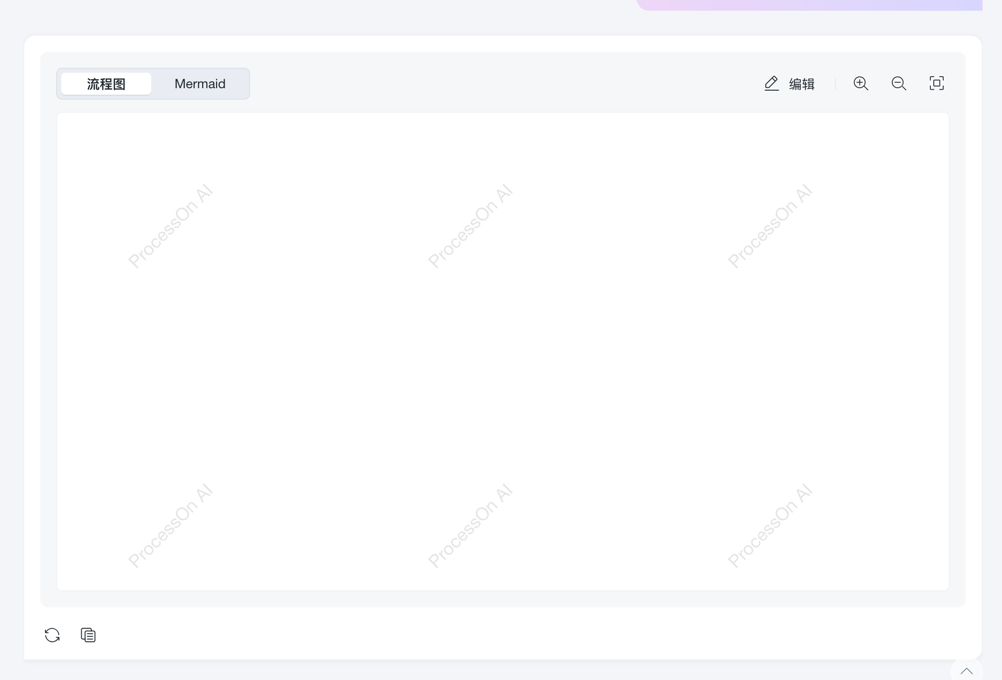

In [53]:
# BLOCK 7-F) LEARNED ONLY VALIDATION (MULTI-METRIC VERSION)
# ============================================================
# 🔥 BLOCK 7-F: LEARNED ONLY VALIDATION (MULTI-METRIC)
# - learned_only 샘플링
# - raw throughput / iops / latency 기반 검증
# - metric별 top1 share + 종합 score 계산
# - strong / medium / weak_or_noise 자동 분류
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# [0] 설정
# ============================================================
N_TOP = 10
N_RANDOM = 10
RANDOM_STATE = 42

VALIDATION_METRICS = ["throughput", "iops", "latency"]

# metric별 share threshold
# strong: 특정 노드/포트 쏠림이 매우 강함
# medium: 눈에 띄는 쏠림 존재
TOP1_SHARE_STRONG_TH = 0.70
TOP1_SHARE_MEDIUM_TH = 0.40

# support signal:
# top2/top1 격차가 크면 "상위 1개가 압도한다"는 뜻
TOP12_GAP_STRONG_TH = 0.25
TOP12_GAP_MEDIUM_TH = 0.10

# 최종 종합판정 threshold
# metric별 점수 strong=2, medium=1, weak=0
# 예:
#   latency strong + iops medium = 3점 → strong
#   2개 metric이 medium = 2점 → medium
FINAL_STRONG_SCORE_TH = 3
FINAL_MEDIUM_SCORE_TH = 2

# ============================================================
# [1] learned_only 추출
# ============================================================
required_objs = ["point_score_df", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

df_learned_only = point_score_df[
    (point_score_df["score_learned_hot"] == 1) &
    (point_score_df["original_hot"] == 0)
    ].copy()

print("\n==============================")
print("📌 LEARNED ONLY COUNT")
print("==============================")
print(f"total learned_only points: {len(df_learned_only)}")

if df_learned_only.empty:
    raise RuntimeError("❌ learned_only 없음")

# ============================================================
# [2] 샘플링
# ============================================================
if "score_learned" in df_learned_only.columns:
    df_top = df_learned_only.sort_values("score_learned", ascending=False).head(N_TOP)
else:
    print("⚠️ 'score_learned' column not found → top sample 없이 random만 사용")
    df_top = df_learned_only.head(0).copy()

df_rand = df_learned_only.sample(
    min(N_RANDOM, len(df_learned_only)),
    random_state=RANDOM_STATE
)

df_samples = (
    pd.concat([df_top, df_rand], axis=0)
    .drop_duplicates(subset=["timestamp", "stg_ip", "level", "rw"])
    .reset_index(drop=True)
)

print("\n==============================")
print("📌 SAMPLE SIZE")
print("==============================")
print(len(df_samples))

if df_samples.empty:
    raise RuntimeError("❌ validation sample이 비어 있음")

# ============================================================
# [3] helper 함수
# ============================================================
project_long = project_long.copy()
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["metric"] = project_long["metric"].astype(str).str.strip().str.lower()
project_long["level"] = project_long["level"].astype(str).str.strip().str.lower()
project_long["rw"] = project_long["rw"].astype(str).str.strip().str.lower()
project_long["stg_ip"] = project_long["stg_ip"].astype(str).str.strip().str.lower()

ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
ts_set = set(ts_list)


def classify_one_metric(top1_share, top12_gap):
    """
    metric 단위 판정:
    strong = share와 top1-top2 격차가 둘 다 매우 큼
    medium = 둘 중 하나라도 일정 수준 이상
    weak   = 나머지
    """
    if pd.isna(top1_share):
        return "no_data", 0

    if (top1_share >= TOP1_SHARE_STRONG_TH) or (top12_gap >= TOP12_GAP_STRONG_TH):
        return "strong", 2
    elif (top1_share >= TOP1_SHARE_MEDIUM_TH) or (top12_gap >= TOP12_GAP_MEDIUM_TH):
        return "medium", 1
    else:
        return "weak", 0


def classify_final(total_score, n_metric_medium_plus, n_metric_strong):
    """
    최종 종합 판정:
    - strong metric이 1개라도 있거나
    - 총점이 충분히 높으면 strong
    - medium 이상 metric이 2개 이상이거나
    - 총점이 일정 수준이면 medium
    """
    if (n_metric_strong >= 1) or (total_score >= FINAL_STRONG_SCORE_TH):
        return "strong"
    elif (n_metric_medium_plus >= 2) or (total_score >= FINAL_MEDIUM_SCORE_TH):
        return "medium"
    else:
        return "weak_or_noise"


def summarize_metric_distribution(df_metric):
    """
    하나의 metric 분포 요약
    """
    if df_metric.empty:
        return {
            "n_entities": 0,
            "total": np.nan,
            "top1_value": np.nan,
            "top2_value": np.nan,
            "top1_entity": None,
            "top2_entity": None,
            "top1_share": np.nan,
            "top2_share": np.nan,
            "top12_gap": np.nan
        }

    tmp = df_metric.copy()
    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False).reset_index(drop=True)

    if tmp.empty:
        return {
            "n_entities": 0,
            "total": np.nan,
            "top1_value": np.nan,
            "top2_value": np.nan,
            "top1_entity": None,
            "top2_entity": None,
            "top1_share": np.nan,
            "top2_share": np.nan,
            "top12_gap": np.nan
        }

    total = float(tmp["value"].sum())
    n_entities = int(len(tmp))

    top1_value = float(tmp.iloc[0]["value"])
    top1_entity = str(tmp.iloc[0]["entity_id"]) if "entity_id" in tmp.columns else None
    top1_share = top1_value / total if total > 0 else np.nan

    if len(tmp) >= 2:
        top2_value = float(tmp.iloc[1]["value"])
        top2_entity = str(tmp.iloc[1]["entity_id"]) if "entity_id" in tmp.columns else None
        top2_share = top2_value / total if total > 0 else np.nan
    else:
        top2_value = np.nan
        top2_entity = None
        top2_share = np.nan

    top12_gap = (
        (top1_share - top2_share)
        if (not pd.isna(top1_share) and not pd.isna(top2_share))
        else top1_share
    )

    return {
        "n_entities": n_entities,
        "total": total,
        "top1_value": top1_value,
        "top2_value": top2_value,
        "top1_entity": top1_entity,
        "top2_entity": top2_entity,
        "top1_share": top1_share,
        "top2_share": top2_share,
        "top12_gap": top12_gap
    }


# ============================================================
# [4] multi-metric validation
# ============================================================
results = []

for _, row in df_samples.iterrows():

    peak_ts = pd.to_datetime(row["timestamp"], errors="coerce")
    stg_ip = str(row["stg_ip"]).strip().lower()
    level = str(row["level"]).strip().lower()
    rw = str(row["rw"]).strip().lower()

    if pd.isna(peak_ts):
        continue

    # timestamp 보정
    if peak_ts not in ts_set:
        peak_ts = ts_list.iloc[(ts_list - peak_ts).abs().argmin()]

    df_peak = project_long[
        (project_long["timestamp"] == peak_ts) &
        (project_long["stg_ip"] == stg_ip) &
        (project_long["level"] == level) &
        (project_long["rw"] == rw)
        ].copy()

    if df_peak.empty:
        continue

    one_row = {
        "timestamp": peak_ts,
        "stg_ip": stg_ip,
        "level": level,
        "rw": rw
    }

    total_score = 0
    n_metric_available = 0
    n_metric_strong = 0
    n_metric_medium = 0
    n_metric_medium_plus = 0

    best_metric = None
    best_metric_share = -np.inf

    for m in VALIDATION_METRICS:
        df_m = df_peak[df_peak["metric"] == m].copy()
        stat = summarize_metric_distribution(df_m)

        metric_label, metric_score = classify_one_metric(
            top1_share=stat["top1_share"],
            top12_gap=stat["top12_gap"]
        )

        one_row[f"{m}_n_entities"] = stat["n_entities"]
        one_row[f"{m}_total"] = stat["total"]
        one_row[f"{m}_top1_value"] = stat["top1_value"]
        one_row[f"{m}_top2_value"] = stat["top2_value"]
        one_row[f"{m}_top1_entity"] = stat["top1_entity"]
        one_row[f"{m}_top2_entity"] = stat["top2_entity"]
        one_row[f"{m}_top1_share"] = stat["top1_share"]
        one_row[f"{m}_top2_share"] = stat["top2_share"]
        one_row[f"{m}_top12_gap"] = stat["top12_gap"]
        one_row[f"{m}_label"] = metric_label
        one_row[f"{m}_score"] = metric_score

        if metric_label != "no_data":
            n_metric_available += 1
            total_score += metric_score

            if metric_label == "strong":
                n_metric_strong += 1
                n_metric_medium_plus += 1
            elif metric_label == "medium":
                n_metric_medium += 1
                n_metric_medium_plus += 1

            share_for_best = stat["top1_share"]
            if not pd.isna(share_for_best) and share_for_best > best_metric_share:
                best_metric_share = share_for_best
                best_metric = m

    final_label = classify_final(
        total_score=total_score,
        n_metric_medium_plus=n_metric_medium_plus,
        n_metric_strong=n_metric_strong
    )

    one_row["validation_score"] = total_score
    one_row["n_metric_available"] = n_metric_available
    one_row["n_metric_strong"] = n_metric_strong
    one_row["n_metric_medium"] = n_metric_medium
    one_row["n_metric_medium_plus"] = n_metric_medium_plus
    one_row["best_metric"] = best_metric
    one_row["best_metric_share"] = np.nan if best_metric is None else best_metric_share
    one_row["label"] = final_label

    results.append(one_row)

df_validation = pd.DataFrame(results)

if df_validation.empty:
    raise RuntimeError("❌ df_validation이 비어 있습니다. project_long / sample 조건을 확인하세요.")

# ============================================================
# [5] 결과 출력
# ============================================================
print("\n==============================")
print("📊 VALIDATION RESULT")
print("==============================")
display_cols = [
    "timestamp", "stg_ip", "level", "rw",
    "validation_score", "n_metric_available",
    "n_metric_strong", "n_metric_medium_plus",
    "best_metric", "best_metric_share", "label"
]
print(df_validation[display_cols].head(10))

# ============================================================
# [6] 통계
# ============================================================
summary = df_validation["label"].value_counts()
ratio = df_validation["label"].value_counts(normalize=True)

print("\n==============================")
print("📊 VALIDATION SUMMARY (COUNT)")
print("==============================")
print(summary)

print("\n==============================")
print("📊 VALIDATION SUMMARY (RATIO)")
print("==============================")
print(ratio)

# metric별 strong/medium 비율도 추가 요약
metric_summary_rows = []
for m in VALIDATION_METRICS:
    vc = df_validation[f"{m}_label"].value_counts(normalize=True)
    metric_summary_rows.append({
        "metric": m,
        "strong_ratio": vc.get("strong", 0.0),
        "medium_ratio": vc.get("medium", 0.0),
        "weak_ratio": vc.get("weak", 0.0),
        "no_data_ratio": vc.get("no_data", 0.0),
        "medium_plus_ratio": vc.get("strong", 0.0) + vc.get("medium", 0.0)
    })

metric_validation_summary = pd.DataFrame(metric_summary_rows)

print("\n==============================")
print("📊 METRIC-WISE VALIDATION SUMMARY")
print("==============================")
print(metric_validation_summary)

# ============================================================
# [7] 핵심 지표
# ============================================================
strong_ratio = ratio.get("strong", 0)
medium_ratio = ratio.get("medium", 0)
weak_ratio = ratio.get("weak_or_noise", 0)

print("\n==============================")
print("🔥 FINAL INTERPRETATION")
print("==============================")
print(f"strong ratio      : {strong_ratio:.3f}")
print(f"medium ratio      : {medium_ratio:.3f}")
print(f"weak/noise ratio  : {weak_ratio:.3f}")
print(f"strong+medium     : {(strong_ratio + medium_ratio):.3f}")
print(f"avg val score     : {df_validation['validation_score'].mean():.3f}")
print(f"avg metric avail  : {df_validation['n_metric_available'].mean():.3f}")
print(f"avg medium+ count : {df_validation['n_metric_medium_plus'].mean():.3f}")


📌 LEARNED ONLY COUNT
total learned_only points: 4243

📌 SAMPLE SIZE
20

📊 VALIDATION RESULT
            timestamp                            stg_ip level     rw  \
0 2025-09-12 08:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
1 2025-09-10 02:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
2 2025-10-31 21:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
3 2025-11-02 07:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
4 2025-10-27 11:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
5 2025-09-14 05:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
6 2025-09-29 22:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
7 2025-11-05 20:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
8 2025-10-29 22:00:00  96353914610fbf899a486bbc516a0fcb  node  write   
9 2025-11-02 04:30:00  96353914610fbf899a486bbc516a0fcb  node  write   

   validation_score  n_metric_available  n_metric_strong  \
0                 5                   3               

# BLOCK 7-G) FINAL VALIDATION FIGURE (MULTI-METRIC VERSION, SHOW ONLY)

In [54]:
# BLOCK 7-G) FINAL VALIDATION FIGURE (MULTI-METRIC VERSION, SHOW ONLY)
# ============================================================
# 🔥 BLOCK 7-G: FINAL VALIDATION FIGURE (MULTI-METRIC)
# - 저장하지 않고 화면에만 출력
# - Panel A: Original vs Learned overlap structure
# - Panel B: Learned-only validation summary
# - Panel C: Metric-wise validation strength
# - Panel D: Representative case study
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["point_compare_df", "df_validation", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if df_validation.empty:
    raise ValueError("❌ df_validation이 비어 있습니다. BLOCK 7-F를 먼저 실행하세요.")

# ------------------------------------------------------------
# 1) Panel A data: Original vs Learned overlap structure
# ------------------------------------------------------------
pc = point_compare_df.copy()
pc["method"] = pc["method"].astype(str).str.strip().str.lower()

learned_row = pc[pc["method"] == "learned"]
if learned_row.empty:
    raise ValueError("❌ point_compare_df 안에 method='learned'가 없습니다.")

learned_row = learned_row.iloc[0]

n_overlap = int(learned_row["overlap_points"])
n_learned_only = int(learned_row["new_only_points"])
n_original_only = int(learned_row["missed_original_points"])
jaccard_val = float(learned_row["jaccard_vs_original"])

panelA_labels = ["Original only", "Overlap", "Learned only"]
panelA_values = [n_original_only, n_overlap, n_learned_only]

# ------------------------------------------------------------
# 2) Panel B data: final validation summary
# ------------------------------------------------------------
val = df_validation.copy()
val["label"] = val["label"].astype(str).str.strip().str.lower()

label_order = ["strong", "medium", "weak_or_noise"]
label_counts = val["label"].value_counts().reindex(label_order, fill_value=0)
label_ratios = (label_counts / max(label_counts.sum(), 1)).fillna(0.0)

panelB_labels = ["Strong", "Medium", "Weak/Noise"]
panelB_values = [
    label_ratios.get("strong", 0.0),
    label_ratios.get("medium", 0.0),
    label_ratios.get("weak_or_noise", 0.0)
]

strong_plus_medium = panelB_values[0] + panelB_values[1]
avg_val_score = float(val["validation_score"].mean()) if "validation_score" in val.columns else np.nan
avg_medium_plus = float(val["n_metric_medium_plus"].mean()) if "n_metric_medium_plus" in val.columns else np.nan

# ------------------------------------------------------------
# 3) Panel C data: metric-wise validation summary
# ------------------------------------------------------------
metrics = ["throughput", "iops", "latency"]

metric_rows = []
for m in metrics:
    col = f"{m}_label"
    if col not in val.columns:
        raise ValueError(f"❌ required column missing: {col}")

    vc = val[col].astype(str).str.strip().str.lower().value_counts(normalize=True)

    metric_rows.append({
        "metric": m,
        "strong_ratio": vc.get("strong", 0.0),
        "medium_ratio": vc.get("medium", 0.0),
        "weak_ratio": vc.get("weak", 0.0),
        "no_data_ratio": vc.get("no_data", 0.0),
        "medium_plus_ratio": vc.get("strong", 0.0) + vc.get("medium", 0.0)
    })

metric_validation_summary = pd.DataFrame(metric_rows)

# ------------------------------------------------------------
# 4) Panel D data: representative case study
#    대표 케이스 = validation_score 가장 높고,
#    동점이면 best_metric_share가 높은 것
# ------------------------------------------------------------
sort_cols = []
ascending_list = []

if "validation_score" in val.columns:
    sort_cols.append("validation_score")
    ascending_list.append(False)

if "best_metric_share" in val.columns:
    sort_cols.append("best_metric_share")
    ascending_list.append(False)

sort_cols.append("timestamp")
ascending_list.append(True)

val_case = val.sort_values(sort_cols, ascending=ascending_list).iloc[0]

case_ts = pd.to_datetime(val_case["timestamp"])
case_stg = str(val_case["stg_ip"]).lower()
case_level = str(val_case["level"]).lower()
case_rw = str(val_case["rw"]).lower()

project_long = project_long.copy()
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["stg_ip"] = project_long["stg_ip"].astype(str).str.strip().str.lower()
project_long["level"] = project_long["level"].astype(str).str.strip().str.lower()
project_long["rw"] = project_long["rw"].astype(str).str.strip().str.lower()
project_long["metric"] = project_long["metric"].astype(str).str.strip().str.lower()

ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
ts_set = set(ts_list)

if case_ts not in ts_set:
    case_ts = ts_list.iloc[(ts_list - case_ts).abs().argmin()]

case_rows = []
for m in metrics:
    tmp = project_long[
        (project_long["timestamp"] == case_ts) &
        (project_long["stg_ip"] == case_stg) &
        (project_long["level"] == case_level) &
        (project_long["rw"] == case_rw) &
        (project_long["metric"] == m)
        ].copy()

    if tmp.empty:
        case_rows.append({
            "metric": m,
            "top1_share": np.nan,
            "top1_entity": "N/A",
            "top1_value": np.nan
        })
        continue

    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False)

    total = float(tmp["value"].sum())
    top1_value = float(tmp.iloc[0]["value"])
    top1_share = top1_value / total if total > 0 else np.nan
    top1_entity = str(tmp.iloc[0]["entity_id"]) if "entity_id" in tmp.columns else "N/A"

    case_rows.append({
        "metric": m,
        "top1_share": top1_share,
        "top1_entity": top1_entity,
        "top1_value": top1_value
    })

case_df = pd.DataFrame(case_rows)

# ------------------------------------------------------------
# 5) figure drawing
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# ---------------- Panel A ----------------
ax = axes[0]
barsA = ax.bar(panelA_labels, panelA_values)
ax.set_title("A. Original vs Learned Point Structure")
ax.set_ylabel("Number of hot points")

for b, v in zip(barsA, panelA_values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.text(
    0.02, 0.95,
    f"Jaccard = {jaccard_val:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# ---------------- Panel B ----------------
ax = axes[1]
barsB = ax.bar(panelB_labels, panelB_values)
ax.set_title("B. Validation of Learned-only Hotspots")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1.05)

for b, ratio_val, cnt_val in zip(barsB, panelB_values, label_counts.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{ratio_val:.2f}\n(n={cnt_val})",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.text(
    0.02, 0.95,
    f"Strong + Medium = {strong_plus_medium:.2f}\n"
    f"Avg score = {avg_val_score:.2f}\n"
    f"Avg medium+ metrics = {avg_medium_plus:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# ---------------- Panel C ----------------
ax = axes[2]

x = np.arange(len(metrics))
strong_vals = metric_validation_summary["strong_ratio"].values
medium_vals = metric_validation_summary["medium_ratio"].values
weak_vals = metric_validation_summary["weak_ratio"].values

bars_strong = ax.bar(x, strong_vals, label="Strong")
bars_medium = ax.bar(x, medium_vals, bottom=strong_vals, label="Medium")
bars_weak = ax.bar(x, weak_vals, bottom=(strong_vals + medium_vals), label="Weak")

ax.set_title("C. Metric-wise Validation Strength")
ax.set_ylabel("Ratio")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.05)
ax.legend()

for i, row in metric_validation_summary.iterrows():
    ax.text(
        i,
        1.01,
        f"M+={row['medium_plus_ratio']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ---------------- Panel D ----------------
ax = axes[3]
barsD = ax.bar(case_df["metric"], case_df["top1_share"])
ax.set_title("D. Representative Case Study")
ax.set_ylabel("Top1 share")
ax.set_ylim(0, 1.05)

for _, r in case_df.iterrows():
    metric_name = r["metric"]
    y = r["top1_share"]

    if pd.isna(y):
        continue

    x_pos = list(case_df["metric"]).index(metric_name)
    txt = f"{r['top1_share']:.2f}\n{r['top1_entity']}"
    ax.text(
        x_pos,
        y,
        txt,
        ha="center",
        va="bottom",
        fontsize=9
    )

case_title = (
    f"score={val_case['validation_score']}, "
    f"best={val_case['best_metric']} ({val_case['best_metric_share']:.2f})\n"
    f"stg={case_stg[:8]}..., level={case_level}, rw={case_rw}\n"
    f"ts={str(case_ts)}"
)
ax.text(
    0.02, 0.95,
    case_title,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

fig.suptitle(
    "Learned Hotspot Validation: Low Overlap, High Practical Meaning",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) source table display only
# ------------------------------------------------------------
panelA_df = pd.DataFrame({
    "category": panelA_labels,
    "count": panelA_values
})

panelB_df = pd.DataFrame({
    "label": panelB_labels,
    "ratio": panelB_values,
    "count": label_counts.values
})

print("\n==============================")
print("PANEL A DATA")
print("==============================")
print(panelA_df)

print("\n==============================")
print("PANEL B DATA")
print("==============================")
print(panelB_df)

print("\n==============================")
print("PANEL C DATA")
print("==============================")
print(metric_validation_summary)

print("\n==============================")
print("PANEL D DATA")
print("==============================")
print(case_df)


PANEL A DATA
        category  count
0  Original only   2535
1        Overlap    447
2   Learned only   4243

PANEL B DATA
        label  ratio  count
0      Strong   0.85     17
1      Medium   0.15      3
2  Weak/Noise   0.00      0

PANEL C DATA
       metric  strong_ratio  medium_ratio  weak_ratio  no_data_ratio  \
0  throughput          0.05          0.50        0.45            0.0   
1        iops          0.35          0.50        0.15            0.0   
2     latency          0.75          0.25        0.00            0.0   

   medium_plus_ratio  
0               0.55  
1               0.85  
2               1.00  

PANEL D DATA
       metric  top1_share   top1_entity  top1_value
0  throughput    0.403351  node_78fgcw0      403.25
1        iops    0.564851  node_78fgcw0     7425.25
2     latency    0.928571  node_78fgbh0        6.50


In [34]:
# ============================================================
# 🔥 BLOCK 7-H: REPRESENTATIVE CASE RAW DISTRIBUTION (SHOW ONLY)
# - 대표 learned-only case 1개 선택
# - node-level raw values를 metric별로 비교
# - throughput / iops / latency 3개 패널
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["df_validation", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if df_validation.empty:
    raise ValueError("❌ df_validation이 비어 있습니다. BLOCK 7-F를 먼저 실행하세요.")

# ------------------------------------------------------------
# 1) 대표 case 선택
#    - latency_top1_share가 가장 높은 case
# ------------------------------------------------------------
val_case = df_validation.sort_values(
    ["latency_top1_share", "timestamp"],
    ascending=[False, True]
).iloc[0]

case_ts = pd.to_datetime(val_case["timestamp"])
case_stg = str(val_case["stg_ip"]).lower()
case_level = str(val_case["level"]).lower()
case_rw = str(val_case["rw"]).lower()

# timestamp 보정
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values()

if case_ts not in set(ts_list):
    case_ts = ts_list.iloc[(ts_list - case_ts).abs().argmin()]

print("\n==============================")
print("🎯 REPRESENTATIVE CASE")
print("==============================")
print(f"timestamp : {case_ts}")
print(f"stg_ip    : {case_stg}")
print(f"level     : {case_level}")
print(f"rw        : {case_rw}")
print(f"lat_share : {val_case['latency_top1_share']:.3f}")

# ------------------------------------------------------------
# 2) metric별 raw table 만들기
# ------------------------------------------------------------
metrics = ["throughput", "iops", "latency"]
metric_tables = {}

for m in metrics:
    tmp = project_long[
        (project_long["timestamp"] == case_ts) &
        (project_long["stg_ip"].astype(str).str.lower() == case_stg) &
        (project_long["level"].astype(str).str.lower() == case_level) &
        (project_long["rw"].astype(str).str.lower() == case_rw) &
        (project_long["metric"].astype(str).str.lower() == m)
    ].copy()

    if tmp.empty:
        metric_tables[m] = pd.DataFrame(columns=["entity_id", "value", "share"])
        continue

    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False).copy()

    total = float(tmp["value"].sum())
    tmp["share"] = tmp["value"] / total if total > 0 else 0.0

    metric_tables[m] = tmp[["entity_id", "value", "share"]].reset_index(drop=True)

# ------------------------------------------------------------
# 3) figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m in zip(axes, metrics):
    tmp = metric_tables[m].copy()

    if tmp.empty:
        ax.set_title(f"{m} (no data)")
        ax.axis("off")
        continue

    x = tmp["entity_id"].astype(str).tolist()
    y = tmp["value"].astype(float).tolist()
    bars = ax.bar(x, y)

    ax.set_title(f"{m.capitalize()} by node")
    ax.set_xlabel("Node")
    ax.set_ylabel("Raw value")
    ax.tick_params(axis="x", rotation=30)

    # top1 share 표시
    top1_share = float(tmp.iloc[0]["share"]) if len(tmp) > 0 else np.nan
    ax.text(
        0.02, 0.95,
        f"Top1 share = {top1_share:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
    )

    # 각 막대 위 value + share 표시
    for b, (_, row) in zip(bars, tmp.iterrows()):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height(),
            f"{row['value']:.2f}\n({row['share']:.2f})",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    f"Representative Learned-only Hotspot: Node-level Raw Distribution\n"
    f"stg={case_stg[:8]}..., level={case_level}, rw={case_rw}, ts={case_ts}",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) 테이블도 화면에 출력
# ------------------------------------------------------------
for m in metrics:
    print("\n==============================")
    print(f"{m.upper()} TABLE")
    print("==============================")
    print(metric_tables[m])


🎯 REPRESENTATIVE CASE
timestamp : 2025-09-12 08:30:00
stg_ip    : 96353914610fbf899a486bbc516a0fcb
level     : node
rw        : write
lat_share : 0.929

THROUGHPUT TABLE
      entity_id   value     share
0  node_78fgcw0  403.25  0.403351
1  node_78fgbh0  359.75  0.359840
2  node_78ghzb0  125.75  0.125781
3  node_78ghxg0  111.00  0.111028

IOPS TABLE
      entity_id    value     share
0  node_78fgcw0  7425.25  0.564851
1  node_78fgbh0  3288.25  0.250143
2  node_78ghxg0  1524.00  0.115933
3  node_78ghzb0   908.00  0.069073

LATENCY TABLE
      entity_id  value     share
0  node_78fgbh0    6.5  0.928571
1  node_78ghzb0    0.5  0.071429
2  node_78fgcw0    0.0  0.000000
3  node_78ghxg0    0.0  0.000000


In [60]:
# ============================================================
# 🔥 COMPLETE WEIGHTED LEARNING PIPELINE (NODE + PORT)
# ============================================================
# 이 하나의 셀만 실행하면 됨!
# - 6-A: 설정 (node + port 둘 다 포함! 🆕)
# - 6-B: Point Feature Table 생성
# - 6-C: Positive Peak / Negative / Pair Table
# - 6-D: Diagonal Weighted Metric Learning
# - 6-E: Learned Weight 적용 → Point Score
# - 6-F: Robustness Experiment (생략가능, 포함함)
# - 7-C: Final Episode Extraction (level 컬럼 포함!)
#
# 📌 전제조건: 앞선 블록(0~5)에서 아래 변수들이 메모리에 있어야 함
#   project_long, imb_long, limits_imb, segments_final,
#   point_labels, load_ref, base_long, stg_list, OUTPUT_DIR,
#   IMB_METRICS_REVISED, INPUT_DIR, CACHE_DIR
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
from scipy.special import softmax as scipy_softmax
from scipy.stats import rankdata


# ============================================================
# BLOCK 6-A) CONFIG — node + port 둘 다 포함! 🆕
# ============================================================
WL_LEVELS = ["node", "port"]          # ← 요기! 기존: WL_LEVEL = "node" 였음
WL_RWS = ["read", "write"]
WL_SRC_METRICS = ["throughput", "iops", "latency"]

WL_POS_TIERS = ["strong"]
WL_NEG_BUFFER_BINS = 1
WL_NEG_PER_POS = 2
WL_POS_NEIGHBORS = 2
WL_MIN_NEG_POOL_PER_CONTEXT = 5
WL_ALLOW_NEG_FALLBACK_ACROSS_STG = True
WL_ALLOW_POS_FALLBACK_ACROSS_STG = True

WL_USE_RAW_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
WL_USE_SEV_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
WL_USE_LOAD_RATIO = True
WL_USE_ACTIVE_RATIO = True

WL_TRAIN_Q = 0.70
WL_VALID_Q = 0.85

WL_OUT_DIR = OUTPUT_DIR / "weighted_learning_v1"
WL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("WL_CONFIG: levels =", WL_LEVELS, "(node+port both!)")
print("WL_OUT_DIR:", WL_OUT_DIR)


# ============================================================
# BLOCK 6-B) POINT FEATURE TABLE (node+port)
# ============================================================
print("\n" + "=" * 70)
print("BLOCK 6-B) BUILDING POINT FEATURE TABLE...")

# 데이터 정리
for df_name in ["imb_long", "limits_imb", "segments_final", "point_labels", "load_ref"]:
    df = globals()[df_name]
    for c in df.columns:
        if c in ["stg_ip", "level", "entity_id", "rw", "metric", "imb_metric", "src_metric", "hotspot_tier"]:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    globals()[df_name] = df

# 🆕 핵심 수정: level == "node" → level.isin(["node","port"])
imb_use = imb_long[
    (imb_long["level"].isin(WL_LEVELS)) &
    (imb_long["rw"].isin(WL_RWS)) &
    (imb_long["src_metric"].isin(WL_SRC_METRICS)) &
    (imb_long["imb_metric"].isin(IMB_METRICS_REVISED))
].copy()

print(f"  imb_use shape (node+port): {imb_use.shape}")
print(f"  level distribution:\n{imb_use['level'].value_counts()}")

# limits merge
lim_key = ["stg_ip", "level", "entity_id", "rw", "metric"]
lim_use = limits_imb.copy()
for c in lim_key:
    lim_use[c] = lim_use[c].astype(str).str.strip().str.lower()

imb_use["entity_id"] = imb_use["entity_id"].astype(str).str.strip().str.lower()
imb_use["metric"] = imb_use["metric"].astype(str).str.strip().str.lower()

imb_use = imb_use.merge(
    lim_use[lim_key + ["CL", "SIGMA", "UCL", "LCL"]],
    on=lim_key,
    how="left"
)

# severity
imb_use["severity_over_ucl"] = np.maximum(
    0.0,
    (pd.to_numeric(imb_use["value"], errors="coerce") - pd.to_numeric(imb_use["UCL"], errors="coerce")) /
    np.maximum(np.abs(pd.to_numeric(imb_use["UCL"], errors="coerce")), 1e-12)
)

# point-wide feature
# 🆕 entity_id 포함해서 노드명/포트번호 유지
point_keys = ["timestamp", "stg_ip", "level", "entity_id", "rw", "src_metric"]

base_meta = (
    imb_use.groupby(point_keys, observed=True)
    .agg(
        group_total=("group_total", "max"),
        n_entities=("n_entities", "max"),
        active_entities=("active_entities", "max")
    )
    .reset_index()
)

raw_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="value",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
raw_wide.columns.name = None
raw_wide = raw_wide.rename(columns={c: f"raw_{c}" for c in raw_wide.columns if c not in point_keys})

sev_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="severity_over_ucl",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
sev_wide.columns.name = None
sev_wide = sev_wide.rename(columns={c: f"sev_{c}" for c in sev_wide.columns if c not in point_keys})

point_features = base_meta.merge(raw_wide, on=point_keys, how="left")
point_features = point_features.merge(sev_wide, on=point_keys, how="left")

# load reference merge
point_features = point_features.merge(
    load_ref[["stg_ip", "level", "rw", "src_metric", "load_floor", "baseline_load_median", "baseline_n"]],
    on=["stg_ip", "level", "rw", "src_metric"],
    how="left"
)

point_features["load_ratio"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["load_floor"], errors="coerce"), 1e-12)
)
point_features["active_ratio"] = (
    pd.to_numeric(point_features["active_entities"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["n_entities"], errors="coerce"), 1e-12)
)

point_features["passes_load_gate"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") >=
    pd.to_numeric(point_features["load_floor"], errors="coerce")
).fillna(False)

# point label merge
point_label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]
point_label_flag = point_labels[point_label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
point_label_flag["has_hot_label"] = 1

point_features = point_features.merge(
    point_label_flag,
    on=point_label_key,
    how="left"
)
point_features["has_hot_label"] = point_features["has_hot_label"].fillna(0).astype(int)

# unique point id
point_features = point_features.sort_values(point_keys).reset_index(drop=True)
point_features["point_id"] = np.arange(1, len(point_features) + 1)

# leakage-free feature list
WL_FEATURE_COLS = []

for m in WL_USE_RAW_IMB:
    c = f"raw_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

for m in WL_USE_SEV_IMB:
    c = f"sev_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

if WL_USE_LOAD_RATIO and "load_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("load_ratio")

if WL_USE_ACTIVE_RATIO and "active_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("active_ratio")

for c in WL_FEATURE_COLS:
    point_features[c] = pd.to_numeric(point_features[c], errors="coerce").fillna(0.0)

print(f"  point_features: {point_features.shape} (was 192265 node-only)")
print(f"  level distribution:\n{point_features['level'].value_counts()}")
print(f"  WL_FEATURE_COLS: {WL_FEATURE_COLS}")

# save
point_features.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_NODE.parquet", index=False)


# ============================================================
# BLOCK 6-C) POSITIVE PEAKS + CLEAN NEGATIVES + PAIRS
# ============================================================
print("\n" + "=" * 70)
print("BLOCK 6-C) BUILDING POS/NEG SAMPLES & PAIRS...")

# --- positive samples ---
pos_mask = point_features["has_hot_label"] == 1
pos_base = point_features[pos_mask].copy()

if WL_POS_TIERS:
    pos_base = pos_base[pos_base["hotspot_tier"].isin(WL_POS_TIERS)]

pos_base = pos_base.dropna(subset=["segment_id"])
pos_base = pos_base.sort_values(["segment_id", "timestamp"]).reset_index(drop=True)

pos_samples = (
    pos_base.groupby("segment_id")
    .apply(lambda g: g.loc[g["hotspot_score"].idxmax()] if "hotspot_score" in g.columns else g.iloc[0])
    .reset_index(drop=True)
)

# time-based split
time_sorted = pos_samples.sort_values("timestamp").reset_index(drop=True)
n_pos = len(time_sorted)
train_end_idx = int(n_pos * WL_TRAIN_Q)
valid_end_idx = int(n_pos * WL_VALID_Q)

train_ids = set(time_sorted.iloc[:train_end_idx]["point_id"].tolist())
valid_ids = set(time_sorted.iloc[train_end_idx:valid_end_idx]["point_id"].tolist())
test_ids = set(time_sorted.iloc[valid_end_idx:]["point_id"].tolist())

def assign_split(row):
    pid = row["point_id"]
    if pid in train_ids:
        return "train"
    elif pid in valid_ids:
        return "valid"
    else:
        return "test"

pos_samples["split"] = pos_samples.apply(assign_split, axis=1)

# --- negative samples ---
neg_buffer = pd.Timedelta(minutes=WL_NEG_BUFFER_BINS * 30)

all_neg_rows = []
for _, pos_row in pos_samples.iterrows():
    context_filter = (
        (point_features["stg_ip"] == pos_row["stg_ip"]) &
        (point_features["level"] == pos_row["level"]) &
        (point_features["rw"] == pos_row["rw"]) &
        (point_features["src_metric"] == pos_row["src_metric"]) &
        (point_features["passes_load_gate"]) &
        (point_features["has_hot_label"] == 0)
    )

    candidate_neg = point_features[context_filter].copy()
    if candidate_neg.empty:
        if WL_ALLOW_NEG_FALLBACK_ACROSS_STG:
            fallback = (
                (point_features["level"] == pos_row["level"]) &
                (point_features["rw"] == pos_row["rw"]) &
                (point_features["src_metric"] == pos_row["src_metric"]) &
                (point_features["passes_load_gate"]) &
                (point_features["has_hot_label"] == 0)
            )
            candidate_neg = point_features[fallback].copy()
        if candidate_neg.empty:
            continue

    ts = pd.Timestamp(pos_row["timestamp"])
    candidate_neg = candidate_neg[
        (candidate_neg["timestamp"] < ts - neg_buffer) |
        (candidate_neg["timestamp"] > ts + neg_buffer)
    ]

    if len(candidate_neg) >= WL_MIN_NEG_POOL_PER_CONTEXT:
        chosen = candidate_neg.sample(n=min(WL_NEG_PER_POS, len(candidate_neg)), random_state=42)
        for _, neg_row in chosen.iterrows():
            all_neg_rows.append({
                **{k: neg_row[k] for k in point_keys},
                "point_id": neg_row["point_id"],
                "split": pos_row["split"],
                "y": 0
            })

neg_samples = pd.DataFrame(all_neg_rows) if all_neg_rows else pd.DataFrame(
    columns=list(pos_samples.columns) + ["split", "y"]
)
if not neg_samples.empty:
    neg_samples = neg_samples.drop_duplicates(subset=["point_id"])

train_samples = pd.concat([pos_samples, neg_samples], ignore_index=True)

# --- pair table ---
pair_rows = []
for _, pos_row in pos_samples.iterrows():
    # similar pairs (positive neighbors)
    same_context = train_samples[
        (train_samples["stg_ip"] == pos_row["stg_ip"]) &
        (train_samples["level"] == pos_row["level"]) &
        (train_samples["rw"] == pos_row["rw"]) &
        (train_samples["src_metric"] == pos_row["src_metric"]) &
        (train_samples["has_hot_label"] == 1) &
        (train_samples["point_id"] != pos_row["point_id"])
    ]
    if not same_context.empty:
        similar_candidates = same_context.sample(
            n=min(WL_POS_NEIGHBORS, len(same_context)), random_state=42
        )
        for _, sim_row in similar_candidates.iterrows():
            pair_rows.append({
                "left_point_id": pos_row["point_id"],
                "right_point_id": sim_row["point_id"],
                "split": pos_row["split"],
                "pair_type": "similar",
                "y": 1
            })

    # dissimilar pairs (negative samples)
    neg_for_pair = train_samples[
        (train_samples["point_id"].isin(neg_samples["point_id"])) &
        (train_samples["split"] == pos_row["split"])
    ]
    if not neg_for_pair.empty:
        dissimilar_candidates = neg_for_pair.sample(
            n=min(WL_NEG_PER_POS, len(neg_for_pair)), random_state=42
        )
        for _, diss_row in dissimilar_candidates.iterrows():
            pair_rows.append({
                "left_point_id": pos_row["point_id"],
                "right_point_id": diss_row["point_id"],
                "split": pos_row["split"],
                "pair_type": "dissimilar",
                "y": 0
            })

pair_table = pd.DataFrame(pair_rows)
if not pair_table.empty:
    pair_table = pair_table.drop_duplicates(
        subset=["left_point_id", "right_point_id", "pair_type"]
    ).reset_index(drop=True)

print(f"  pos_samples: {pos_samples.shape}")
print(f"  neg_samples: {neg_samples.shape}")
print(f"  pair_table:  {pair_table.shape}")
print(f"  split distribution:\n{pair_table.groupby(['split','pair_type']).size()}")

# save
train_samples.to_parquet(WL_OUT_DIR / "WL_TRAIN_SAMPLES_NODE.parquet", index=False)
neg_pool_clean = train_samples[train_samples["y"] == 0].copy()
neg_pool_clean.to_parquet(WL_OUT_DIR / "WL_NEG_POOL_NODE.parquet", index=False)
pair_table.to_parquet(WL_OUT_DIR / "WL_PAIR_TABLE_NODE.parquet", index=False)


# ============================================================
# BLOCK 6-D) DIAGONAL WEIGHTED METRIC LEARNING
# ============================================================
print("\n" + "=" * 70)
print("BLOCK 6-D) WEIGHTED METRIC LEARNING OPTIMIZATION...")

WL_MULTI_START_SEEDS = [7, 21, 42, 84, 168]
WL_INIT_NOISE = 0.05
WL_NEG_HINGE_WEIGHT = 1.0
WL_L2_SIMPLEX = 1e-3
WL_USE_DATA_DRIVEN_MARGIN = True

# helpers
def robust_scale_fit(X_df):
    med = X_df.median()
    mad = (X_df - med).abs().median()
    mad = mad.replace(0, 1.0)
    return med, mad

def robust_scale_transform(X_df, med, mad):
    return (X_df - med) / mad

def softmax_logits(alpha):
    alpha = np.asarray(alpha, dtype=float)
    alpha = alpha - np.max(alpha)
    e = np.exp(alpha)
    return e / np.sum(e)

def fast_auc_binary(labels, scores):
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores, dtype=float)
    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan
    ranks = rankdata(scores, method="average")
    n_pos = int(labels.sum())
    n_neg = int(len(labels) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[labels == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

def eval_pairs(Z, y, w):
    if len(Z) == 0:
        return {"n_pairs": 0, "pos_mean_dist": np.nan, "neg_mean_dist": np.nan,
                "gap_neg_minus_pos": np.nan, "auc_pair_distance": np.nan}
    dist = Z @ w
    pos_mask = (y == 1)
    neg_mask = (y == 0)
    pos_mean = float(dist[pos_mask].mean()) if np.any(pos_mask) else np.nan
    neg_mean = float(dist[neg_mask].mean()) if np.any(neg_mask) else np.nan
    gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
    label_neg = 1 - y
    auc = fast_auc_binary(label_neg, dist)
    return {"n_pairs": int(len(y)), "pos_mean_dist": pos_mean, "neg_mean_dist": neg_mean,
            "gap_neg_minus_pos": gap, "auc_pair_distance": auc}

def feature_gap_diagnostic(Z, y, feature_names):
    rows = []
    for j, f in enumerate(feature_names):
        zj = Z[:, j]
        pos_mean = float(zj[y == 1].mean()) if np.any(y == 1) else np.nan
        neg_mean = float(zj[y == 0].mean()) if np.any(y == 0) else np.nan
        gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
        rows.append({"feature": f, "pos_mean_sqdiff": pos_mean, "neg_mean_sqdiff": neg_mean,
                     "gap_neg_minus_pos_feature": gap})
    out = pd.DataFrame(rows).sort_values("gap_neg_minus_pos_feature", ascending=False).reset_index(drop=True)
    return out

def choose_margin_from_equal(Z, y, w_equal):
    d = Z @ w_equal
    pos = d[y == 1]
    neg = d[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return 1.0
    return float(0.5 * (pos.mean() + neg.mean()))

def simplex_metric_loss(alpha, Z, y, margin, neg_hinge_weight=1.0, l2_simplex=1e-3):
    w = softmax_logits(alpha)
    d = Z @ w
    pos_loss = float(d[y == 1].mean()) if (d[y == 1]).sum() > 0 else 0.0
    neg_hinge = float(np.maximum(0.0, margin - d[y == 0]).mean()) if (y == 0).sum() > 0 else 0.0
    reg = float(l2_simplex * np.sum(w * w))
    total = pos_loss + neg_hinge_weight * neg_hinge + reg
    parts = {"total_loss": total, "pos_loss": pos_loss, "neg_hinge_loss": neg_hinge, "l2_loss": reg}
    return total, parts

# split
samples_train = train_samples[train_samples["split"] == "train"].copy()
samples_valid = train_samples[train_samples["split"] == "valid"].copy()
samples_test = train_samples[train_samples["split"] == "test"].copy()
pairs_train = pair_table[pair_table["split"] == "train"].copy()
pairs_valid = pair_table[pair_table["split"] == "valid"].copy()
pairs_test = pair_table[pair_table["split"] == "test"].copy()

print(f"  samples_train: {samples_train.shape}, pairs_train: {pairs_train.shape}")

# robust scaling
X_train_df = samples_train.set_index("point_id")[WL_FEATURE_COLS].copy()
med, mad = robust_scale_fit(X_train_df)

for df_name in ["samples_train", "samples_valid", "samples_test"]:
    tmp = globals()[df_name].copy()
    tmp_scaled = robust_scale_transform(tmp[WL_FEATURE_COLS], med, mad).fillna(0.0)
    for c in WL_FEATURE_COLS:
        tmp[f"scaled__{c}"] = tmp_scaled[c].values
    globals()[df_name] = tmp

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

def build_feature_map(df_samples, scaled_cols):
    mat = df_samples.set_index("point_id")[scaled_cols].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

feat_map_train = build_feature_map(samples_train, SCALED_COLS)
feat_map_valid = build_feature_map(samples_valid, SCALED_COLS)
feat_map_test = build_feature_map(samples_test, SCALED_COLS)

# pair -> squared diff matrix
def pair_to_Z(pair_df, feat_map):
    rows, ys, keep_idx = [], [], []
    for i, row in pair_df.iterrows():
        li = int(row["left_point_id"])
        ri = int(row["right_point_id"])
        if li not in feat_map or ri not in feat_map:
            continue
        xi = feat_map[li]
        xj = feat_map[ri]
        z = (xi - xj) ** 2
        rows.append(z); ys.append(float(row["y"])); keep_idx.append(i)
    Z = np.vstack(rows) if rows else np.zeros((0, len(WL_FEATURE_COLS)))
    y = np.array(ys, dtype=float)
    kept = pair_df.loc[keep_idx].copy().reset_index(drop=True) if keep_idx else pair_df.iloc[:0].copy()
    return Z, y, kept

Z_train, y_train, pairs_train_used = pair_to_Z(pairs_train, feat_map_train)
Z_valid, y_valid, pairs_valid_used = pair_to_Z(pairs_valid, feat_map_valid)
Z_test, y_test, pairs_test_used = pair_to_Z(pairs_test, feat_map_test)

if len(Z_train) == 0:
    raise RuntimeError("train pair가 0개입니다.")

# equal baseline
w_equal = np.ones(len(WL_FEATURE_COLS), dtype=float) / len(WL_FEATURE_COLS)
feature_diag_table = feature_gap_diagnostic(Z_train, y_train, WL_FEATURE_COLS)
margin_equal = choose_margin_from_equal(Z_train, y_train, w_equal)
selected_margin = margin_equal if WL_USE_DATA_DRIVEN_MARGIN else 12.0

# initialization
gap_arr = feature_diag_table.set_index("feature").loc[WL_FEATURE_COLS, "gap_neg_minus_pos_feature"].fillna(0.0).values
gap_std = float(np.std(gap_arr))
alpha_base = (gap_arr - np.mean(gap_arr)) / gap_std if gap_std >= 1e-12 else np.zeros(len(WL_FEATURE_COLS), dtype=float)

# multi-start optimization
best_obj, best_alpha, best_w, best_history, best_seed = None, None, None, None, None
restart_rows = []

def run_one_restart(seed, alpha_base, Z_tr, y_tr, Z_va, y_va):
    rng = np.random.default_rng(seed)
    alpha0 = alpha_base + rng.normal(0.0, WL_INIT_NOISE, size=len(alpha_base))
    local_history = []
    def obj(alpha):
        total, parts = simplex_metric_loss(alpha, Z_tr, y_tr, selected_margin, WL_NEG_HINGE_WEIGHT, WL_L2_SIMPLEX)
        wn = softmax_logits(alpha)
        local_history.append({"seed": seed, "total_loss": parts["total_loss"], "pos_loss": parts["pos_loss"],
                              "neg_hinge_loss": parts["neg_hinge_loss"], "l2_loss": parts["l2_loss"],
                              "w_max": float(wn.max()), "w_min": float(wn.min())})
        return total
    res = minimize(obj, alpha0, method="L-BFGS-B", options={"maxiter": 300})
    wh = softmax_logits(res.x)
    tr_ev = eval_pairs(Z_tr, y_tr, wh)
    va_ev = eval_pairs(Z_va, y_va, wh) if len(Z_va) > 0 else {"gap_neg_minus_pos": np.nan, "auc_pair_distance": np.nan}
    sc = va_ev["gap_neg_minus_pos"]; sc = sc if np.isfinite(sc) else tr_ev["gap_neg_minus_pos"]
    summary = {"seed": seed, "success": bool(res.success), "score_to_maximize": sc,
               "train_gap": tr_ev["gap_neg_minus_pos"], "valid_gap": va_ev["gap_neg_minus_pos"]}
    for j, f in enumerate(WL_FEATURE_COLS):
        summary[f"w__{f}"] = float(wh[j])
    return res, res.x, wh, pd.DataFrame(local_history), summary

for s in WL_MULTI_START_SEEDS:
    res_i, al_i, wi, hi, si = run_one_restart(s, alpha_base, Z_train, y_train, Z_valid, y_valid)
    restart_rows.append(si)
    cur_sc = si["score_to_maximize"]
    if best_obj is None or (np.isfinite(cur_sc) and cur_sc > best_obj):
        best_obj, best_alpha, best_w, best_history, best_seed = cur_sc, al_i, wi, hi, s

restart_summary = pd.DataFrame(restart_rows).sort_values("score_to_maximize", ascending=False).reset_index(drop=True)
w = best_w.copy()
weight_table = pd.DataFrame({"feature": WL_FEATURE_COLS, "weight": w}).sort_values("weight", ascending=False).reset_index(drop=True)

print(f"\n  Best seed: {best_seed}")
print(weight_table.to_string(index=False))


# ============================================================
# BLOCK 6-E) APPLY LEARNED WEIGHTS → POINT SCORE TABLE
# ============================================================
print("\n" + "=" * 70)
print("BLOCK 6-E) APPLYING LEARNED WEIGHTS TO ALL POINTS...")

point_features_scored = point_features.copy()
scaled_full = robust_scale_transform(
    point_features_scored[WL_FEATURE_COLS].fillna(0.0), med, mad
).fillna(0.0)
for c in WL_FEATURE_COLS:
    point_features_scored[f"scaled__{c}"] = scaled_full[c].values

point_features_scored["wl_linear_score"] = (
    point_features_scored[SCALED_COLS].to_numpy(float) @ w
)

# train strong centroid distance
train_pos_ids_set = set(pos_samples[pos_samples["split"] == "train"]["point_id"].tolist())
train_pos_full = point_features_scored[point_features_scored["point_id"].isin(train_pos_ids_set)].copy()
if len(train_pos_full) > 0:
    center = train_pos_full[SCALED_COLS].median().to_numpy(float)
    X_all = point_features_scored[SCALED_COLS].to_numpy(float)
    diff = X_all - center[None, :]
    point_features_scored["wl_dist_to_strong_center"] = np.sum((diff ** 2) * w[None, :], axis=1)
else:
    point_features_scored["wl_dist_to_strong_center"] = np.nan

# save scored table
point_features_scored.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_SCORED_NODE.parquet", index=False)
print(f"  Scored table saved: {point_features_scored.shape}")
print(f"  Level distribution:\n{point_features_scored['level'].value_counts()}")


# ============================================================
# BLOCK 7-C) FINAL EPISODE EXTRACTION (with level!)
# ============================================================
print("\n" + "=" * 70)
print("BLOCK 7-C) FINAL EPISODE EXTRACTION...")

FINAL_OUT_DIR = WL_OUT_DIR / "final_hotspot_pipeline"
FINAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_SIGMA_K = 2.5
FINAL_MIN_DURATION_BINS = 2
FINAL_GAP_ALLOW_BINS = 2

# score 계산을 위해 gini/equal/learned 세 방식의 점수 만들기
final_weight_df = weight_table.rename(columns={"weight": "weight"}).copy()

# gini score: raw_imb_gini 값 그대로 사용
gini_col = "raw_imb_gini" if "raw_imb_gini" in point_features_scored.columns else WL_FEATURE_COLS[0]

# equal score: 모든 feature 동일 가중치
# learned score: 이미 wl_linear_score로 계산됨

# point_score_df 구성
# 🆕 split은 point_features에 없으므로 나중에 시간 기반으로 부여
# 🆕 entity_id 포함 (노드명/포트번호)
_base_cols = ["timestamp", "stg_ip", "level", "entity_id", "rw", "src_metric",
              "wl_linear_score", gini_col, "has_hot_label"]
_avail_cols = [c for c in _base_cols if c in point_features_scored.columns]
point_score_df = point_features_scored[_avail_cols + [c for c in point_features_scored.columns if c.startswith("scaled__")]].copy()

point_score_df["score_learned"] = point_score_df["wl_linear_score"]

# equal score: scaled feature 평균
scaled_feat_cols = [c for c in point_score_df.columns if c.startswith("scaled__")]
if scaled_feat_cols:
    point_score_df["score_equal"] = point_score_df[scaled_feat_cols].mean(axis=1)
else:
    point_score_df["score_equal"] = 0.0

# gini score: raw_imb_gini (robust-scaled)
if f"scaled__raw_imb_gini" in point_score_df.columns:
    point_score_df["score_gini"] = point_score_df["scaled__raw_imb_gini"]
elif gini_col in point_score_df.columns:
    point_score_df["score_gini"] = point_score_df[gini_col]
else:
    point_score_df["score_gini"] = 0.0

# split 정보가 없으면 시간으로 나누기
if "split" not in point_score_df.columns or point_score_df["split"].isna().all():
    time_vals = pd.to_datetime(point_score_df["timestamp"], errors="coerce")
    q70 = time_vals.quantile(0.70)
    q85 = time_vals.quantile(0.85)
    point_score_df["split"] = pd.cut(time_vals, bins=[time_vals.min(), q70, q85, time_vals.max()],
                                     labels=["train", "valid", "test"], include_lowest=True).astype(str)

# original hotspot flag
point_score_df["original_hot"] = point_score_df["has_hot_label"].fillna(0).astype(int)

# episode entity: stg_ip|level|entity_id|rw|src_metric
# 🆕 entity_id 포함 → 실제 노드명/포트번호 식별 가능
point_score_df["episode_entity"] = (
    point_score_df["stg_ip"].astype(str) + "|" +
    point_score_df["level"].astype(str) + "|" +
    point_score_df["entity_id"].astype(str) + "|" +
    point_score_df["rw"].astype(str) + "|" +
    point_score_df["src_metric"].astype(str)
)

# frequency inference
def infer_freq_minutes_from_points(df):
    s = pd.to_datetime(df["timestamp"], errors="coerce").dropna().sort_values().diff().dropna()
    if len(s) == 0:
        return 30
    med_sec = float(np.median(s.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0:
        return 30
    return max(1, int(round(med_sec / 60.0)))

FREQ_MIN = infer_freq_minutes_from_points(point_score_df)
ALLOW_GAP_MIN = FINAL_GAP_ALLOW_BINS * FREQ_MIN
print(f"  FREQ_MIN={FREQ_MIN}, ALLOW_GAP_MIN={ALLOW_GAP_MIN}")
print(f"  Total points: {len(point_score_df)}, Levels: {point_score_df['level'].value_counts().to_dict()}")

# threshold 함수
def make_threshold_from_train(df, score_col, sigma_k=2.5):
    base = df.loc[df["split"] == "train", score_col].dropna().astype(float)
    if len(base) == 0:
        raise ValueError(f"No train baseline found for {score_col}")
    mu = float(base.mean()); sd = float(base.std(ddof=0))
    ucl = mu + sigma_k * sd
    return mu, sd, ucl

# episode extraction 함수
def extract_episodes(df, score_col, hot_col,
                     entity_col="episode_entity",
                     time_col="timestamp",
                     min_bins=2,
                     gap_allow_min=60):
    x = df[[entity_col, "stg_ip", "level", "rw", "src_metric", time_col, score_col, hot_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[entity_col, time_col]).sort_values([entity_col, time_col]).reset_index(drop=True)

    rows = []
    allow_gap = pd.Timedelta(minutes=gap_allow_min)

    for ent, g in x.groupby(entity_col):
        hot = g[g[hot_col] == 1].copy()
        if hot.empty:
            continue
        hot["gap"] = hot[time_col].diff()
        hot["new_ep"] = ((hot["gap"].isna()) | (hot["gap"] > allow_gap)).astype(int)
        hot["ep_id"] = hot["new_ep"].cumsum()

        for _, ge in hot.groupby("ep_id"):
            if len(ge) < min_bins:
                continue
            peak_idx = ge[score_col].idxmax()
            peak_row = ge.loc[peak_idx]
            rows.append({
                "method": score_col.replace("score_", ""),
                "episode_entity": ent,
                "stg_ip": str(peak_row["stg_ip"]).lower(),
                "level": str(peak_row["level"]).lower(),
                "entity_id": str(peak_row.get("entity_id", "")).lower(),  # 🆕 노드명/포트번호
                "rw": str(peak_row["rw"]).lower(),
                "src_metric": str(peak_row["src_metric"]).lower(),
                "start_ts": ge[time_col].min(),
                "end_ts": ge[time_col].max(),
                "duration_bins": int(len(ge)),
                "duration_minutes": int(len(ge) * FREQ_MIN),
                "peak_ts": peak_row[time_col],
                "peak_score": float(peak_row[score_col]),
                "n_points_in_episode": int(len(ge))
            })
    return pd.DataFrame(rows)

# 세 방식 모두 실행
summary_rows = []
episode_list = []

for score_col in ["score_gini", "score_equal", "score_learned"]:
    mu, sd, ucl = make_threshold_from_train(point_score_df, score_col, sigma_k=FINAL_SIGMA_K)
    hot_col = f"{score_col}_hot"

    point_score_df[f"{score_col}_mu"] = mu
    point_score_df[f"{score_col}_sd"] = sd
    point_score_df[f"{score_col}_ucl"] = ucl
    point_score_df[hot_col] = (point_score_df[score_col] > ucl).astype(int)

    eps = extract_episodes(
        point_score_df, score_col=score_col, hot_col=hot_col,
        entity_col="episode_entity", time_col="timestamp",
        min_bins=FINAL_MIN_DURATION_BINS, gap_allow_min=ALLOW_GAP_MIN
    )

    if not eps.empty:
        episode_list.append(eps)

    summary_rows.append({
        "method": score_col.replace("score_", ""),
        "ucl": ucl,
        "n_hot_points": int(point_score_df[hot_col].sum()),
        "point_ratio": float(point_score_df[hot_col].mean()),
        "n_episodes": int(len(eps)),
        "avg_duration_bins": float(eps["duration_bins"].mean()) if not eps.empty else np.nan,
        "median_duration_bins": float(eps["duration_bins"].median()) if not eps.empty else np.nan,
        "avg_peak_score": float(eps["peak_score"].mean()) if not eps.empty else np.nan,
        "max_peak_score": float(eps["peak_score"].max()) if not eps.empty else np.nan,
    })

episode_df = pd.concat(episode_list, ignore_index=True) if episode_list else pd.DataFrame()
episode_summary = pd.DataFrame(summary_rows).sort_values("method").reset_index(drop=True)

print("\n" + "=" * 70)
print("EPISODE SUMMARY (node + port)")
print("=" * 70)
print(episode_summary.to_string(index=False))
print(f"\n  Level breakdown:")
if not episode_df.empty:
    print(episode_df.groupby(['method', 'level']).size().unstack(fill_value=0))

# culprit features
def add_peak_culprit_features(ep_df, score_df, feature_cols, method_name):
    if ep_df.empty:
        return ep_df.copy()
    out = ep_df.copy()

    if method_name == "gini":
        weight_map = {f: 0.0 for f in feature_cols}
        gc = "raw_imb_gini" if "raw_imb_gini" in feature_cols else feature_cols[0]
        weight_map[gc] = 1.0
    elif method_name == "equal":
        weight_map = {f: 1.0 / len(feature_cols) for f in feature_cols}
    elif method_name == "learned":
        weight_map = dict(zip(final_weight_df["feature"], final_weight_df["weight"]))
    else:
        weight_map = {f: 0.0 for f in feature_cols}

    top1_list, top2_list = [], []
    for _, r in out.iterrows():
        m = ((score_df["episode_entity"] == r["episode_entity"]) &
             (pd.to_datetime(score_df["timestamp"]) == pd.to_datetime(r["peak_ts"])))
        gp = score_df.loc[m]
        if gp.empty:
            top1_list.append(None); top2_list.append(None); continue
        row = gp.iloc[0]; contrib = []
        for f in feature_cols:
            zc = f"scaled__{f}"
            zabs = abs(float(row[zc])) if zc in row.index and pd.notna(row[zc]) else 0.0
            wv = float(weight_map.get(f, 0.0))
            contrib.append((f, zabs * wv))
        contrib = sorted(contrib, key=lambda x: x[1], reverse=True)
        top1_list.append(contrib[0][0] if len(contrib) >= 1 else None)
        top2_list.append(contrib[1][0] if len(contrib) >= 2 else None)

    out["culprit_feature_top1"] = top1_list
    out["culprit_feature_top2"] = top2_list
    return out

episode_parts = []
for m in ["gini", "equal", "learned"]:
    sub = episode_df[episode_df["method"] == m].copy()
    sub = add_peak_culprit_features(sub, point_score_df, WL_FEATURE_COLS, m)
    episode_parts.append(sub)

episode_df = pd.concat(episode_parts, ignore_index=True) if episode_parts else pd.DataFrame()

# 저장
point_score_df.to_parquet(FINAL_OUT_DIR / "POINT_SCORE_WITH_HOT_FLAGS.parquet", index=False)
episode_df.to_parquet(FINAL_OUT_DIR / "EPISODES_FINAL.parquet", index=False)
episode_summary.to_excel(FINAL_OUT_DIR / "EPISODE_SUMMARY_FINAL.xlsx", index=False)

with pd.ExcelWriter(FINAL_OUT_DIR / "EPISODE_DETAIL_FINAL.xlsx", engine="openpyxl") as writer:
    episode_summary.to_excel(writer, sheet_name="SUMMARY", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODES", index=False)

print("\n" + "=" * 70)
print("DONE! ✅ Final results saved to:", FINAL_OUT_DIR)
print(f"\n  EPISODES_FINAL.parquet: {episode_df.shape[0]} episodes")
if not episode_df.empty:
    print(f"  By level:\n{episode_df['level'].value_counts()}")
    print(f"  By method:\n{episode_df['method'].value_counts()}")
print("=" * 70)


WL_CONFIG: levels = ['node', 'port'] (node+port both!)
WL_OUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v2/weighted_learning_v1

BLOCK 6-B) BUILDING POINT FEATURE TABLE...
  imb_use shape (node+port): (1277455, 12)
  level distribution:
level
node    961325
port    316130
Name: count, dtype: int64
  point_features: (255491, 30) (was 192265 node-only)
  level distribution:
level
node    192265
port     63226
Name: count, dtype: int64
  WL_FEATURE_COLS: ['raw_imb_hhi', 'raw_imb_gini', 'raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio', 'active_ratio']

BLOCK 6-C) BUILDING POS/NEG SAMPLES & PAIRS...
  pos_samples: (581, 30)
  neg_samples: (80, 9)
  pair_table:  (2314, 5)
  split distribution:
split  pair_type 
test   dissimilar    176
       similar       173
train  dissimilar    812
       similar       805
valid  dissimilar    174
       similar       174
dtype: int64

BLOCK 6-D) WEIGHTED METRIC LEARNING OPTIMIZATION...
  sa